# SHAP Explainability and Stability Analysis (RQ3)

This notebook documents and executes the SHAP-based explainability and fold-stability analysis for:

**RQ3: How stable are SHAP-based feature importance rankings across cross-validation folds?**

Reusable explainability and model code remains in `src/`. This notebook records the SHAP experiment setup, execution, outputs, plots, and interpretation in one place.


## 1. Environment and imports

The notebook reuses the same model configuration and the same predefined stratified 5-fold assignments as the predictive experiments. Fold labels are loaded from `data/processed/<dataset>/kfold_indices.csv`, ensuring that predictive evaluation and SHAP stability analysis use identical train/validation partitions.


In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config.yaml"
SHAP_RESULT_DIR = PROJECT_ROOT / "results" / "shap_explainability"
PLOT_DIR = SHAP_RESULT_DIR / "plots"

from src.experiment_config import load_experiment_config
from src.experiments.run_shap import run_shap_experiments

print(f"Project root: {PROJECT_ROOT}")
print(f"Config:       {CONFIG_PATH}")
print(f"SHAP results: {SHAP_RESULT_DIR}")


Project root: D:\Cert AIO\Mod3\healthcare-risk-prediction
Config:       D:\Cert AIO\Mod3\healthcare-risk-prediction\config.yaml
SHAP results: D:\Cert AIO\Mod3\healthcare-risk-prediction\results\shap_explainability


## 2. SHAP experiment setup

For every dataset/model/fold, the predefined fold labels from the data preprocessing pipeline are used to construct the training and validation partitions. The model is trained on the rows belonging to the other four folds and explained on a deterministic sample from the held-out fold. The exact same fold assignments are used in the predictive experiments, allowing RQ2 and RQ3 to be compared under identical data partitions.

- **XGBoost / LightGBM:** TreeSHAP (`TreeExplainer`)
- **AdaBoost:** permutation SHAP, because scikit-learn AdaBoost is not supported by TreeExplainer in the pinned SHAP version
- **Global feature importance:** mean absolute SHAP value
- **Ranking stability metrics:** Kendall's $	au$, Spearman's $
ho$, and top-$k$ Jaccard overlap
- **Explainability plots:** pooled held-out SHAP values across the five folds are used to generate beeswarm, mean-|SHAP| bar, and violin summary plots for each dataset/model pair
- **Stability plots:** a feature-ranking heatmap and a fold-correlation heatmap are generated for each dataset/model pair


In [2]:
config, _ = load_experiment_config(CONFIG_PATH)
experiment = config["experiment"]
shap_cfg = config["shap"]

setup = pd.DataFrame([
    {"Setting": "Random seed", "Value": experiment["random_state"]},
    {"Setting": "CV strategy", "Value": f"Predefined stratified {experiment['cv']['n_splits']}-fold assignments"},
    {"Setting": "Maximum explained validation rows/fold", "Value": shap_cfg["max_explain_samples"]},
    {"Setting": "AdaBoost background rows", "Value": shap_cfg["background_samples"]},
    {"Setting": "Top-k stability", "Value": shap_cfg["top_k"]},
    {"Setting": "SHAP output directory", "Value": shap_cfg["output_dir"]},
])
display(setup)


,Setting,Value
0,Random seed,42
1,CV strategy,Predefined stratified 5-fold assignments
2,Maximum explained validation rows/fold,200
3,AdaBoost background rows,50
4,Top-k stability,10
5,SHAP output directory,results/shap_explainability


## 3. Execute SHAP analysis

`RUN_SHAP_EXPERIMENTS=True` reproduces the complete fold-wise SHAP explainability and stability analysis. AdaBoost uses model-agnostic permutation SHAP, so the full run can take considerably longer than the predictive experiment. For a quick smoke test, run one dataset/model pair first from the terminal, for example:

```bash
python -m src.experiments.run_shap --config config.yaml --datasets dataset2 --models xgboost
```


In [3]:
RUN_SHAP_EXPERIMENTS = True

if RUN_SHAP_EXPERIMENTS:
    output_paths = run_shap_experiments(config_path=CONFIG_PATH)
    print("\nSHAP experiment completed successfully.")
    for name, path in output_paths.items():
        print(f"{name:32s}: {path}")
else:
    print("Skipping execution and using existing SHAP results in:", SHAP_RESULT_DIR)



=== SHAP: Personal Key Indicators of Heart Disease (2022) (dataset1) ===
  -> AdaBoost
    Fold 1/5 | PermutationExplainer | explained=200 | top feature=HadAngina
    Fold 2/5 | PermutationExplainer | explained=200 | top feature=HadAngina
    Fold 3/5 | PermutationExplainer | explained=200 | top feature=HadAngina
    Fold 4/5 | PermutationExplainer | explained=200 | top feature=ChestScan
    Fold 5/5 | PermutationExplainer | explained=200 | top feature=ChestScan


D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:105: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  -> XGBoost
    Fold 1/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 2/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 3/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 4/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 5/5 | TreeExplainer | explained=200 | top feature=HadAngina


D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:105: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  -> LightGBM
    Fold 1/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 2/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 3/5 | TreeExplainer | explained=200 | top feature=HadAngina
    Fold 4/5 | TreeExplainer | explained=200 | top feature=ChestScan
    Fold 5/5 | TreeExplainer | explained=200 | top feature=HadAngina


...

  -> XGBoost
    Fold 1/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 2/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 3/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 4/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 5/5 | TreeExplainer | explained=200 | top feature=Age


D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:105: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  -> LightGBM
    Fold 1/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 2/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 3/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 4/5 | TreeExplainer | explained=200 | top feature=Age
    Fold 5/5 | TreeExplainer | explained=200 | top feature=Age


D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:105: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
D:\Cert AIO\Mod3\healthcare-risk-prediction\src\experiments\run_shap.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(



=== SHAP ranking stability summary ===
dataset_key model_name  kendall_tau_mean  spearman_mean  top_k_jaccard_mean
   dataset1   AdaBoost            0.9593         0.9644              0.9273
   dataset1   LightGBM            0.8063         0.9375              0.7758
   dataset1    XGBoost            0.8018         0.9359              0.7758
   dataset2   AdaBoost            0.8562         0.9467              0.8061
   dataset2   LightGBM            0.8458         0.9480              0.8545
   dataset2    XGBoost            0.8039         0.9321              0.8545
   dataset3   AdaBoost            0.9636         0.9921              1.0000
   dataset3   LightGBM            0.8996         0.9735              0.9273
   dataset3    XGBoost            0.9186         0.9772              1.0000

SHAP results saved to: D:\Cert AIO\Mod3\healthcare-risk-prediction\results\shap_explainability

SHAP experiment completed successfully.
feature_importance              : D:\Cert AIO\Mod3\healthcare-r

## 4. Load SHAP outputs


In [4]:
feature_importance = pd.read_csv(SHAP_RESULT_DIR / "shap_feature_importance.csv")
pairwise_stability = pd.read_csv(SHAP_RESULT_DIR / "shap_fold_stability.csv")
stability_summary = pd.read_csv(SHAP_RESULT_DIR / "shap_stability_summary.csv")
consensus_ranking = pd.read_csv(SHAP_RESULT_DIR / "shap_consensus_ranking.csv")
execution_summary = pd.read_csv(SHAP_RESULT_DIR / "shap_execution_summary.csv")
metadata = json.loads((SHAP_RESULT_DIR / "shap_metadata.json").read_text(encoding="utf-8"))

print("Feature/fold rows:     ", len(feature_importance))
print("Pairwise fold rows:    ", len(pairwise_stability))
print("Stability summary rows:", len(stability_summary))
display(execution_summary)


Feature/fold rows:      2565
Pairwise fold rows:     90
Stability summary rows: 9


,dataset_key,dataset_name,model_key,model_name,fold,explainer,n_explained,n_background,n_features
0,dataset1,Personal Key Indicators of Heart Disease (2022),adaboost,AdaBoost,1,PermutationExplainer,200,50,131
1,dataset1,Personal Key Indicators of Heart Disease (2022),adaboost,AdaBoost,2,PermutationExplainer,200,50,131
2,dataset1,Personal Key Indicators of Heart Disease (2022),adaboost,AdaBoost,3,PermutationExplainer,200,50,131
3,dataset1,Personal Key Indicators of Heart Disease (2022),adaboost,AdaBoost,4,PermutationExplainer,200,50,131
4,dataset1,Personal Key Indicators of Heart Disease (2022),adaboost,AdaBoost,5,PermutationExplainer,200,50,131
5,dataset1,Personal Key Indicators of Heart Disease (2022),xgboost,XGBoost,1,TreeExplainer,200,0,131
6,dataset1,Personal Key Indicators of Heart Disease (2022),xgboost,XGBoost,2,TreeExplainer,200,0,131
7,dataset1,Personal Key Indicators of Heart Disease (2022),xgboost,XGBoost,3,TreeExplainer,200,0,131
8,dataset1,Personal Key Indicators of Heart Disease (2022),xgboost,XGBoost,4,TreeExplainer,200,0,131
9,dataset1,Personal Key Indicators of Heart Disease (2022),xgboost,XGBoost,5,TreeExplainer,200,0,131


## 5. Global SHAP feature importance

The table below reports the consensus top-$k$ features for each dataset/model. `mean_rank` summarizes the average rank across folds, `rank_std` shows how much the rank changes, and `top_k_frequency` is the fraction of folds in which the feature appears in the top-$k$.


In [5]:
top_features = (
    consensus_ranking[consensus_ranking["consensus_rank"] <= config["shap"]["top_k"]]
    [["dataset_name", "model_name", "feature", "mean_abs_shap", "mean_rank", "rank_std", "top_k_frequency", "consensus_rank"]]
    .copy()
)
for c in ["mean_abs_shap", "mean_rank", "rank_std", "top_k_frequency"]:
    top_features[c] = top_features[c].round(4)

display(top_features.sort_values(["dataset_name", "model_name", "consensus_rank"]))


,dataset_name,model_name,feature,mean_abs_shap,mean_rank,rank_std,top_k_frequency,consensus_rank
447,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,Age,0.0759,1.0,0.0000,1.0,1
448,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,GenHlth,0.0501,2.0,0.0000,1.0,2
449,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,Sex,0.0336,3.4,0.8944,1.0,3
450,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,HighBP,0.0333,4.0,0.7071,1.0,4
451,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,HighChol,0.0329,4.6,0.5477,1.0,5
...,...,...,...,...,...,...,...,...
267,Personal Key Indicators of Heart Disease (2022),XGBoost,HadStroke,0.1370,5.8,0.8367,1.0,6
268,Personal Key Indicators of Heart Disease (2022),XGBoost,GeneralHealth_Excellent,0.1122,7.6,0.8944,1.0,7
269,Personal Key Indicators of Heart Disease (2022),XGBoost,AgeCategory_Age_80_or_older,0.1101,8.2,0.8367,1.0,8
270,Personal Key Indicators of Heart Disease (2022),XGBoost,AgeCategory_Age_18_to_24,0.0984,10.0,3.9370,0.6,9


## 6. Explainability plots

The runner saves three global explainability plots for every dataset/model pair under `results/shap_explainability/plots/`:

- **Beeswarm plot**: shows feature importance together with the direction and distribution of SHAP effects.
- **Bar plot**: summarizes global mean absolute SHAP magnitude.
- **Violin summary plot**: highlights how SHAP values are distributed for each important feature.

All SHAP values are pooled from held-out validation samples across the five predefined folds.


Found 27 explainability plot files in D:\Cert AIO\Mod3\healthcare-risk-prediction\results\shap_explainability\plots


### Dataset1 Adaboost Bar

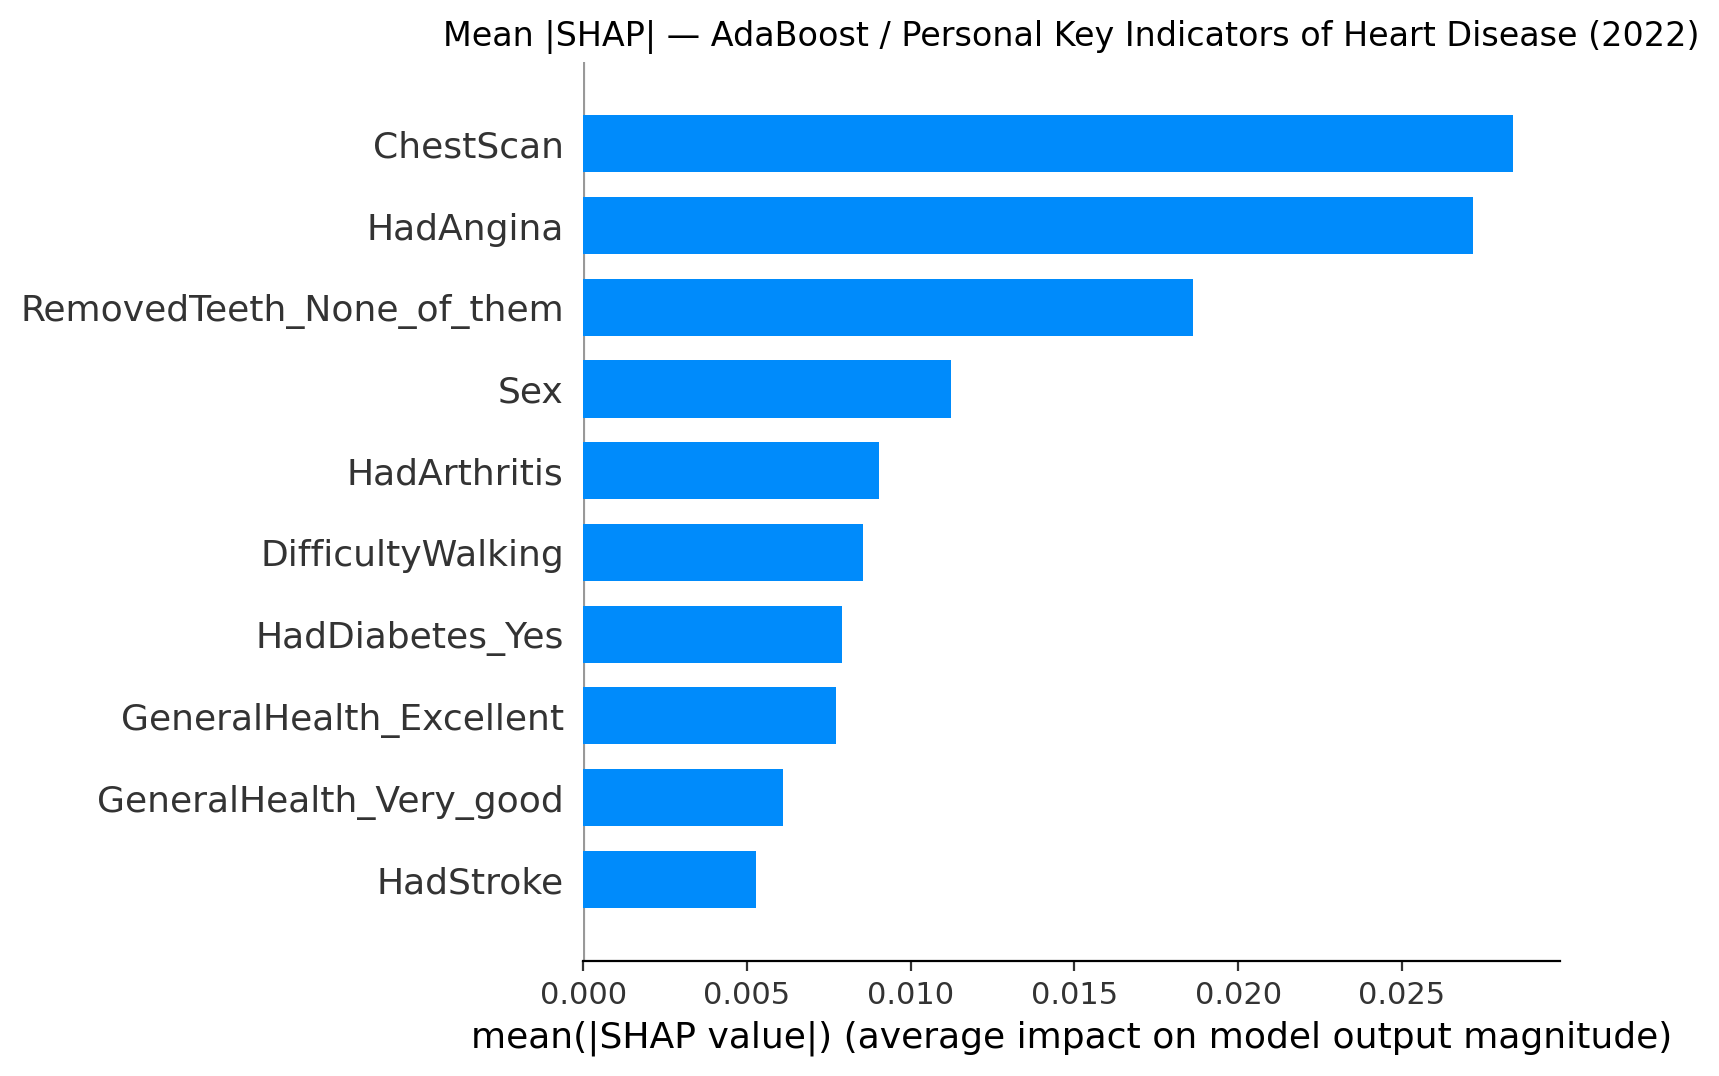

### Dataset1 Adaboost Beeswarm

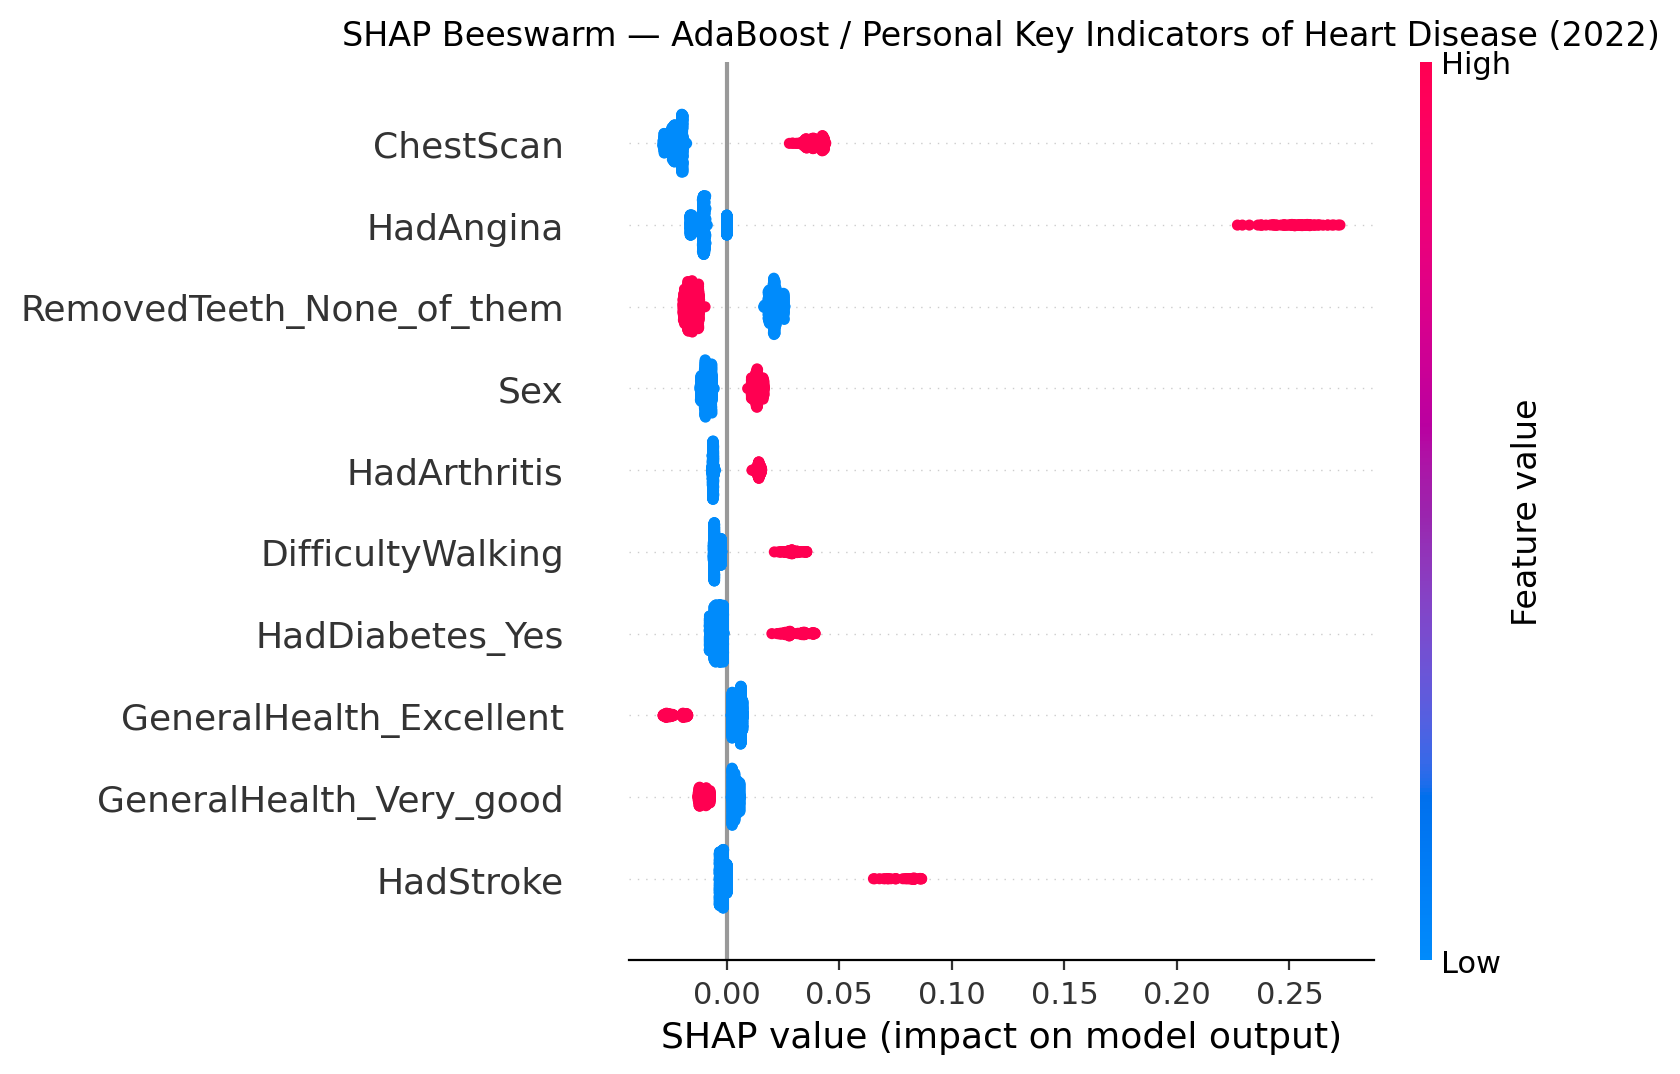

### Dataset1 Adaboost Violin

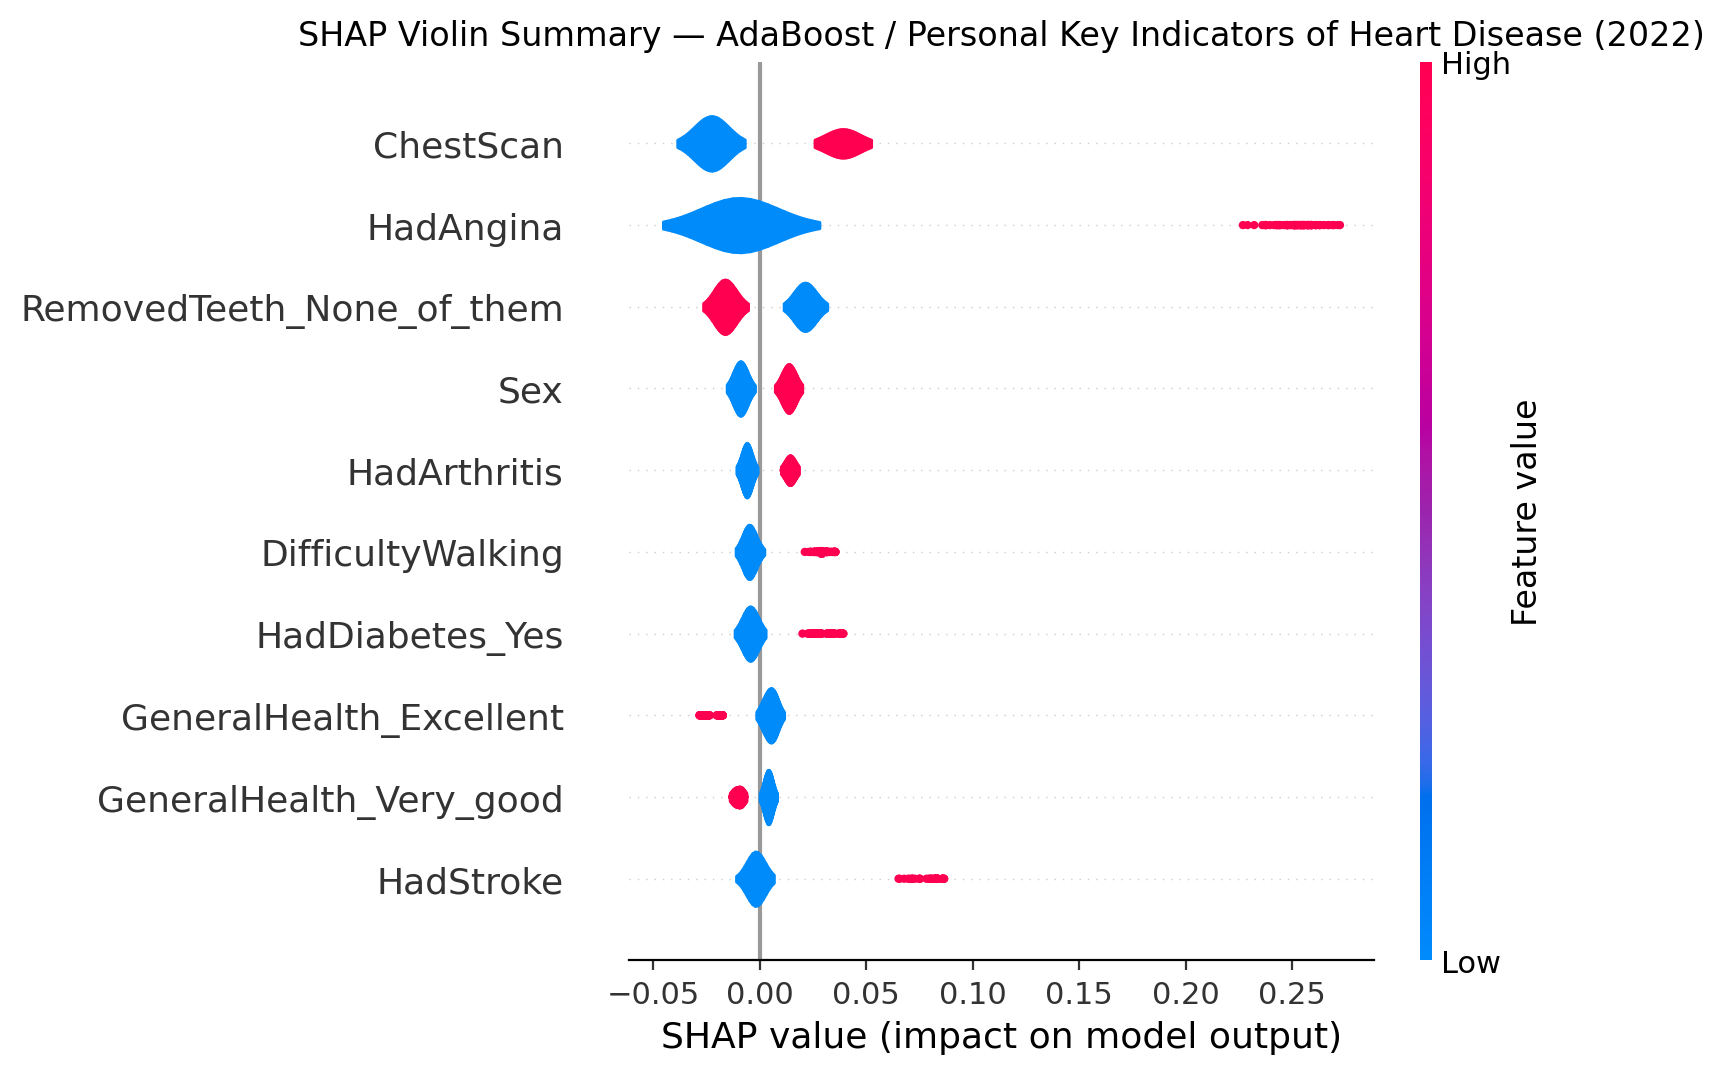

### Dataset1 Lightgbm Bar

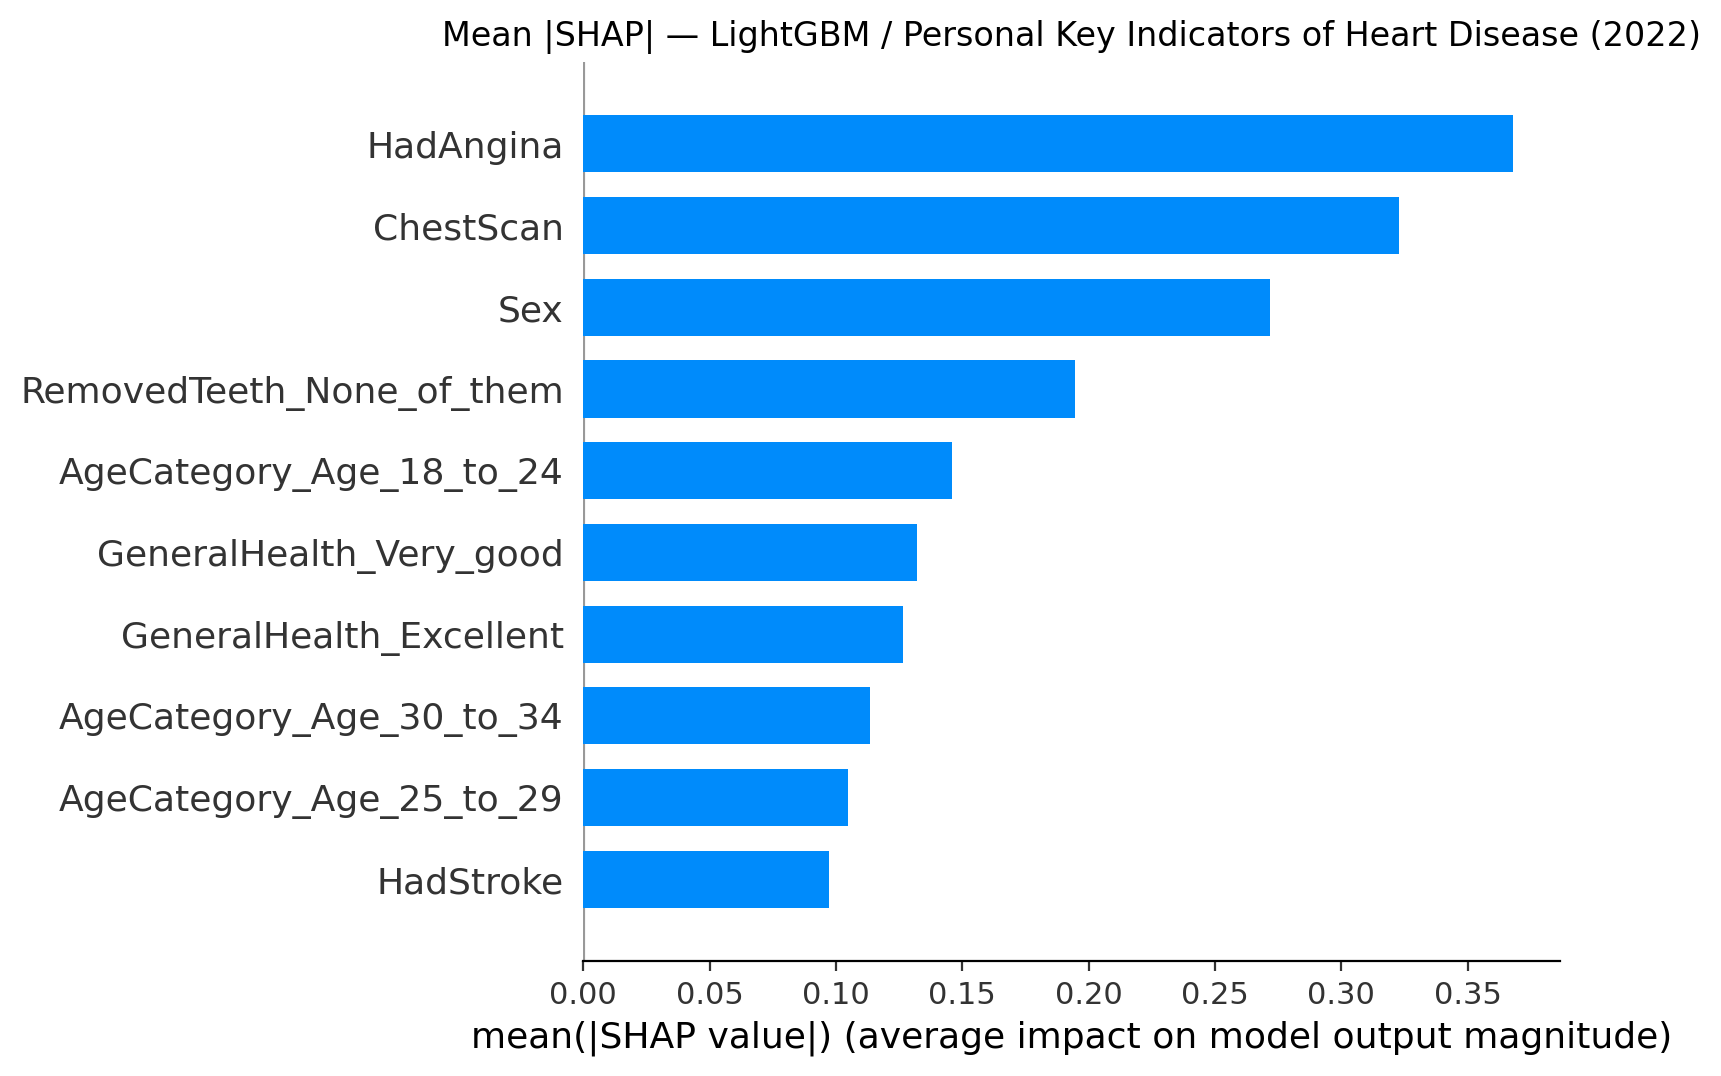

### Dataset1 Lightgbm Beeswarm

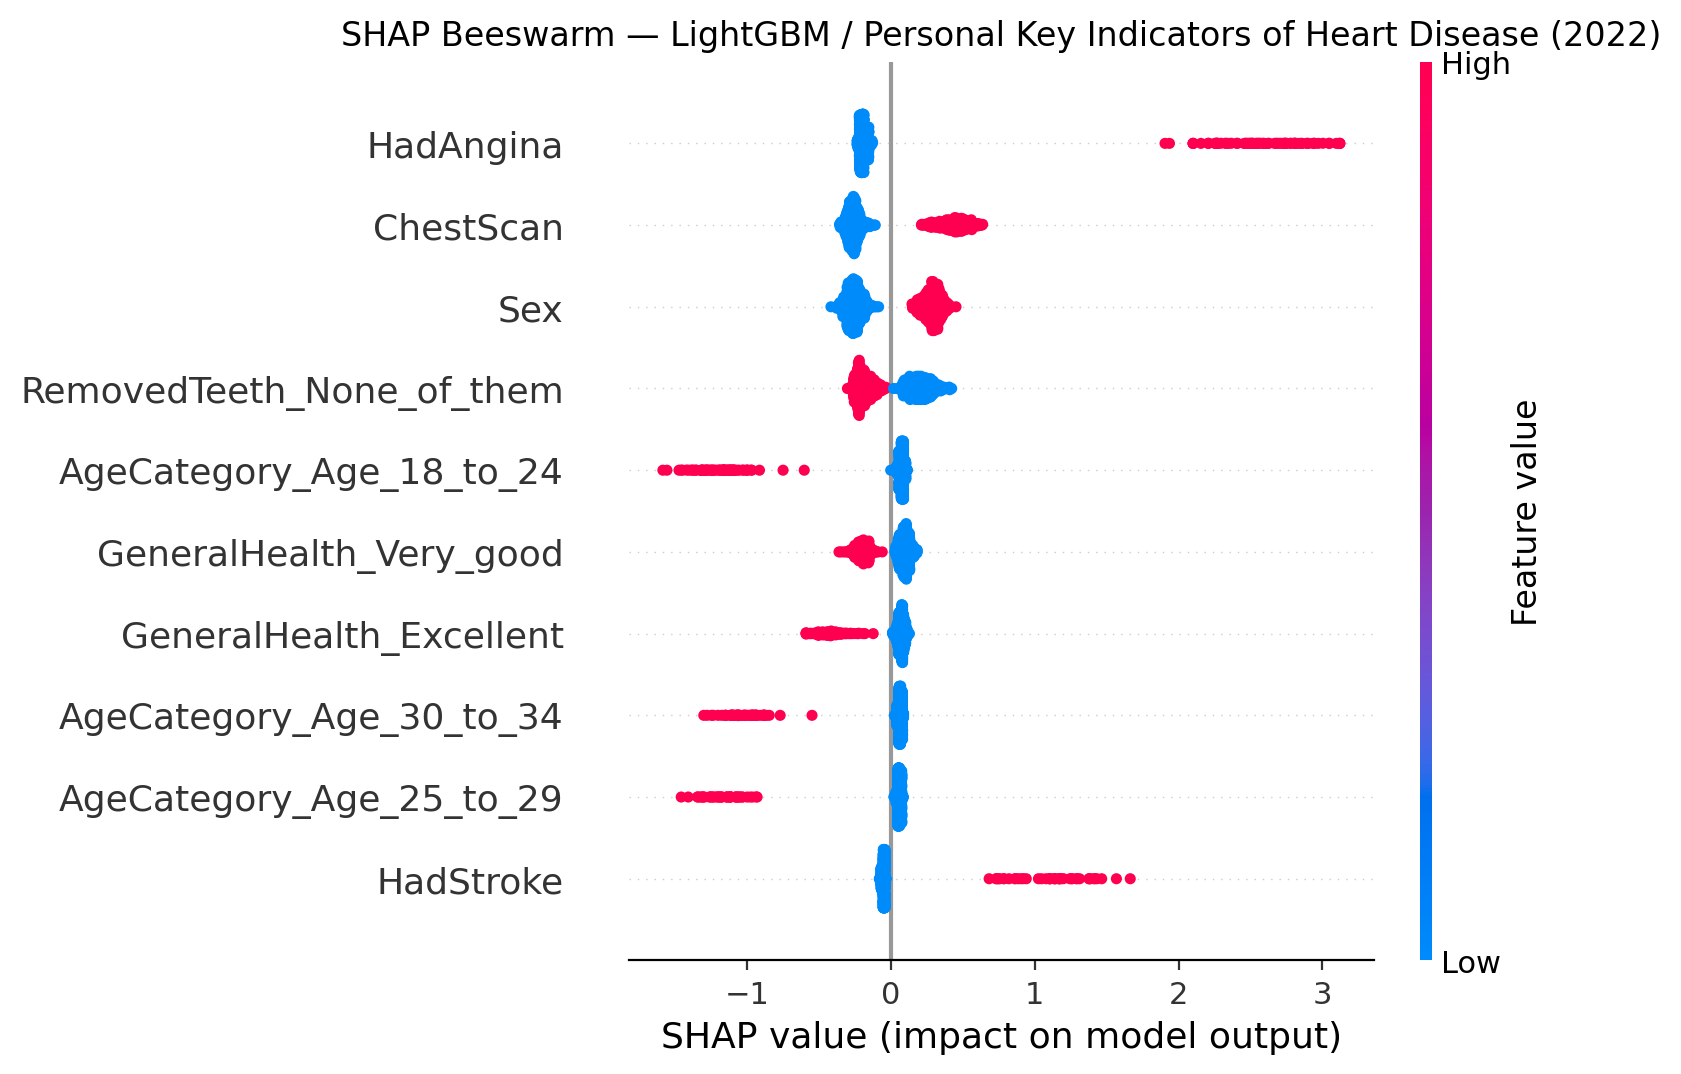

### Dataset1 Lightgbm Violin

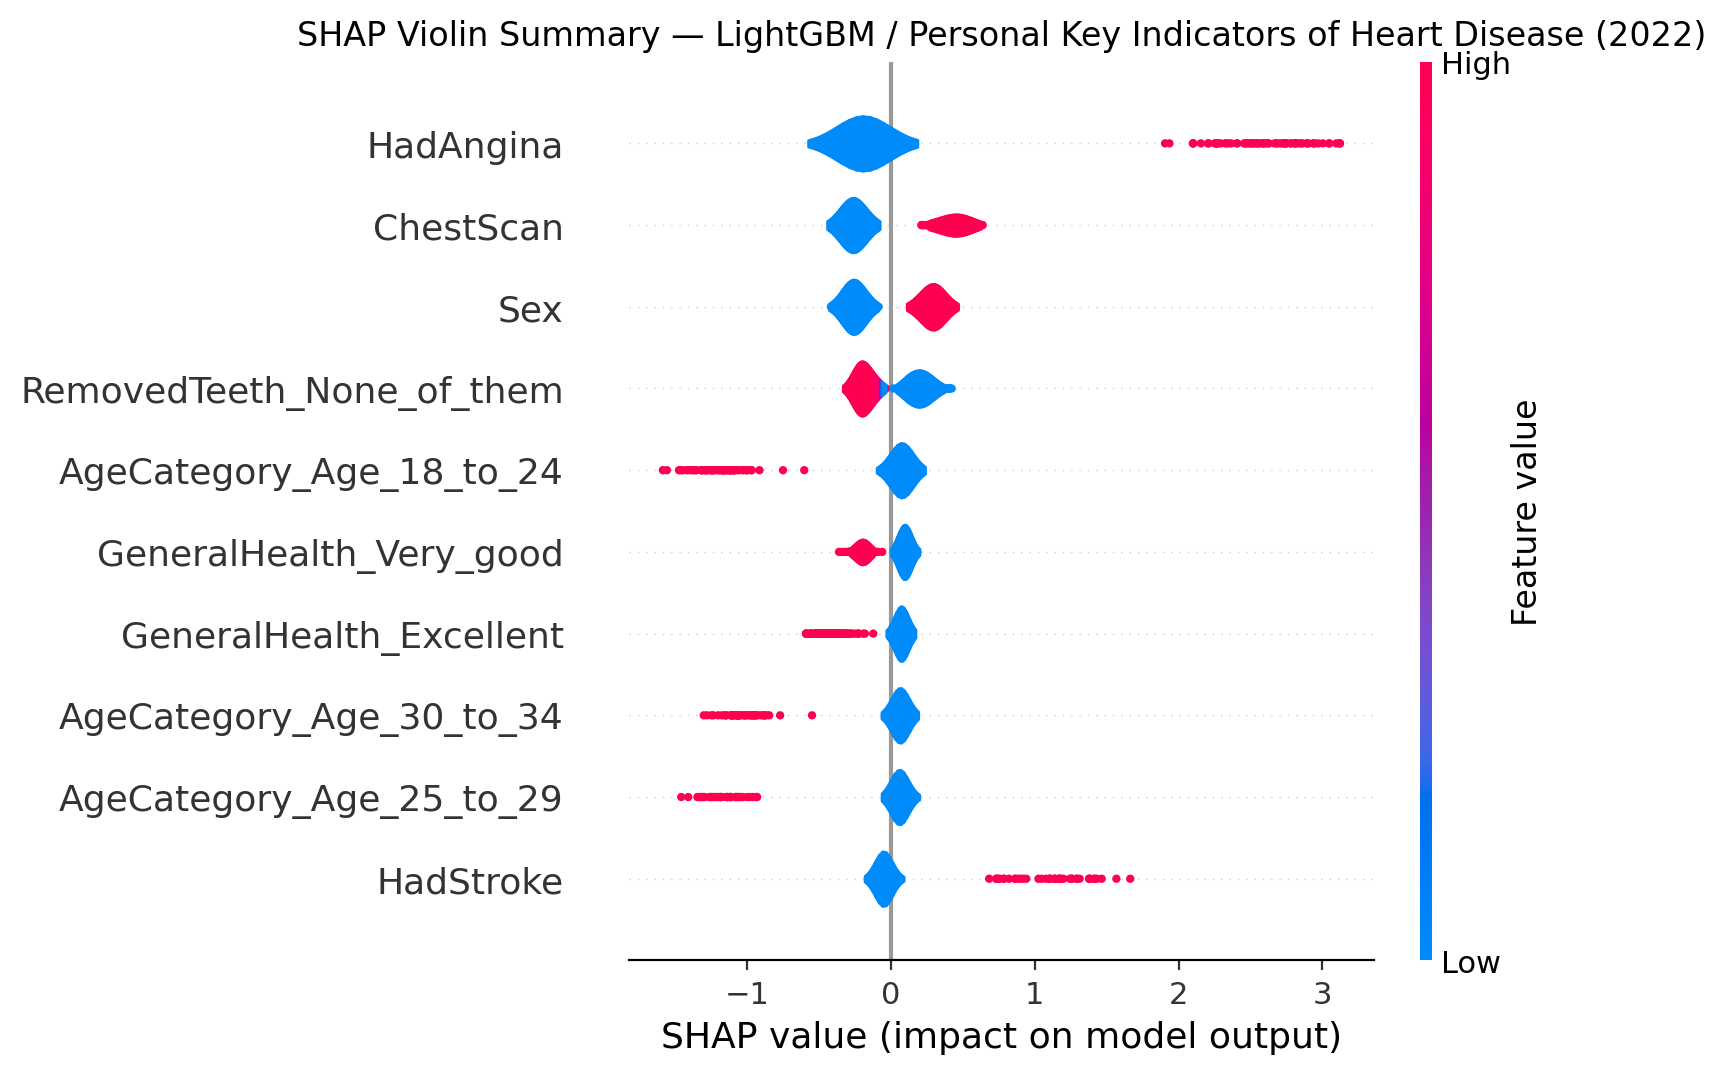

### Dataset1 Xgboost Bar

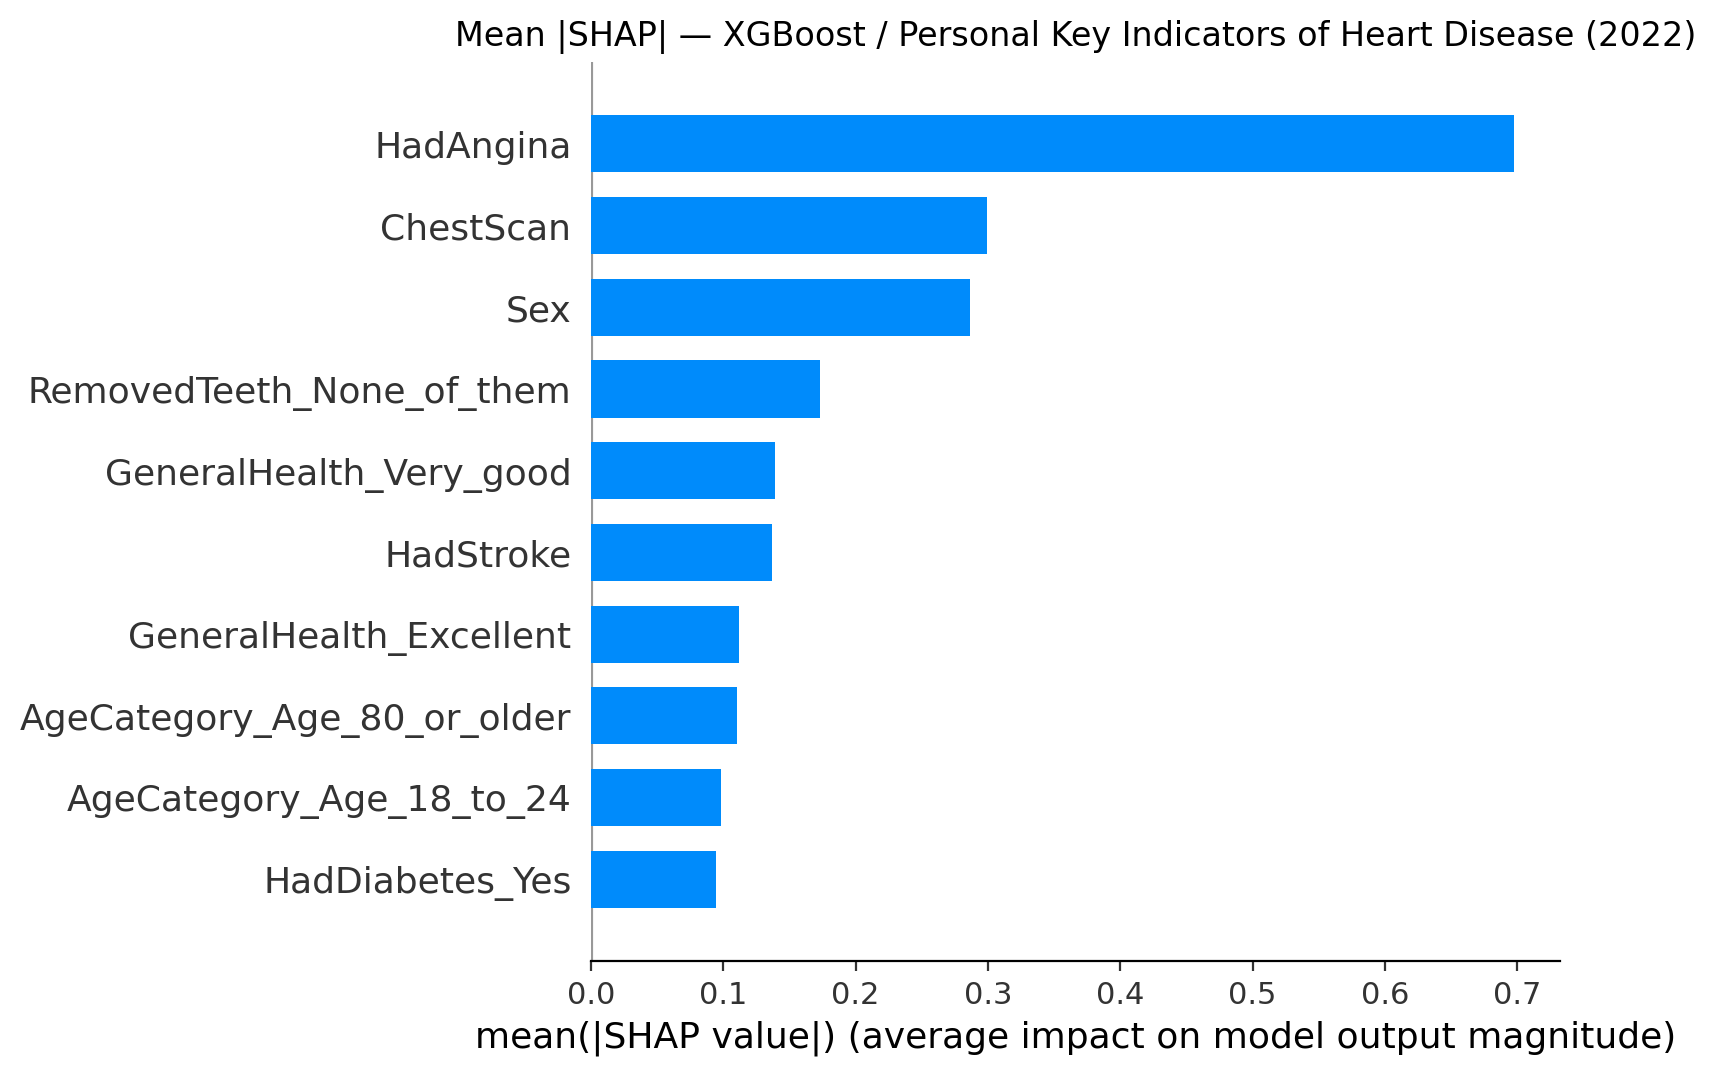

### Dataset1 Xgboost Beeswarm

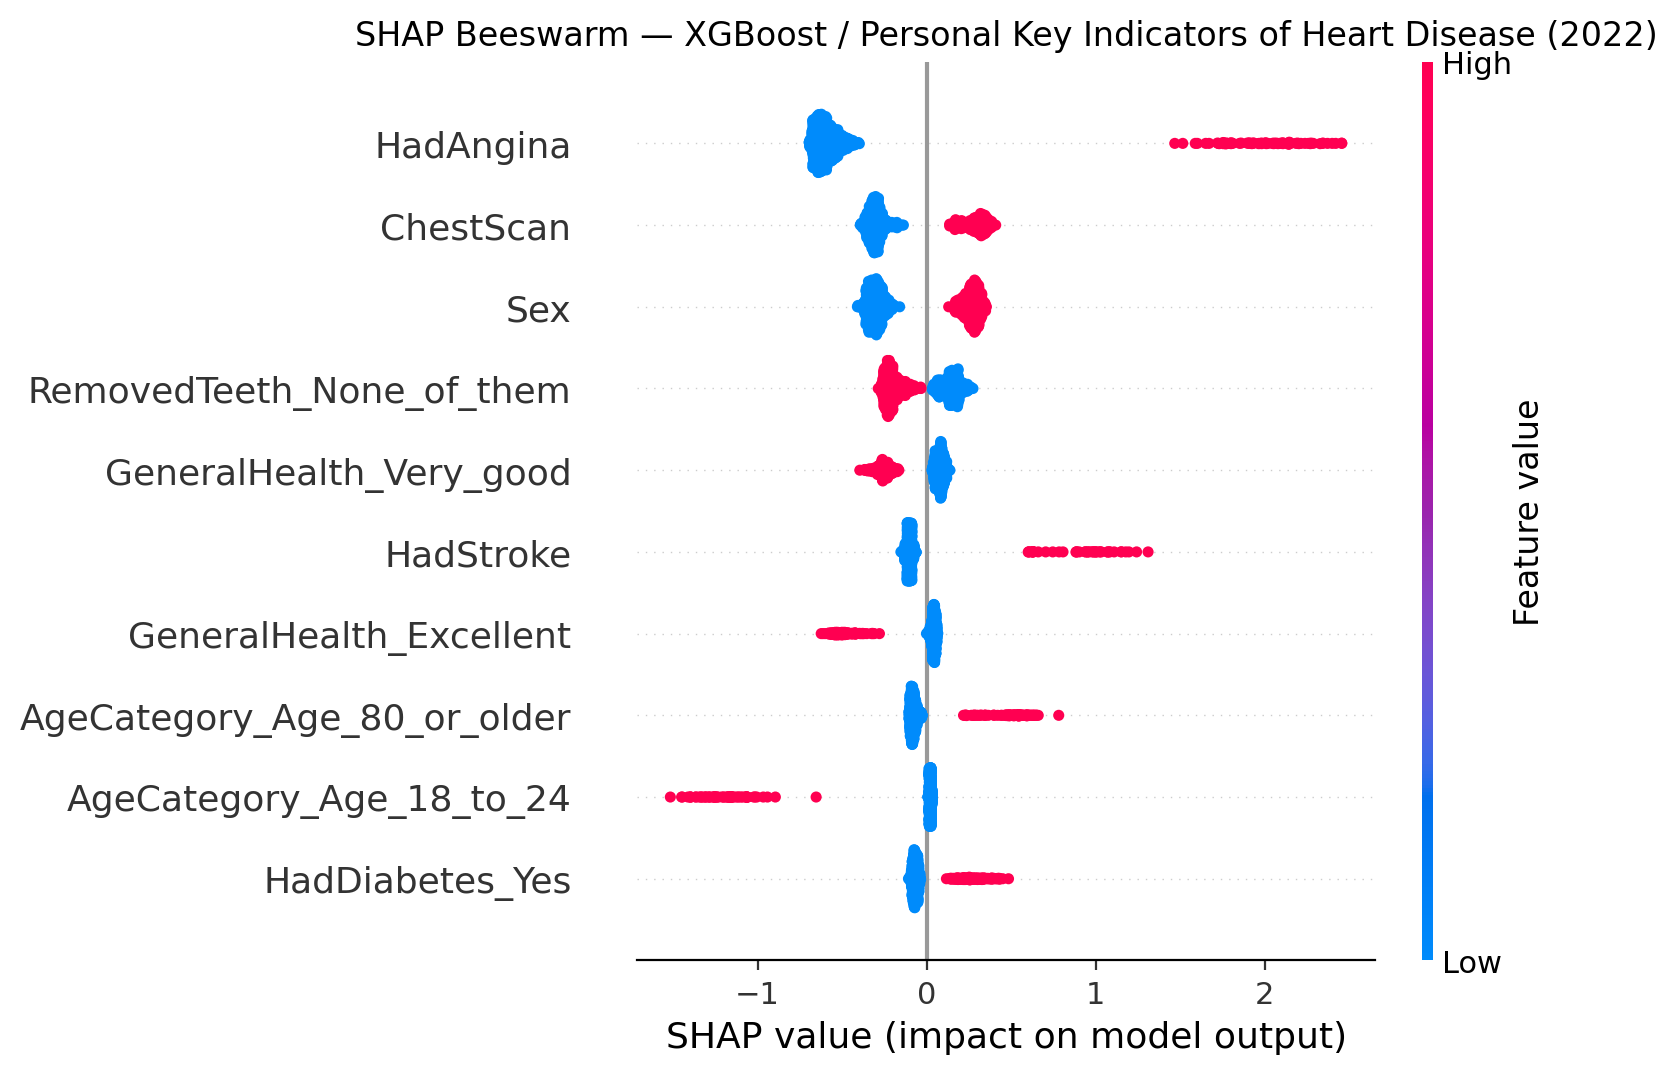

### Dataset1 Xgboost Violin

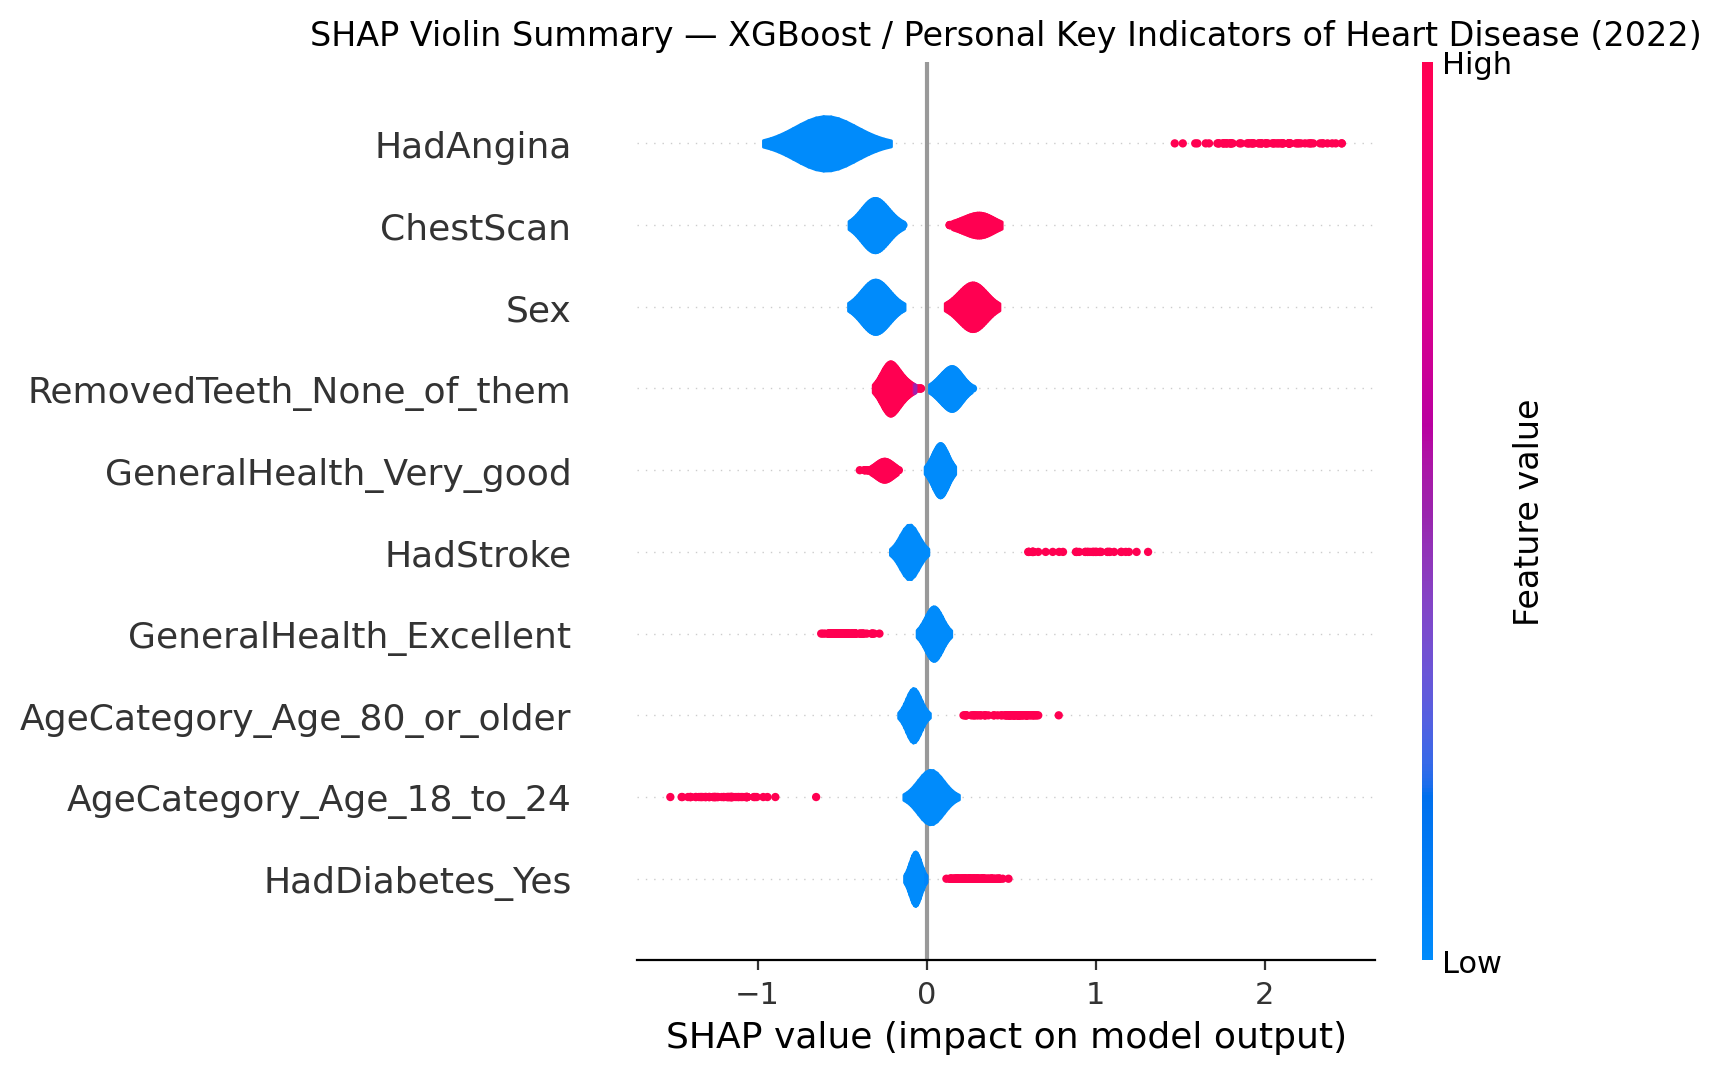

### Dataset2 Adaboost Bar

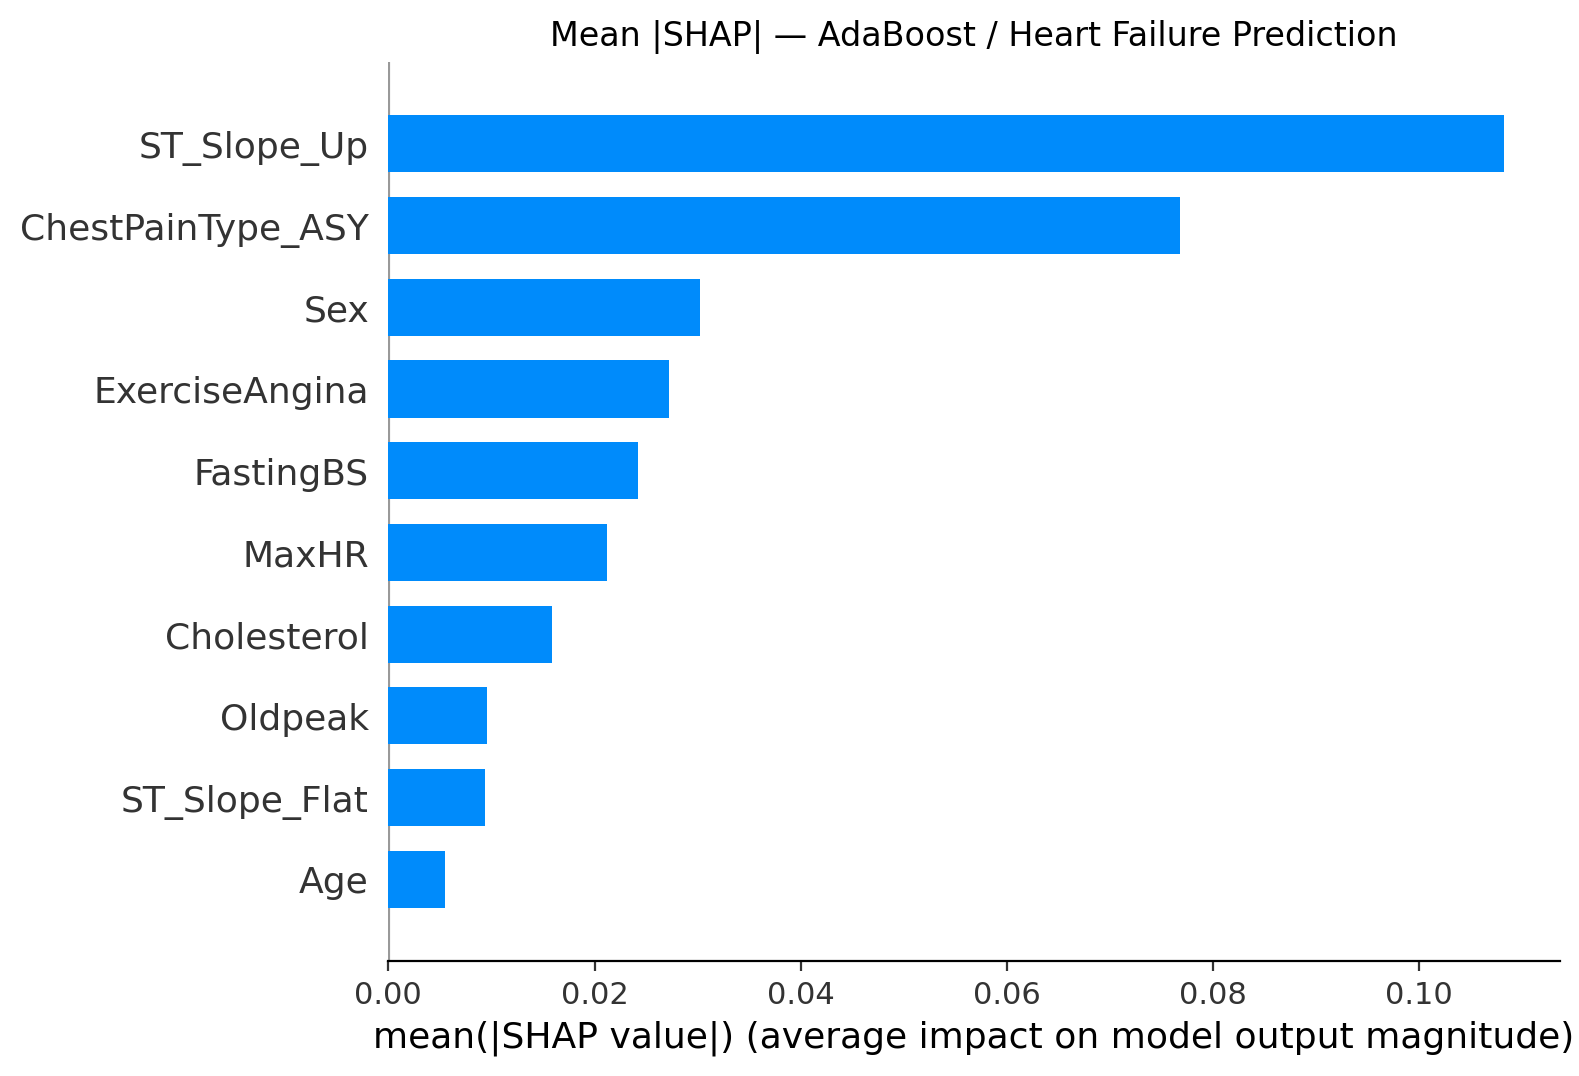

### Dataset2 Adaboost Beeswarm

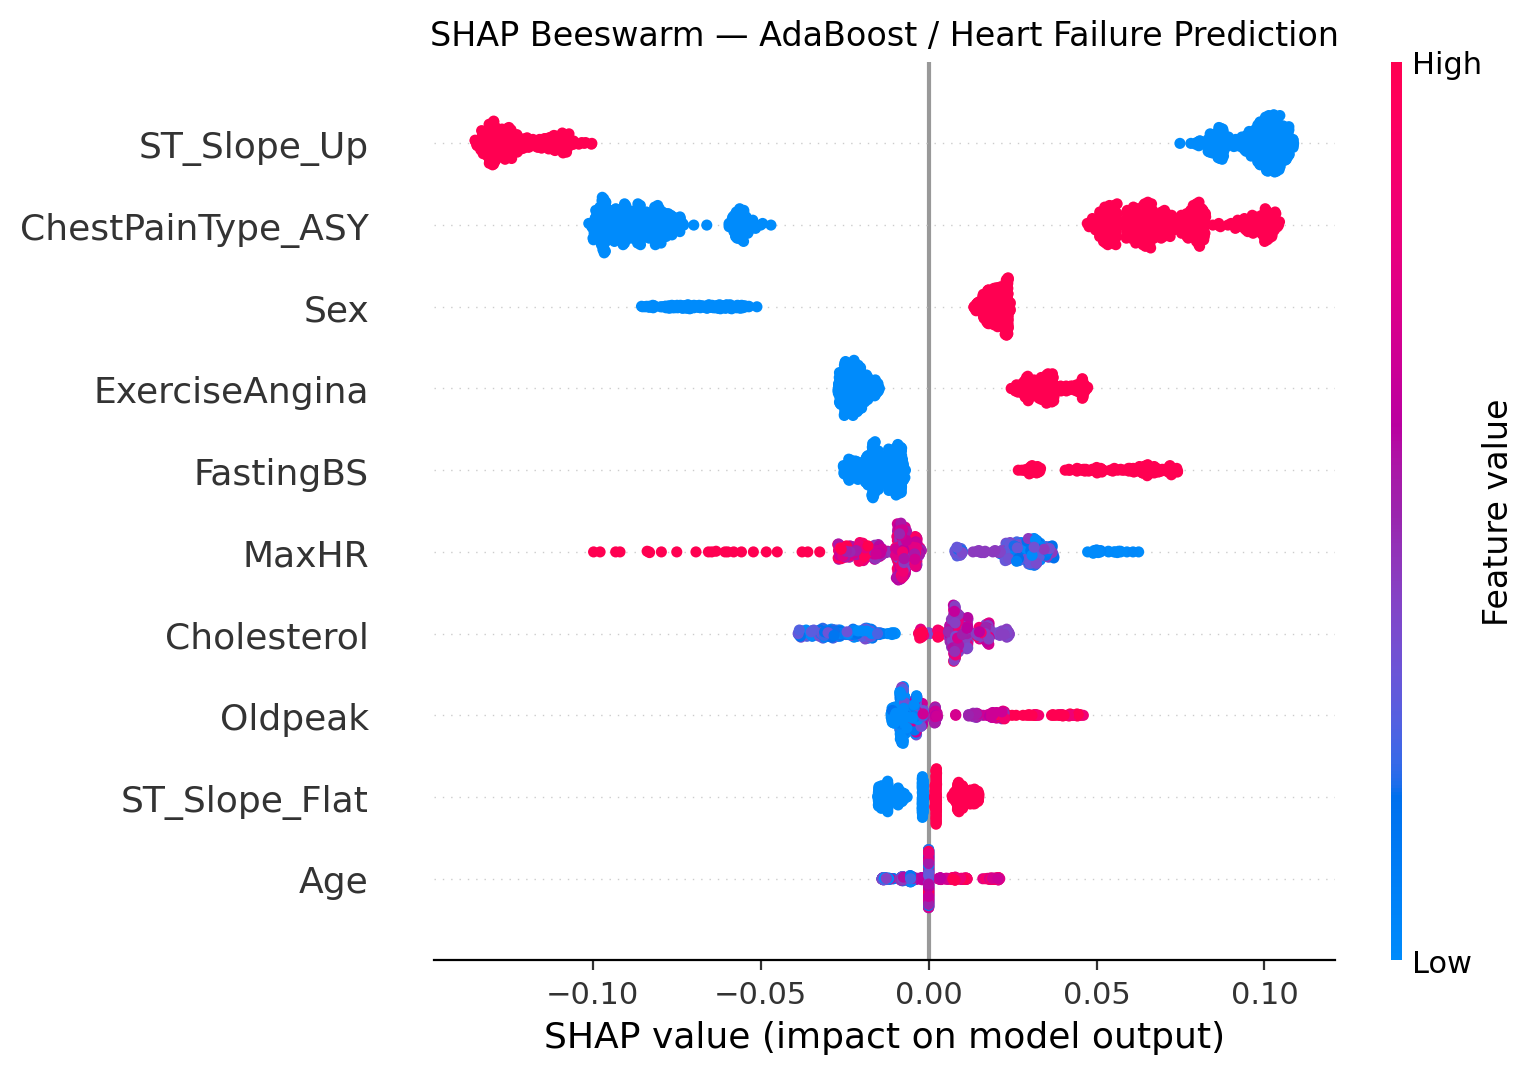

### Dataset2 Adaboost Violin

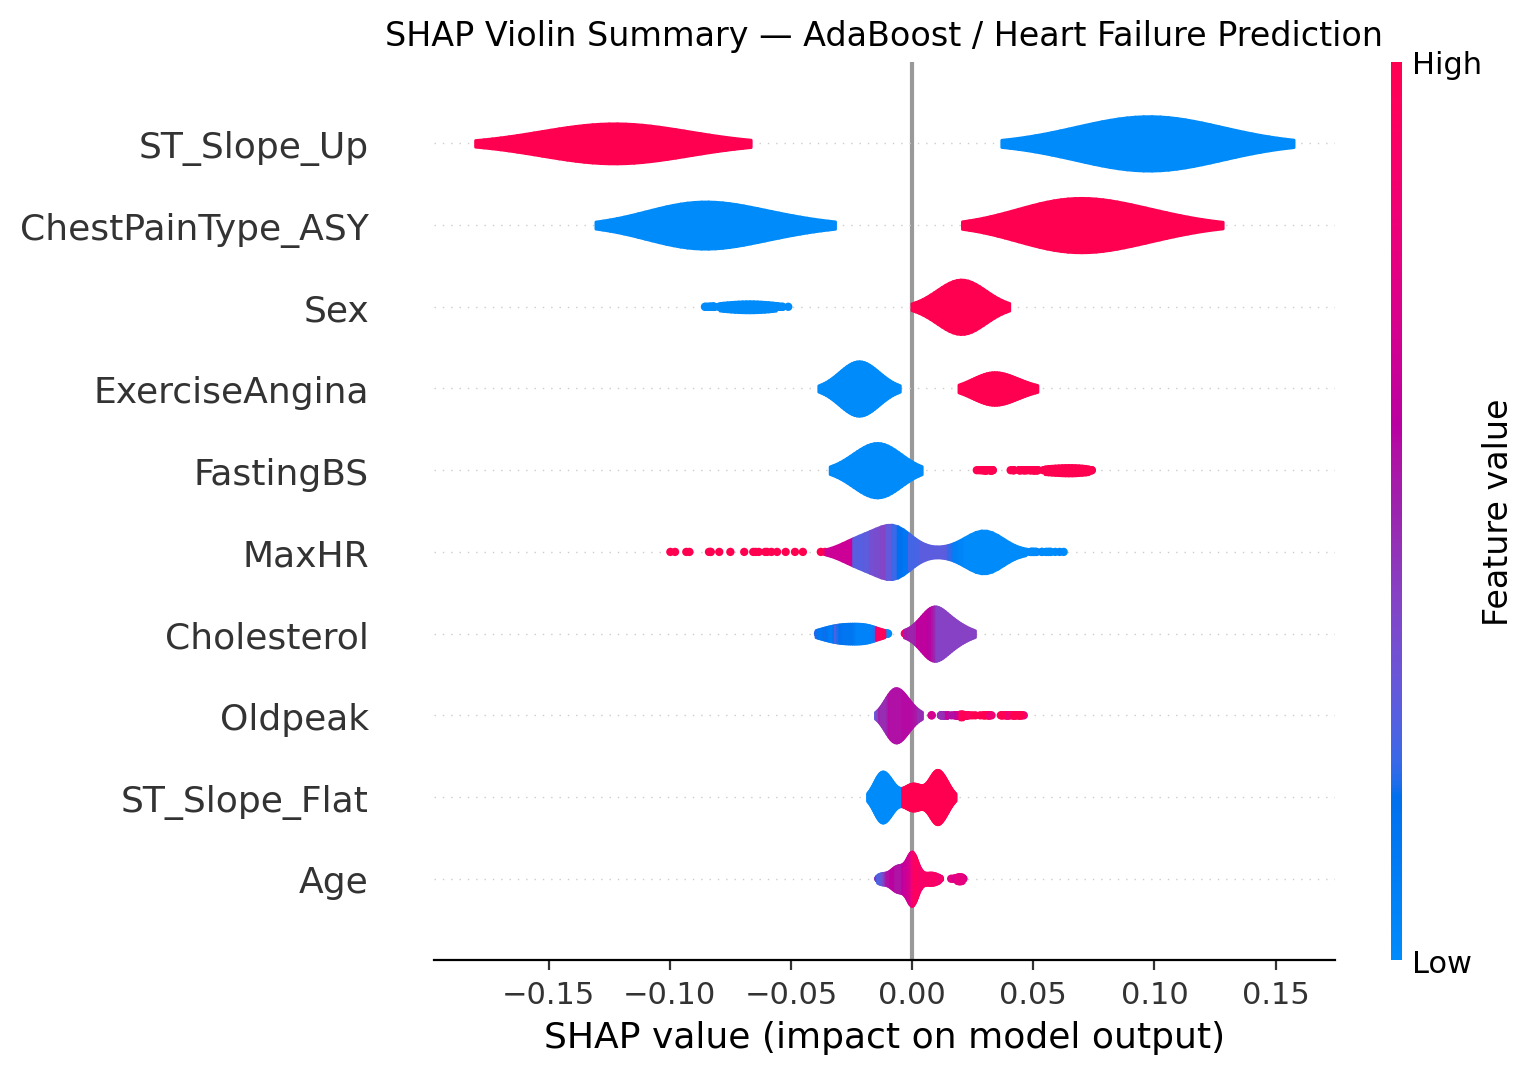

### Dataset2 Lightgbm Bar

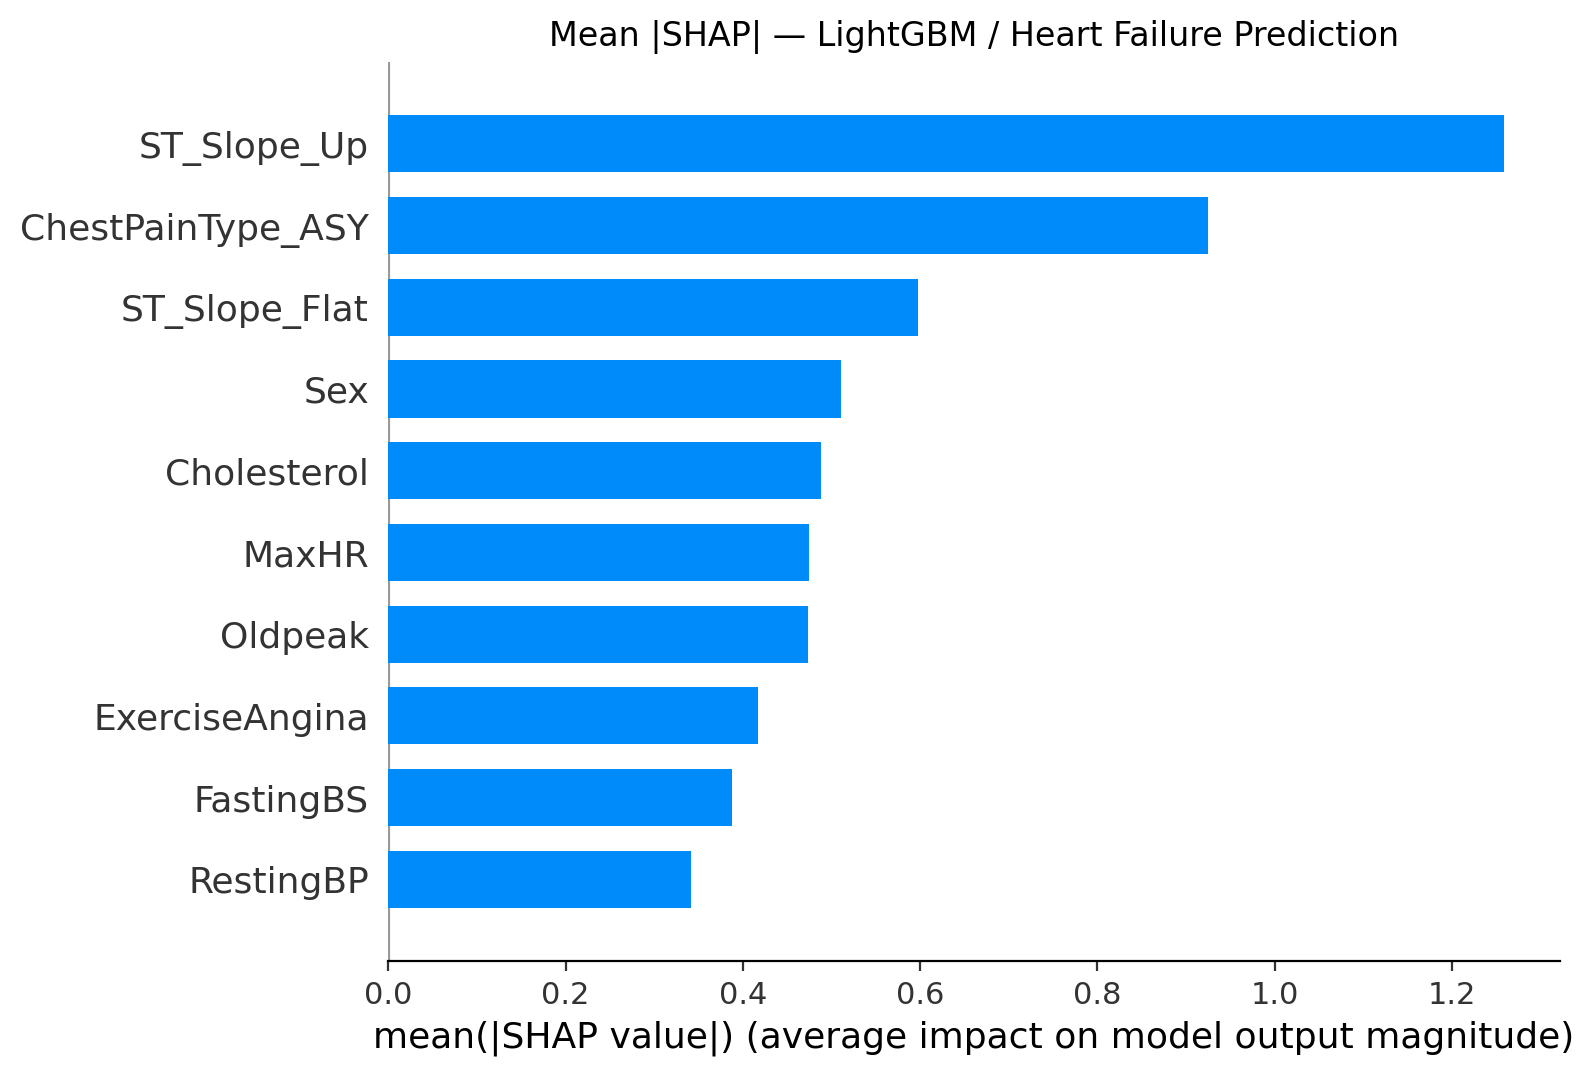

### Dataset2 Lightgbm Beeswarm

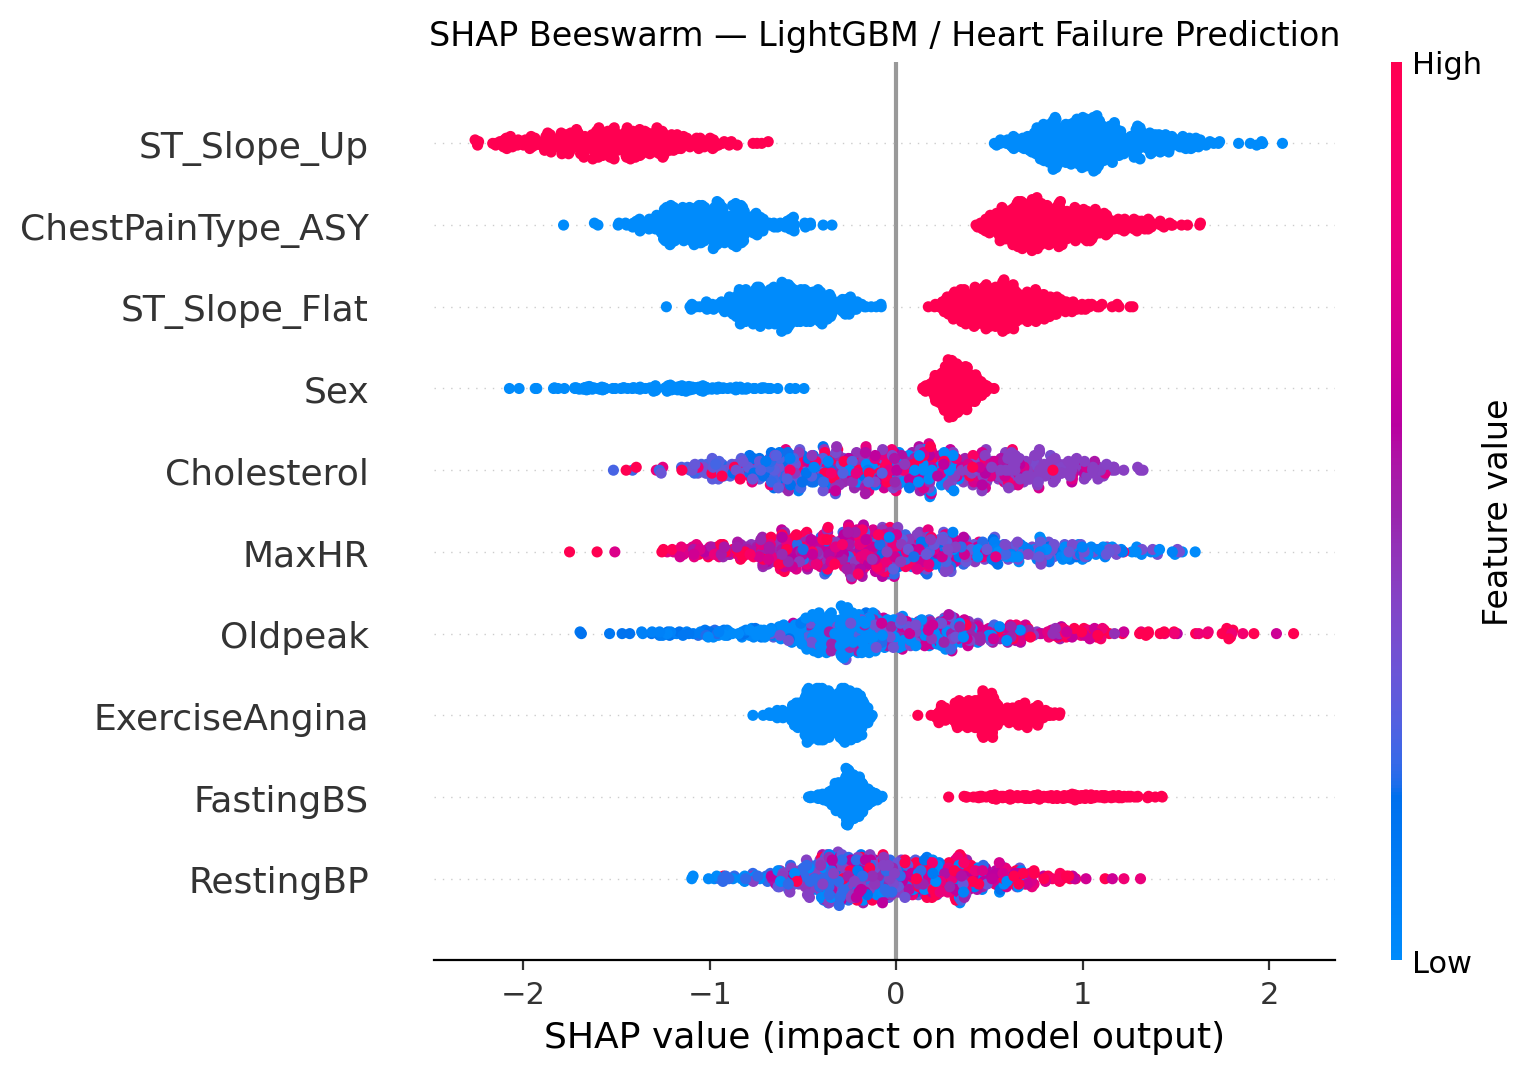

### Dataset2 Lightgbm Violin

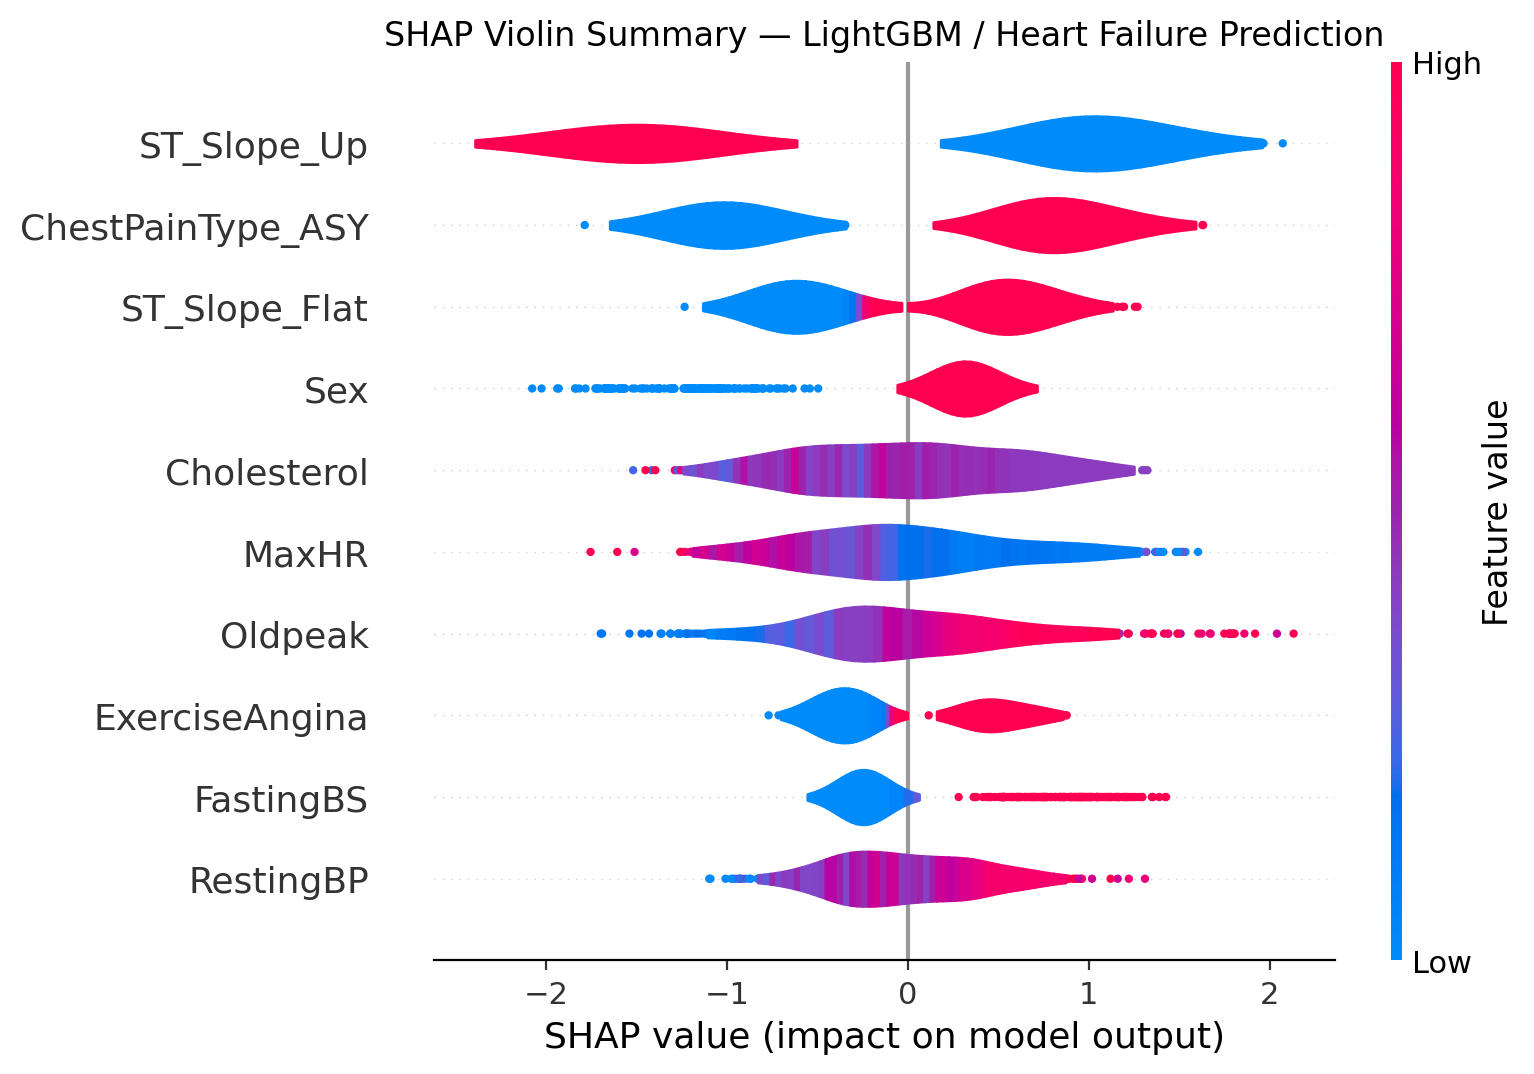

### Dataset2 Xgboost Bar

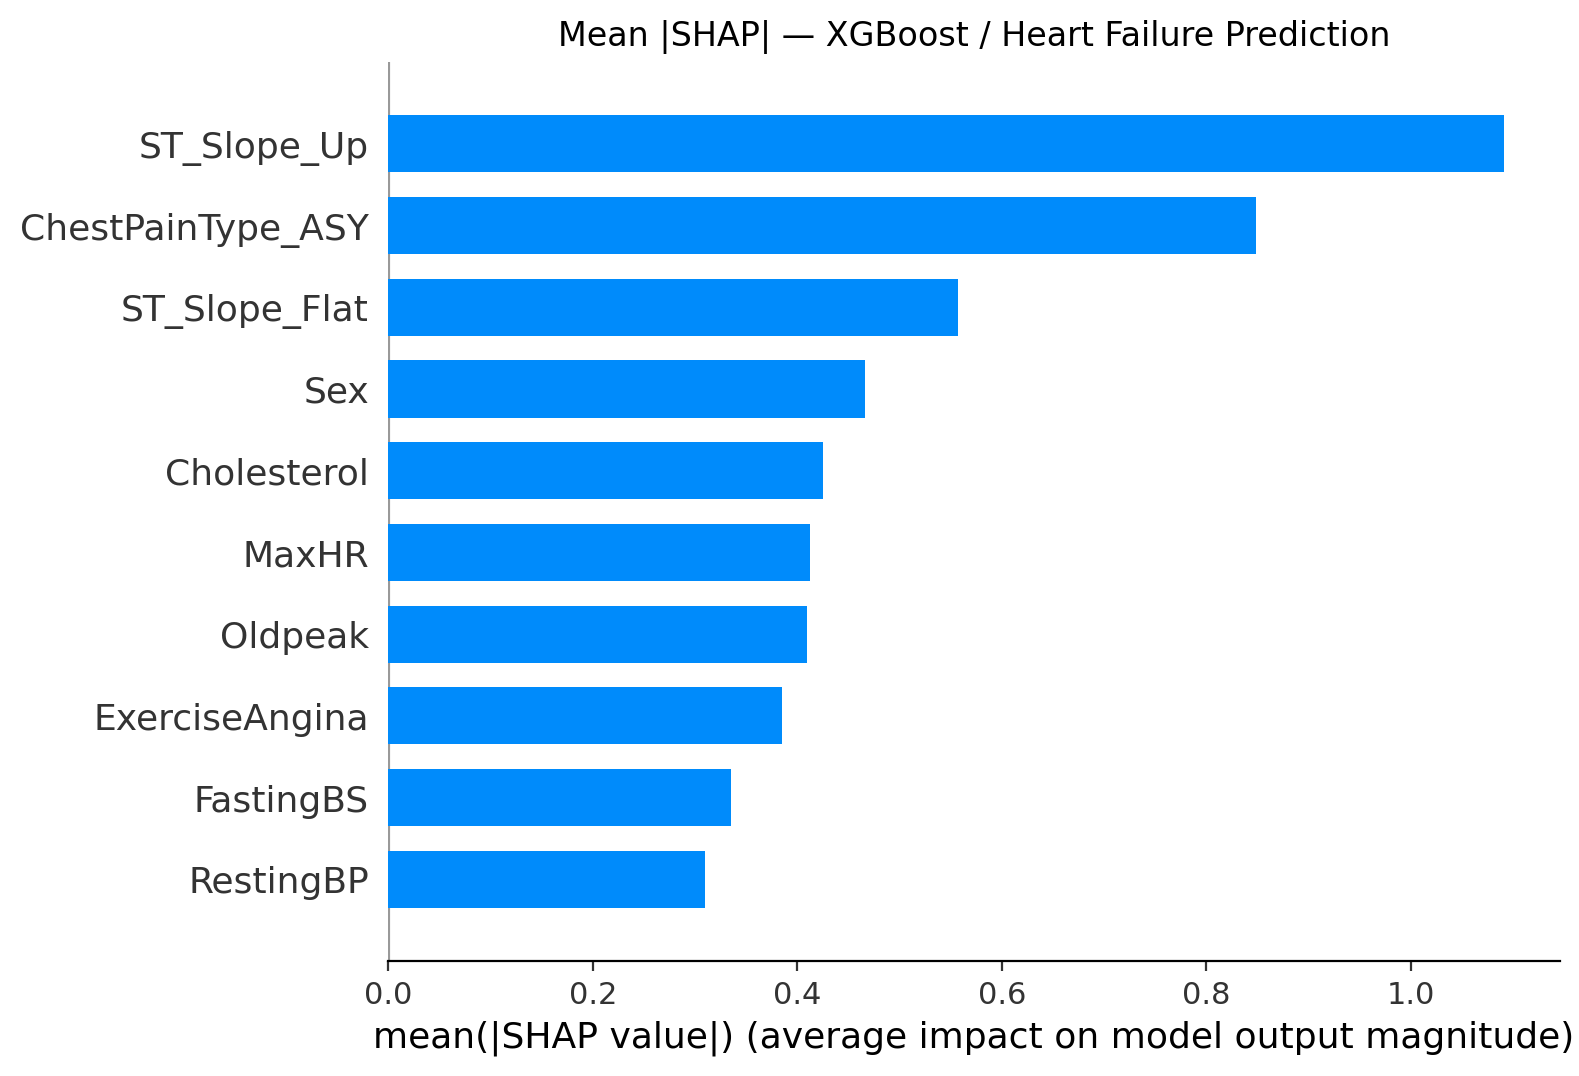

### Dataset2 Xgboost Beeswarm

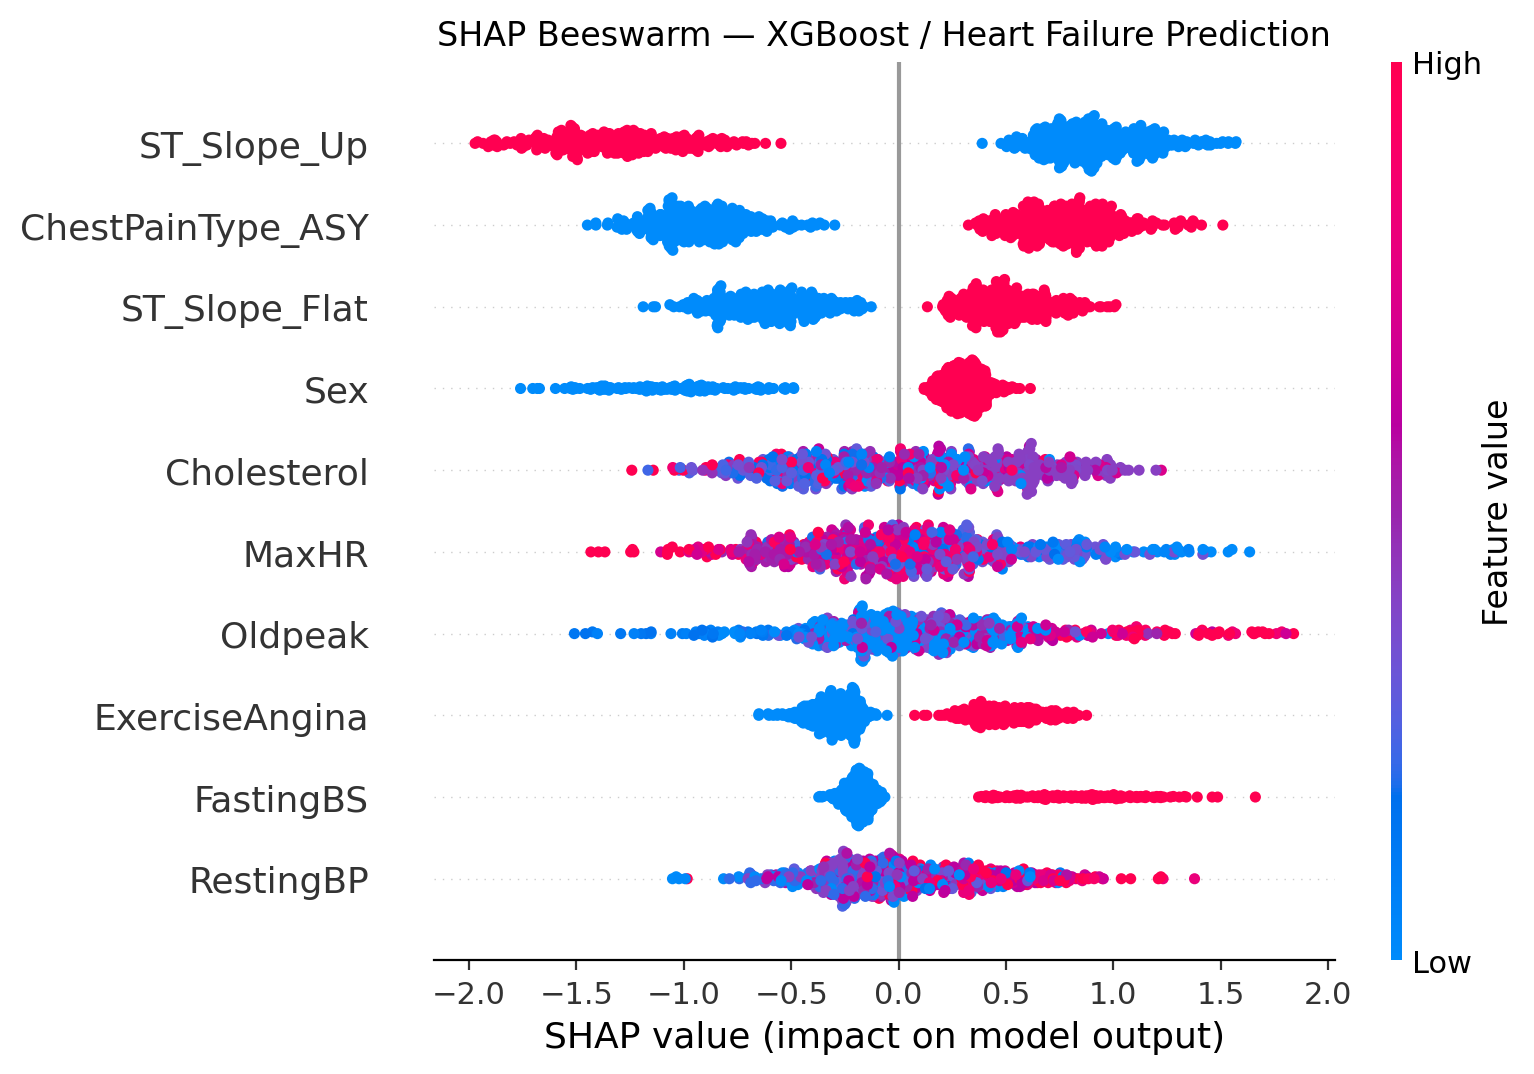

### Dataset2 Xgboost Violin

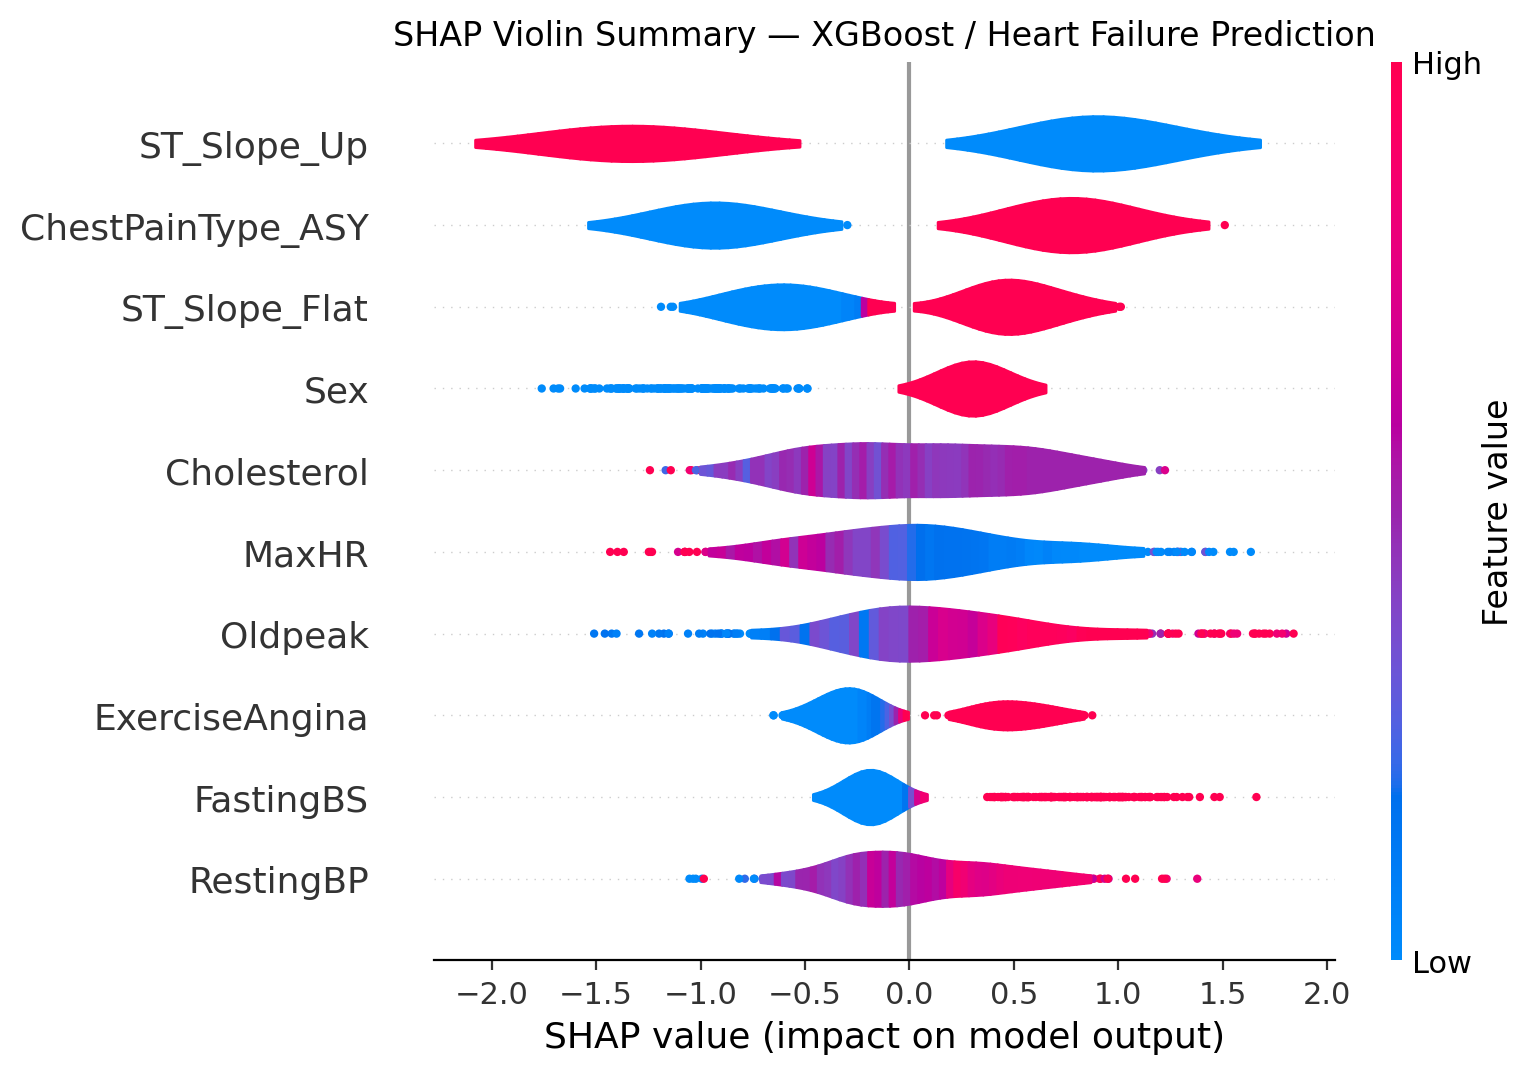

### Dataset3 Adaboost Bar

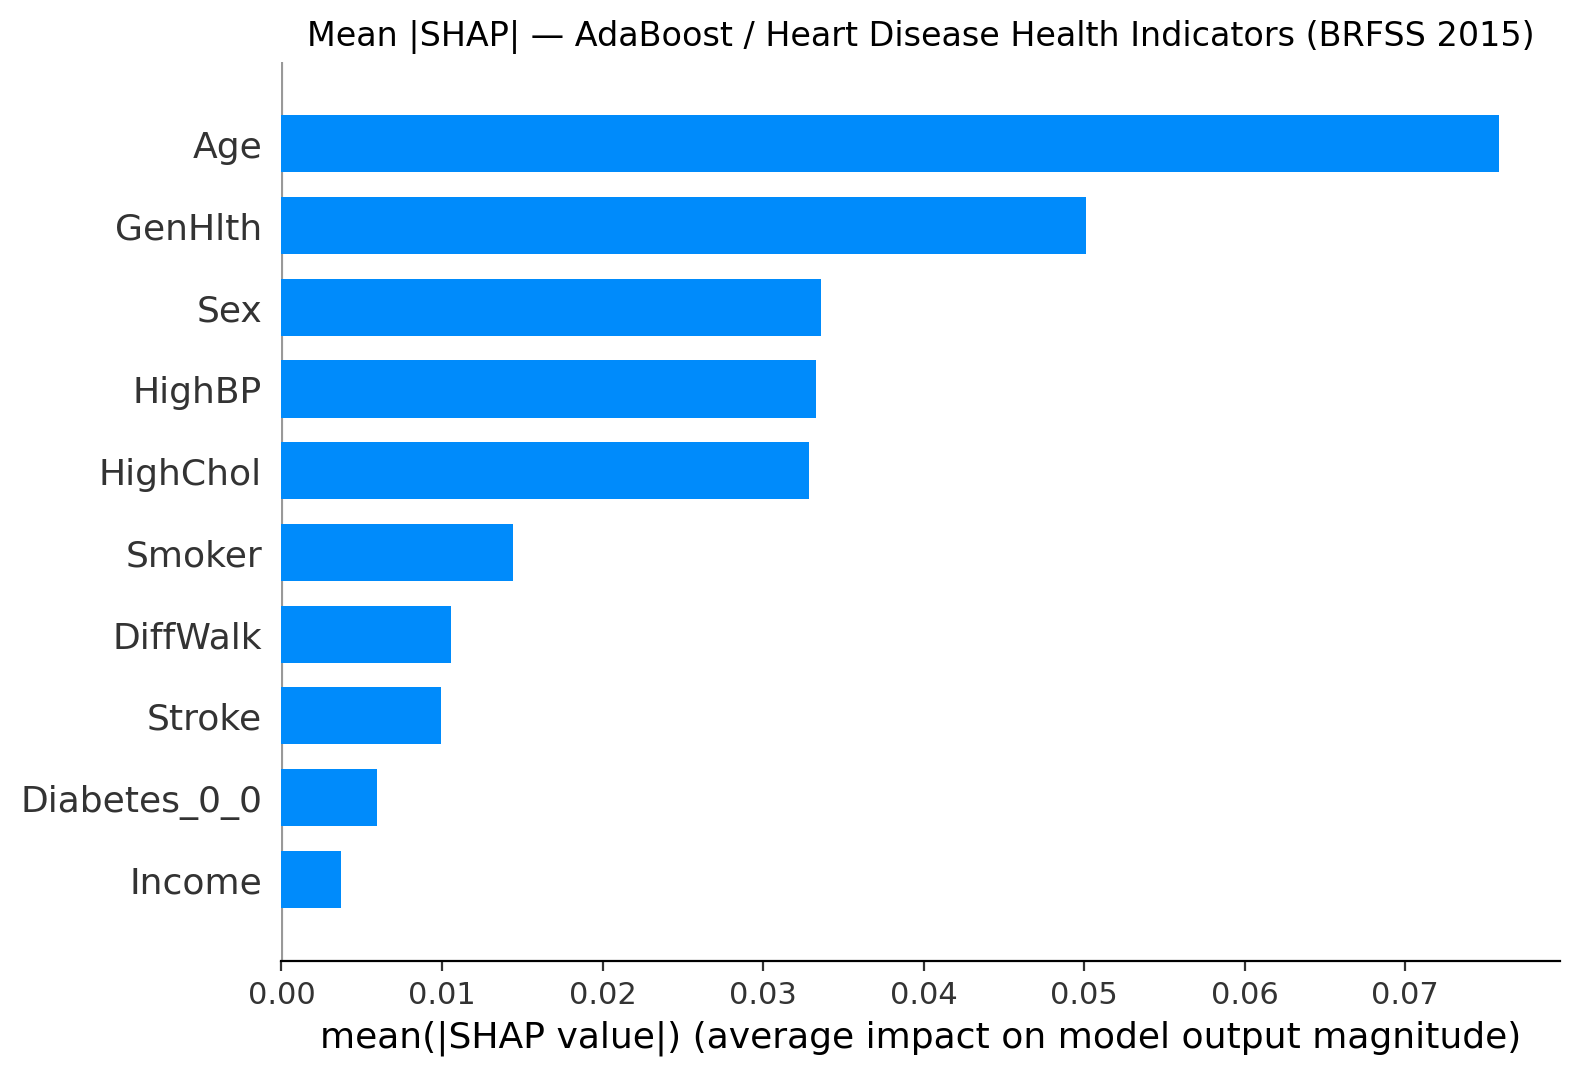

### Dataset3 Adaboost Beeswarm

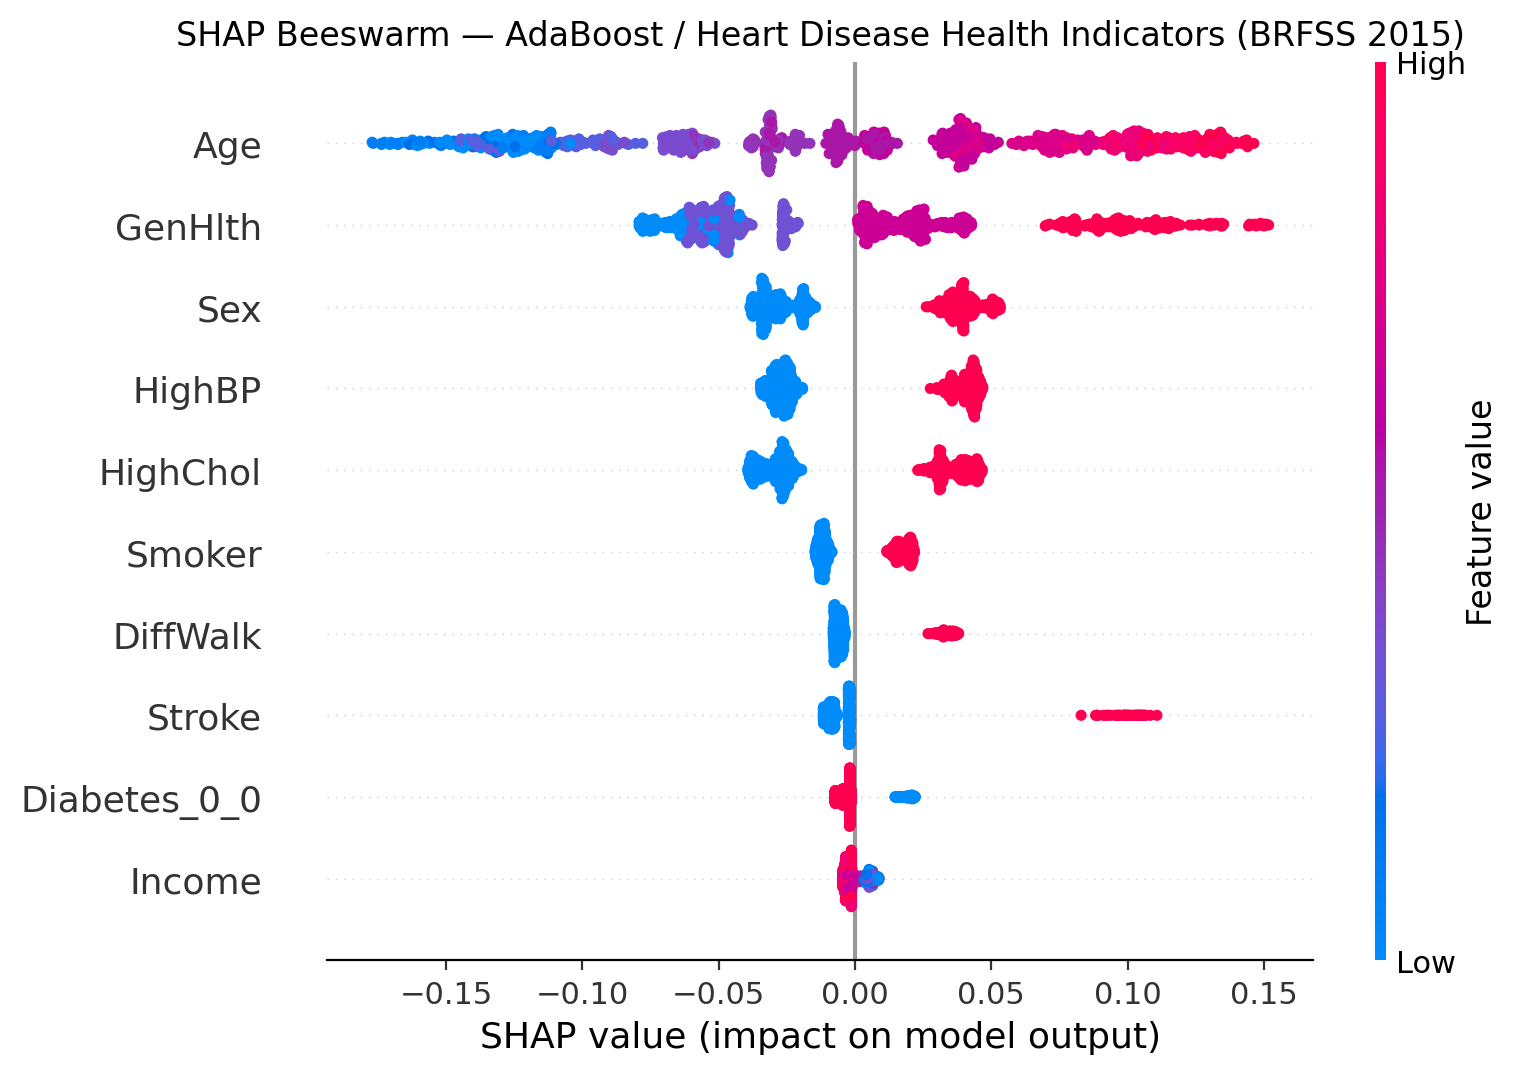

### Dataset3 Adaboost Violin

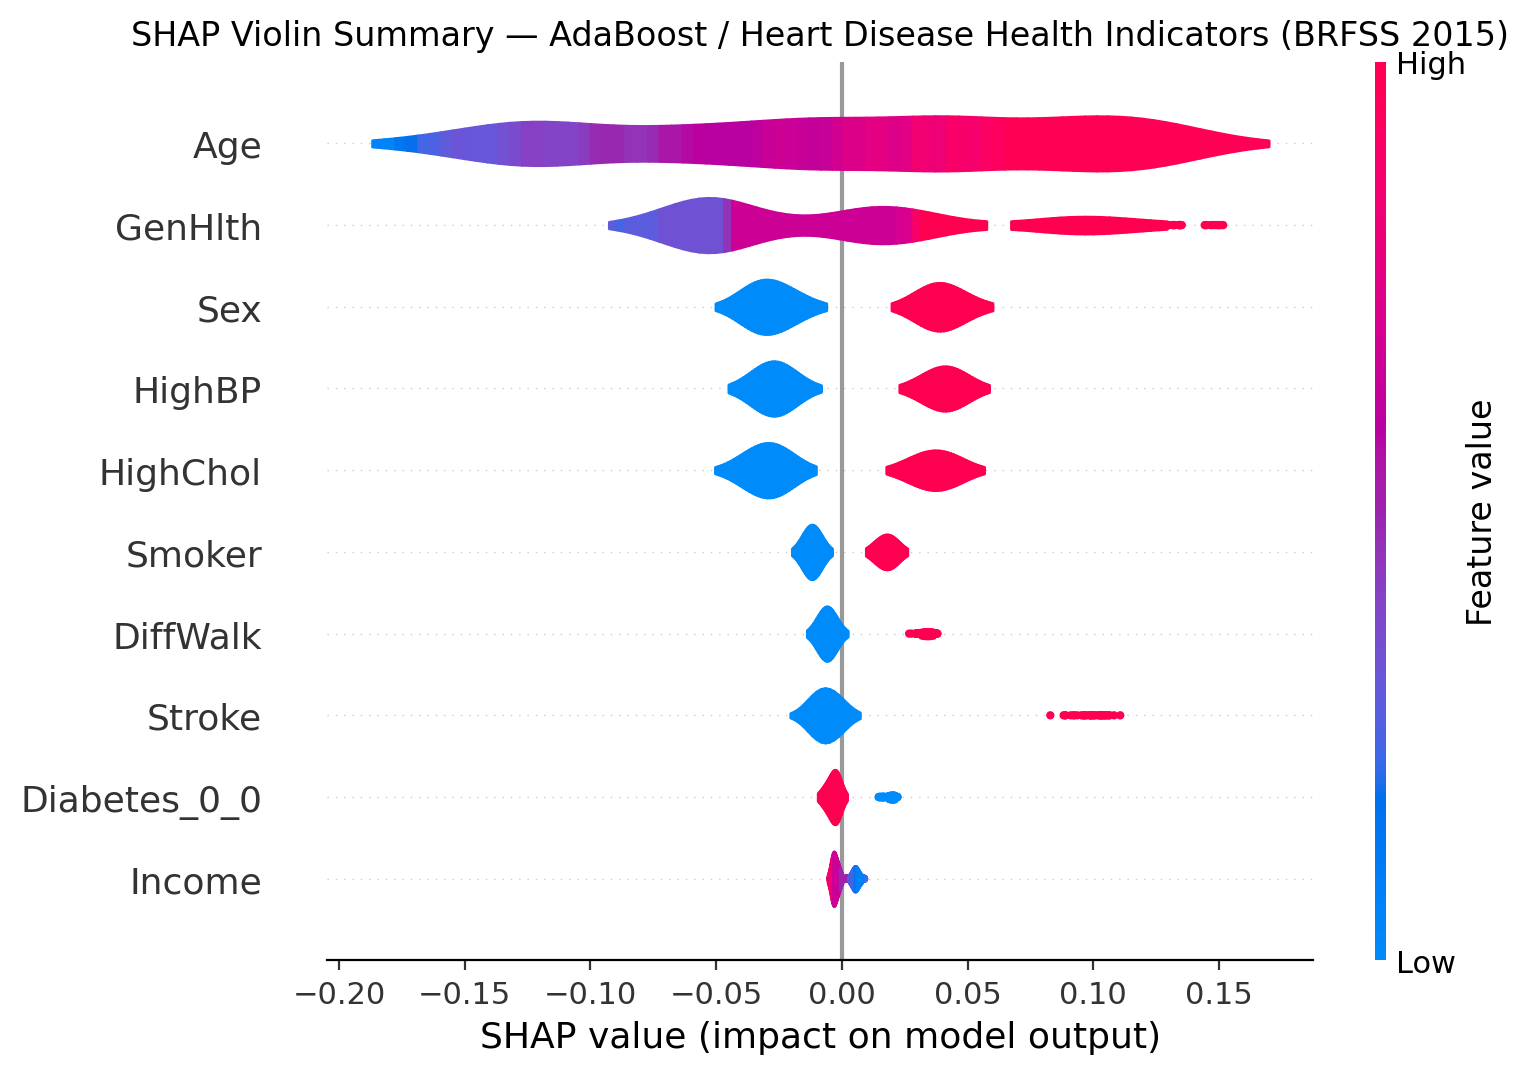

### Dataset3 Lightgbm Bar

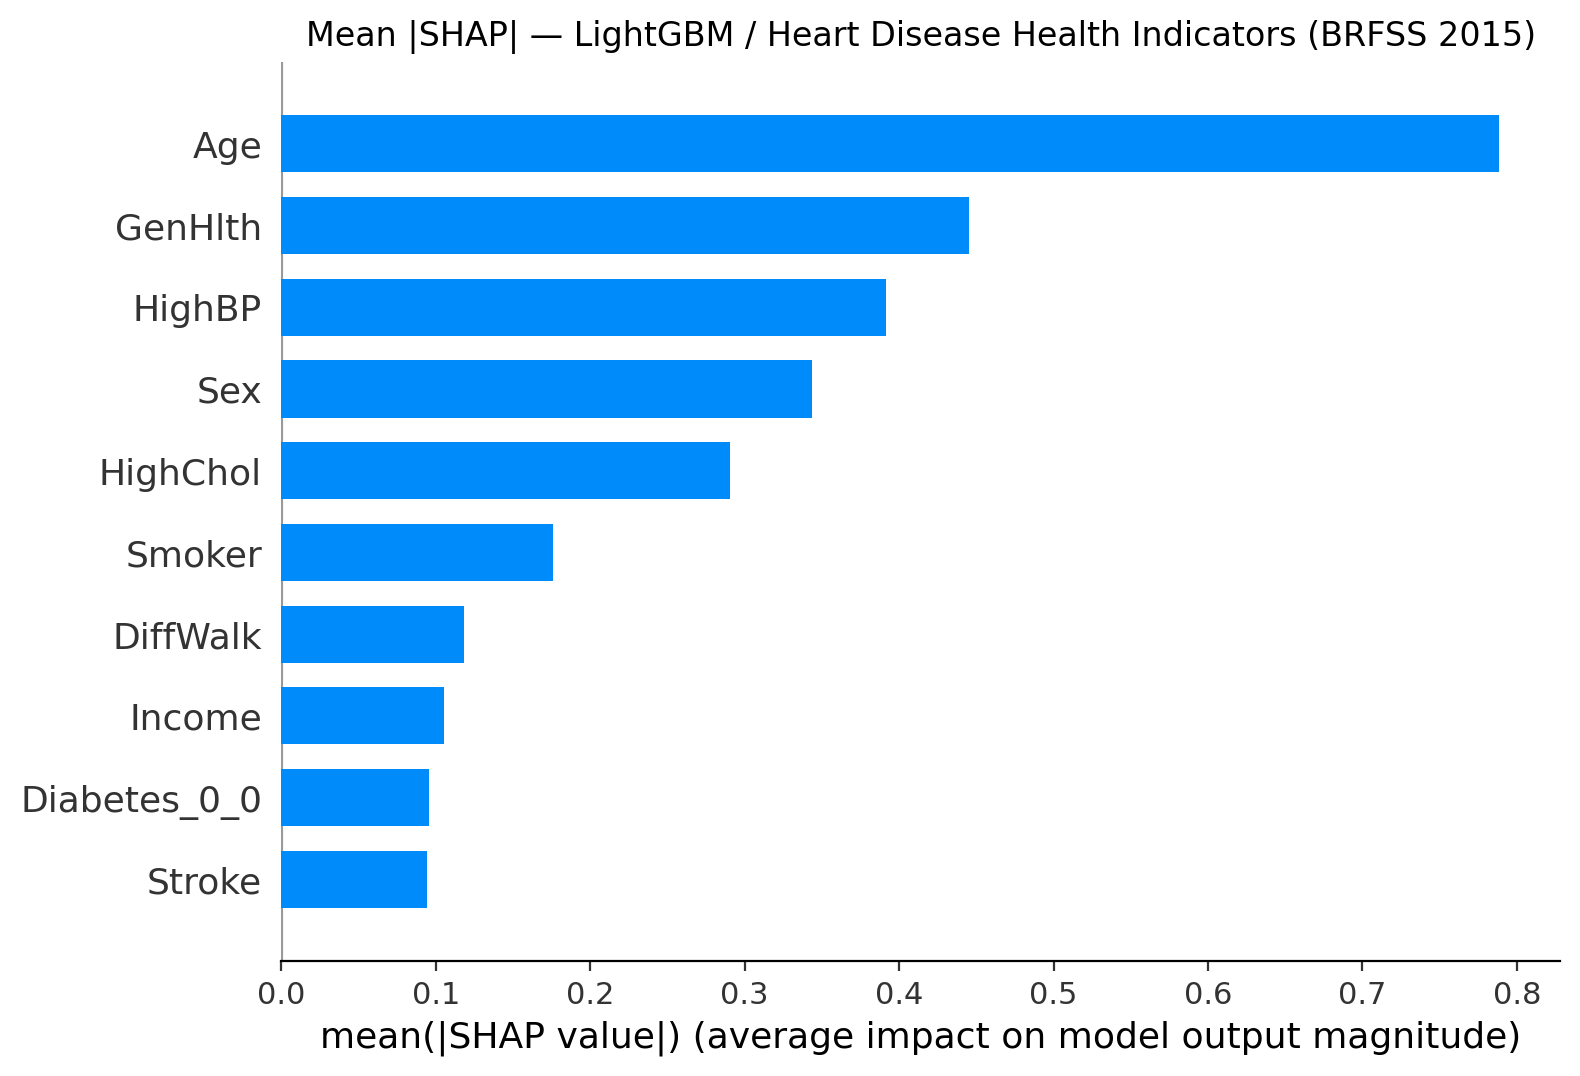

### Dataset3 Lightgbm Beeswarm

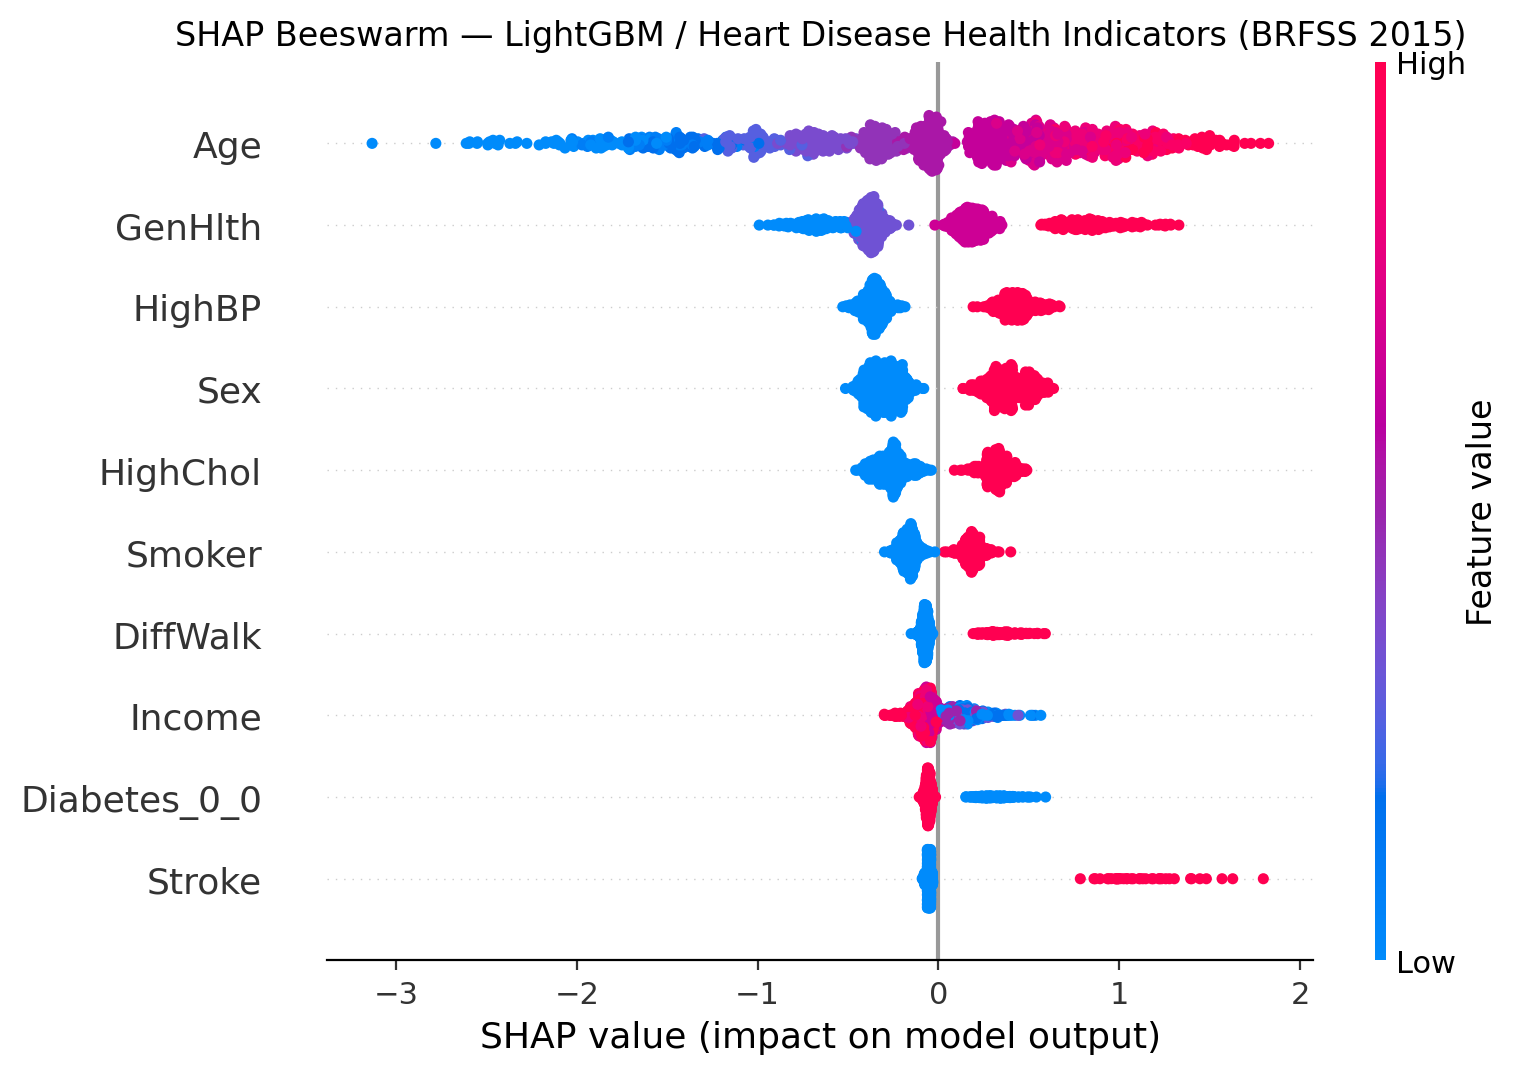

### Dataset3 Lightgbm Violin

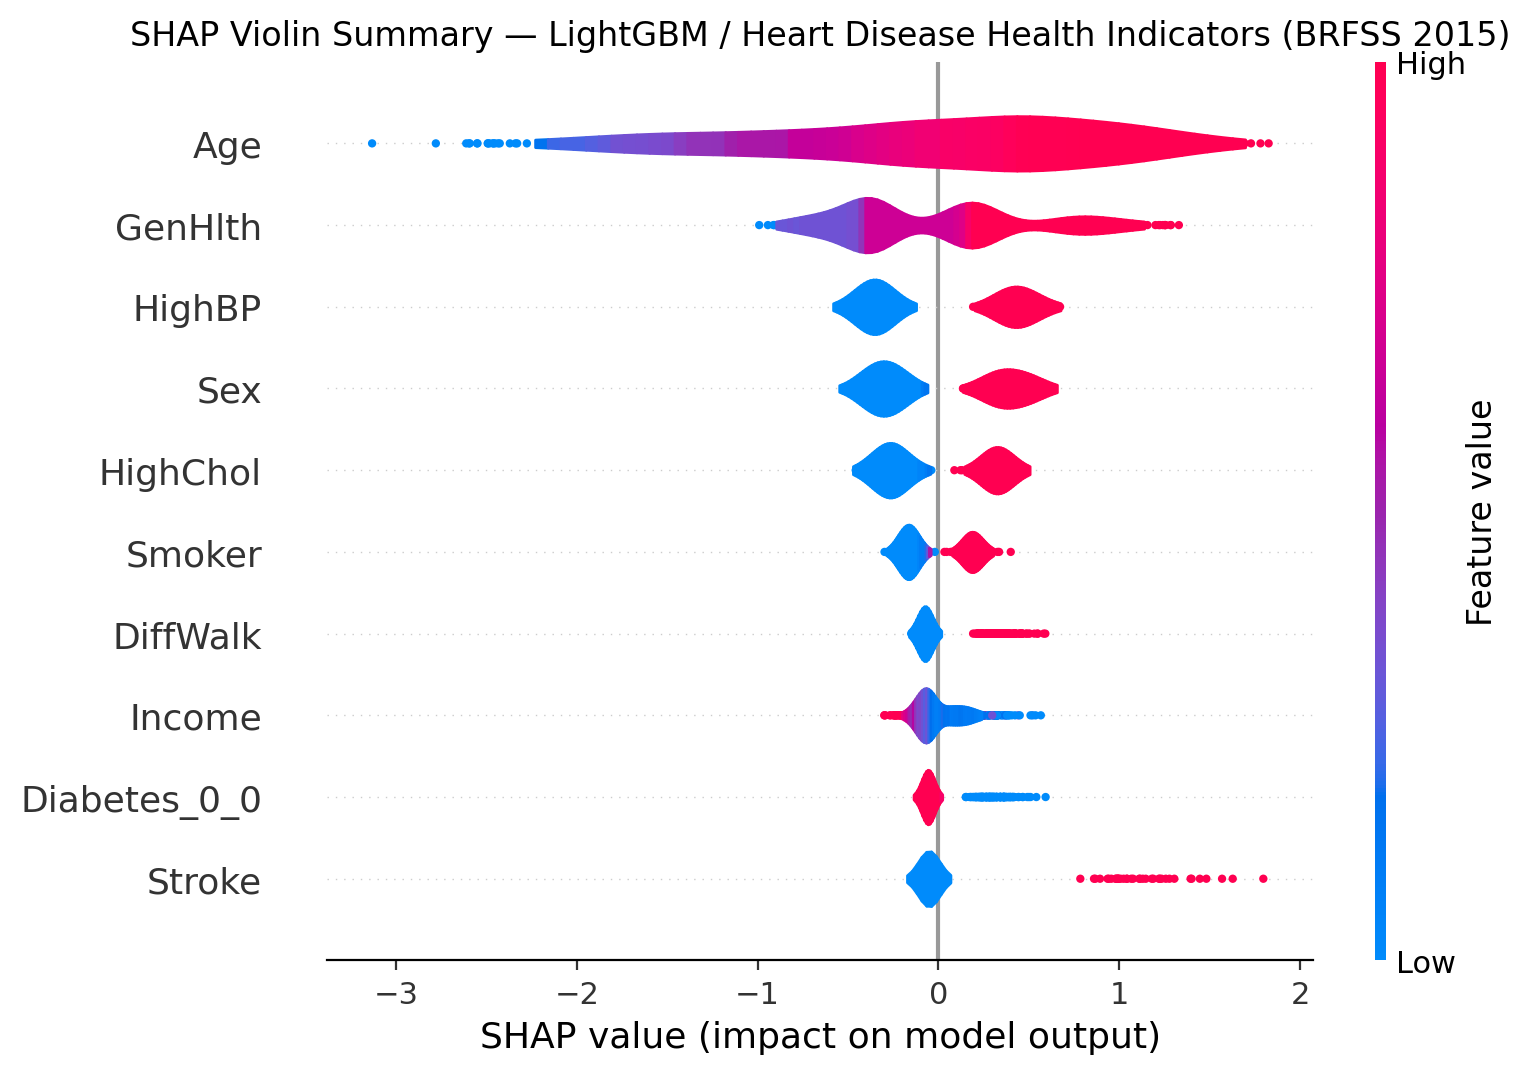

### Dataset3 Xgboost Bar

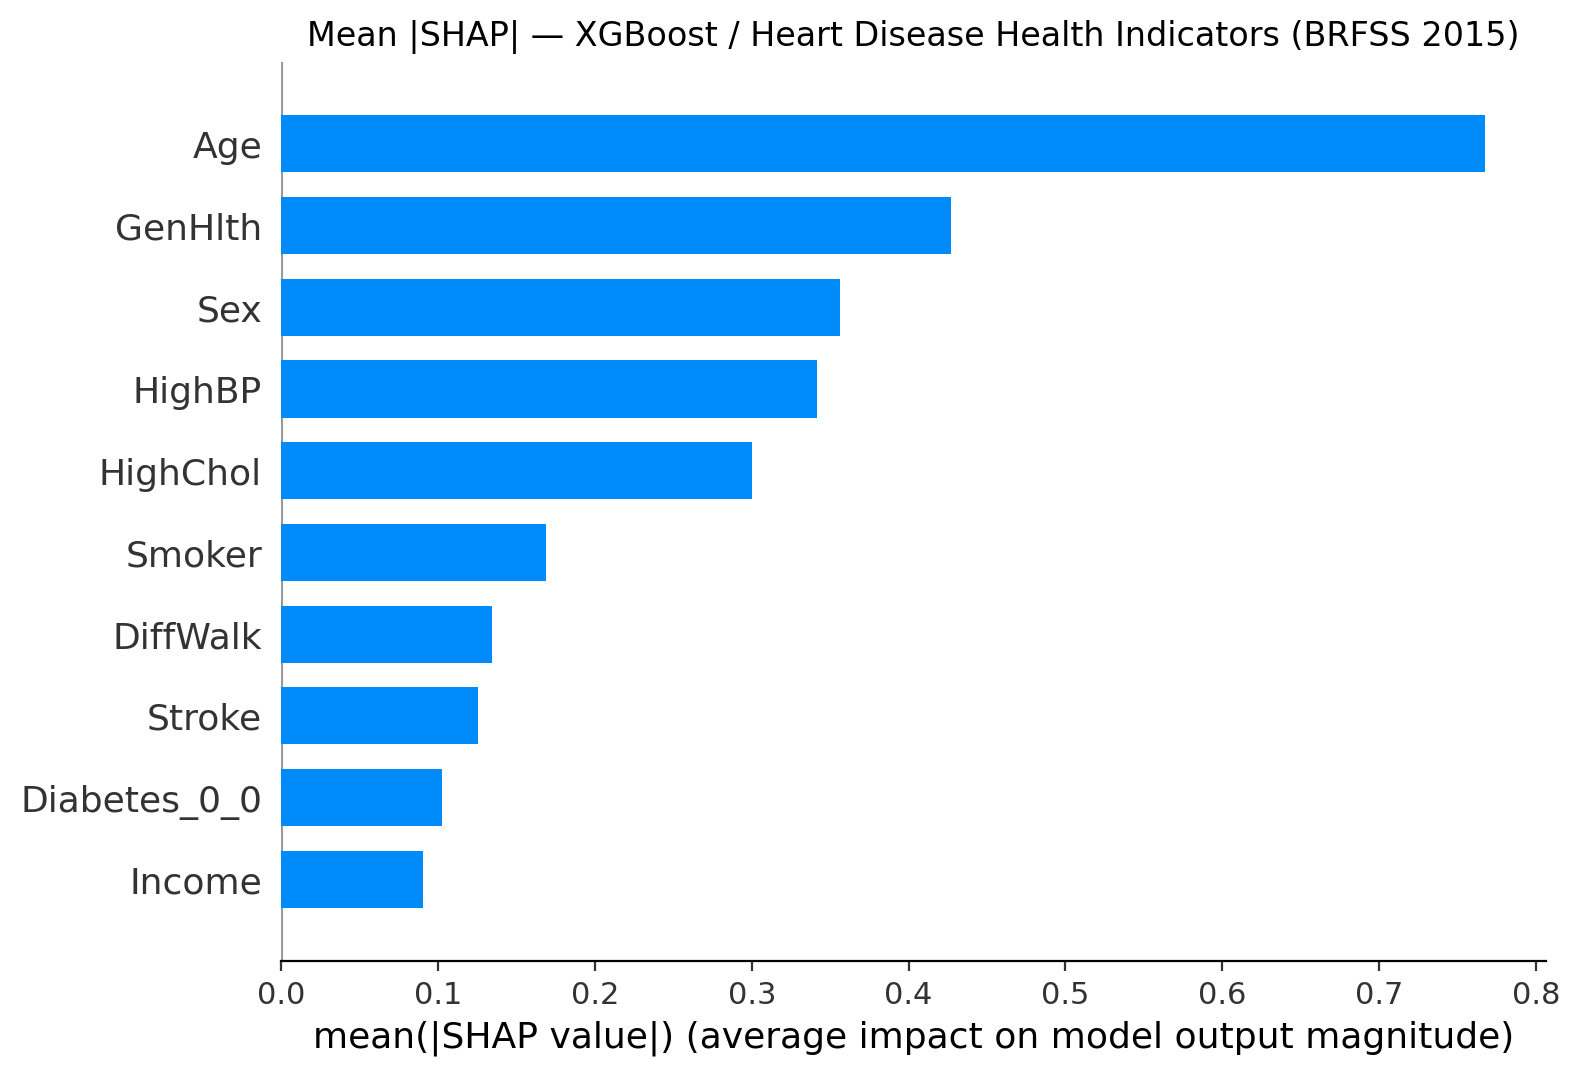

### Dataset3 Xgboost Beeswarm

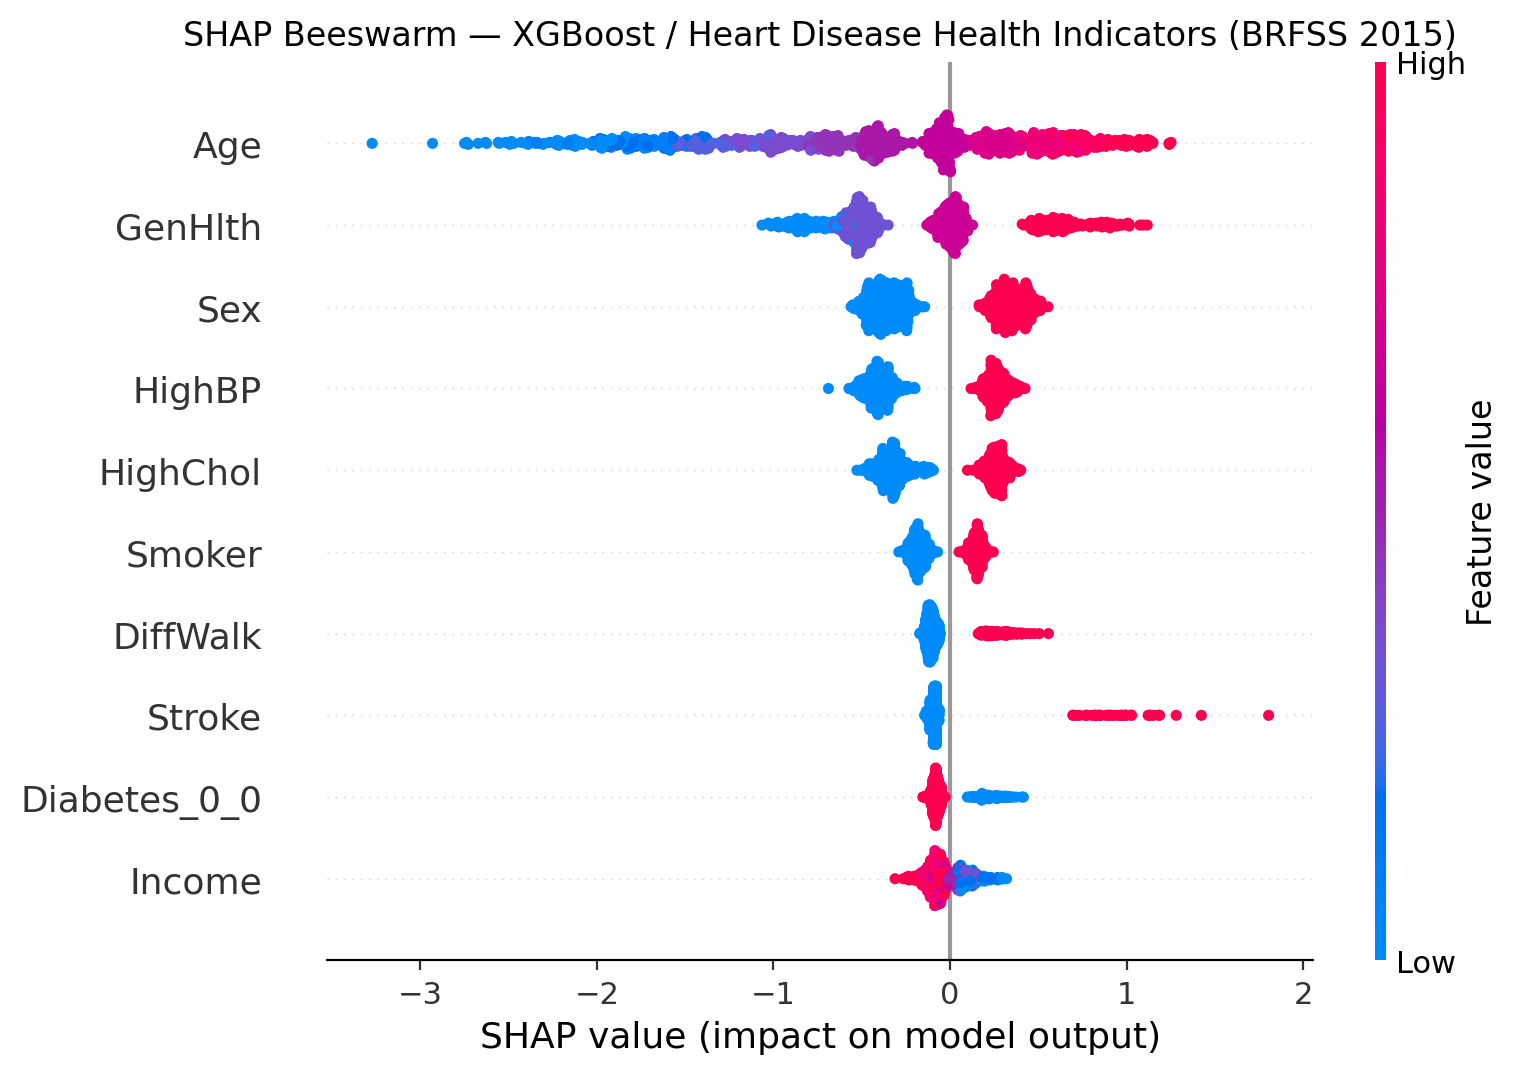

### Dataset3 Xgboost Violin

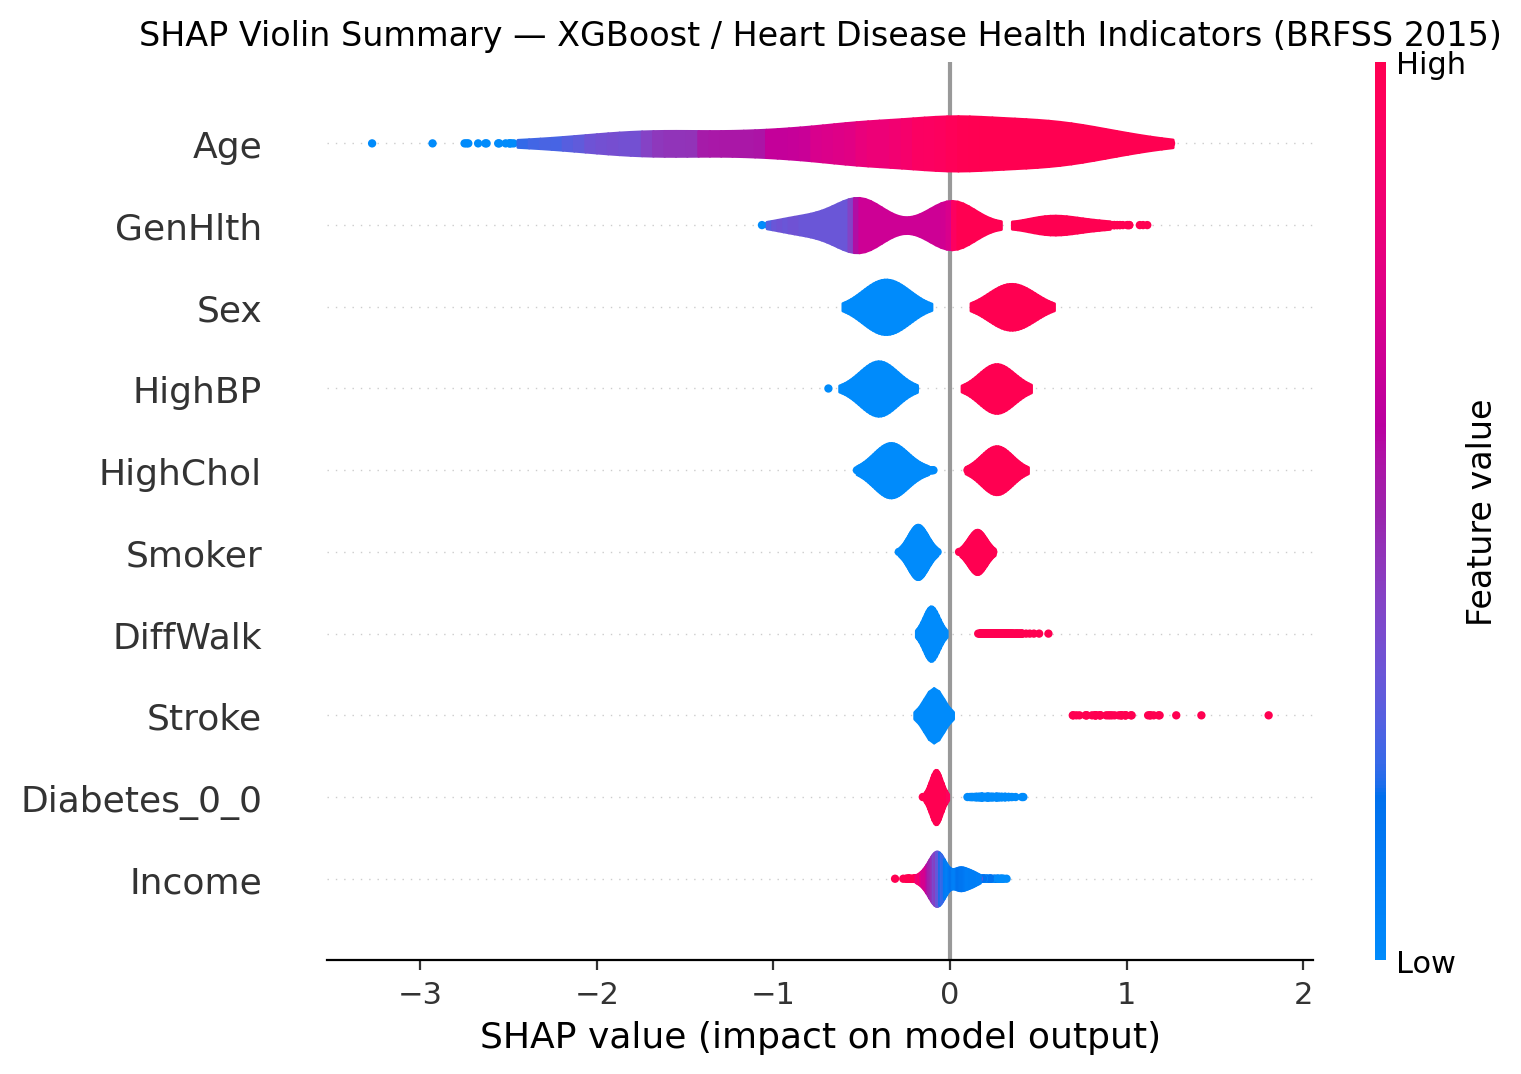

In [6]:
explainability_suffixes = ["beeswarm", "bar", "violin"]
explainability_plots = [
    path for path in sorted(PLOT_DIR.glob("*.png"))
    if any(path.stem.endswith(suffix) for suffix in explainability_suffixes)
]
print(f"Found {len(explainability_plots)} explainability plot files in {PLOT_DIR}")

for plot_path in explainability_plots:
    display(Markdown(f"### {plot_path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(plot_path), width=900))


## 7. SHAP stability summary

With five folds there are ten fold-pair comparisons per dataset/model. Kendall's $	au$ and Spearman's $
ho$ evaluate agreement over the complete feature ranking, while top-$k$ Jaccard evaluates whether the most influential features remain in the same top set.


In [7]:
rq3_table = stability_summary[[
    "dataset_name", "model_name", "pair_count", "n_folds", "n_features", "top_k",
    "kendall_tau_mean", "kendall_tau_std", "kendall_tau_min", "kendall_tau_max",
    "spearman_mean", "spearman_std", "spearman_min", "spearman_max",
    "top_k_jaccard_mean", "top_k_jaccard_std", "top_k_jaccard_min", "top_k_jaccard_max",
]].copy()
num_cols = [
    c for c in rq3_table.columns
    if c not in {"dataset_name", "model_name", "pair_count", "n_folds", "n_features", "top_k"}
]
rq3_table[num_cols] = rq3_table[num_cols].round(4)
display(rq3_table.sort_values(["dataset_name", "model_name"]))


,dataset_name,model_name,pair_count,n_folds,n_features,top_k,kendall_tau_mean,kendall_tau_std,kendall_tau_min,kendall_tau_max,spearman_mean,spearman_std,spearman_min,spearman_max,top_k_jaccard_mean,top_k_jaccard_std,top_k_jaccard_min,top_k_jaccard_max
6,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,10,5,22,10,0.9636,0.0195,0.9394,1.0000,0.9921,0.0044,0.9864,1.0000,1.0000,0.0000,1.0000,1.0
7,Heart Disease Health Indicators (BRFSS 2015),LightGBM,10,5,22,10,0.8996,0.0259,0.8528,0.9307,0.9735,0.0113,0.9548,0.9853,0.9273,0.0939,0.8182,1.0
8,Heart Disease Health Indicators (BRFSS 2015),XGBoost,10,5,22,10,0.9186,0.0262,0.8701,0.9567,0.9772,0.0119,0.9537,0.9932,1.0000,0.0000,1.0000,1.0
3,Heart Failure Prediction,AdaBoost,10,5,18,10,0.8562,0.0359,0.7778,0.9085,0.9467,0.0226,0.8989,0.9794,0.8061,0.0928,0.6667,1.0
4,Heart Failure Prediction,LightGBM,10,5,18,10,0.8458,0.0422,0.7908,0.9216,0.9480,0.0202,0.9133,0.9835,0.8545,0.0767,0.8182,1.0
5,Heart Failure Prediction,XGBoost,10,5,18,10,0.8039,0.0365,0.7647,0.8562,0.9321,0.0201,0.9092,0.9608,0.8545,0.0767,0.8182,1.0
0,Personal Key Indicators of Heart Disease (2022),AdaBoost,10,5,131,10,0.9593,0.0197,0.9216,0.9791,0.9644,0.0183,0.9292,0.9839,0.9273,0.0939,0.8182,1.0
1,Personal Key Indicators of Heart Disease (2022),LightGBM,10,5,131,10,0.8063,0.0096,0.7959,0.8170,0.9375,0.0071,0.9284,0.9500,0.7758,0.1090,0.6667,1.0
2,Personal Key Indicators of Heart Disease (2022),XGBoost,10,5,131,10,0.8018,0.0140,0.7797,0.8264,0.9359,0.0092,0.9229,0.9515,0.7758,0.1090,0.6667,1.0


### 7.1 Pairwise fold details


In [8]:
pairwise_view = pairwise_stability[[
    "dataset_name", "model_name", "fold_a", "fold_b", "kendall_tau", "spearman_rho", "top_k", "top_k_jaccard"
]].copy()
pairwise_view[["kendall_tau", "spearman_rho", "top_k_jaccard"]] = pairwise_view[["kendall_tau", "spearman_rho", "top_k_jaccard"]].round(4)
display(pairwise_view.sort_values(["dataset_name", "model_name", "fold_a", "fold_b"]))


,dataset_name,model_name,fold_a,fold_b,kendall_tau,spearman_rho,top_k,top_k_jaccard
60,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,1,2,0.9740,0.9932,10,1.0000
61,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,1,3,0.9394,0.9864,10,1.0000
62,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,1,4,0.9740,0.9955,10,1.0000
63,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,1,5,1.0000,1.0000,10,1.0000
64,Heart Disease Health Indicators (BRFSS 2015),AdaBoost,2,3,0.9654,0.9932,10,1.0000
...,...,...,...,...,...,...,...,...
15,Personal Key Indicators of Heart Disease (2022),XGBoost,2,4,0.7877,0.9250,10,0.6667
16,Personal Key Indicators of Heart Disease (2022),XGBoost,2,5,0.7907,0.9269,10,1.0000
17,Personal Key Indicators of Heart Disease (2022),XGBoost,3,4,0.8020,0.9371,10,0.6667
18,Personal Key Indicators of Heart Disease (2022),XGBoost,3,5,0.8060,0.9358,10,0.8182


### 7.2 Stability overview plot

The chart below compares mean Spearman stability across dataset/model combinations. Higher values indicate that SHAP rankings are more consistent from one fold to another.


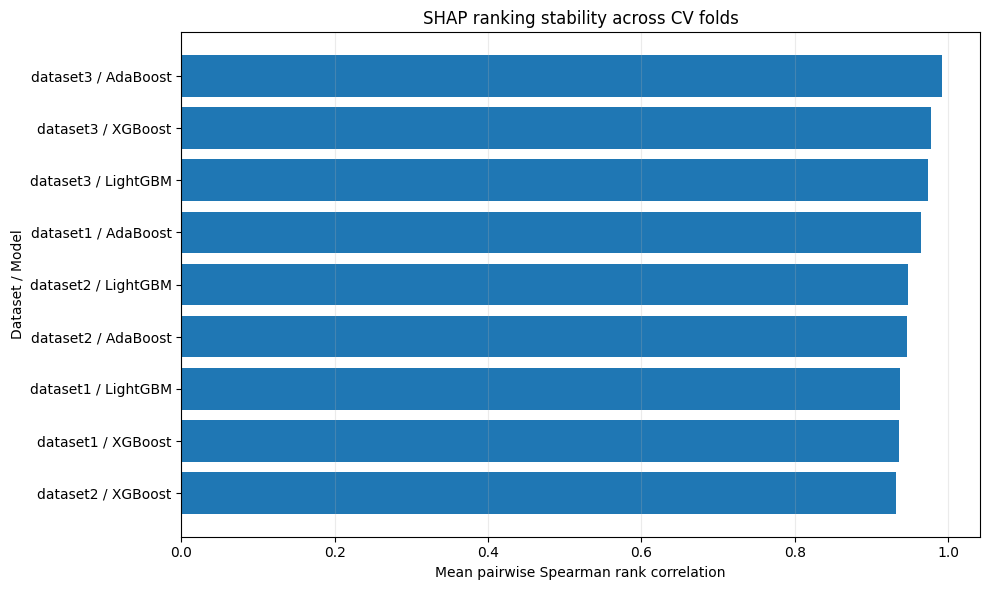

In [9]:
stability_plot = stability_summary.copy()
stability_plot["label"] = stability_plot["dataset_key"] + " / " + stability_plot["model_name"]
stability_plot = stability_plot.sort_values("spearman_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(stability_plot["label"], stability_plot["spearman_mean"])
ax.set_xlabel("Mean pairwise Spearman rank correlation")
ax.set_ylabel("Dataset / Model")
ax.set_title("SHAP ranking stability across CV folds")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Stability heatmaps

The runner also saves two stability heatmaps for each dataset/model pair:

- **Feature-ranking heatmap**: shows the fold-specific rank of the most important consensus features. Lower ranks indicate higher importance.
- **Fold-correlation heatmap**: shows pairwise Spearman rank correlation between folds.

Together, these plots make it easier to see whether instability is widespread or driven by a few features/folds.


Found 18 stability plot files in D:\Cert AIO\Mod3\healthcare-risk-prediction\results\shap_explainability\plots


### Dataset1 Adaboost Fold Correlation Heatmap

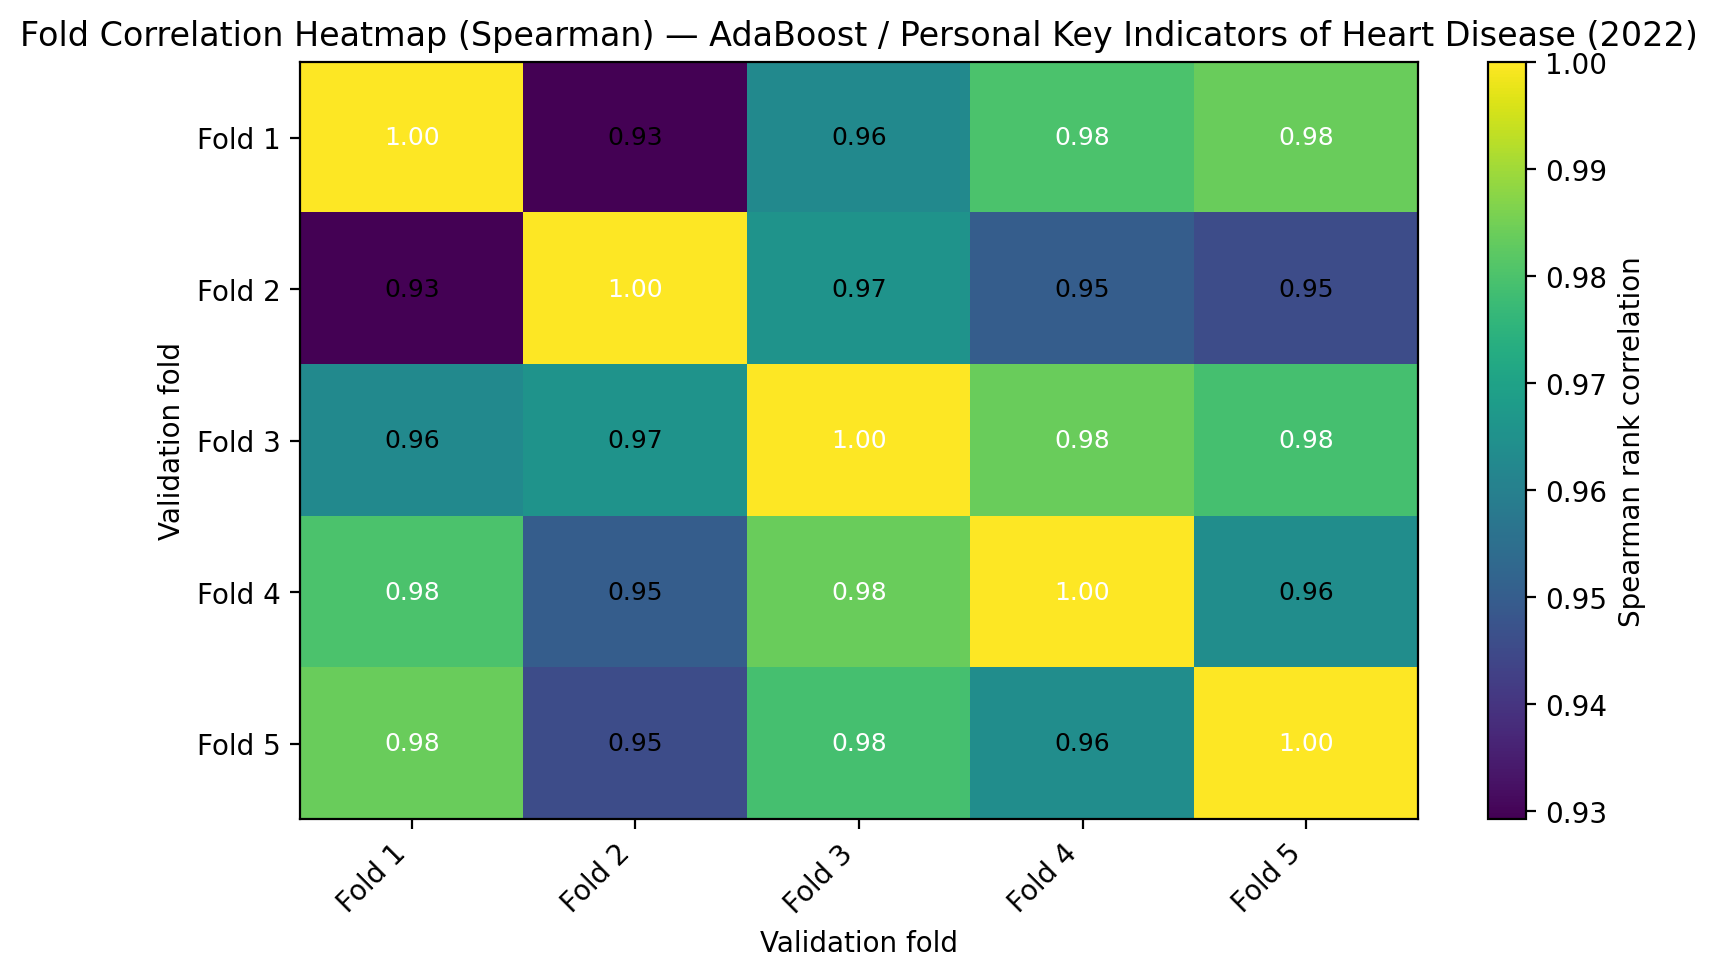

### Dataset1 Adaboost Ranking Heatmap

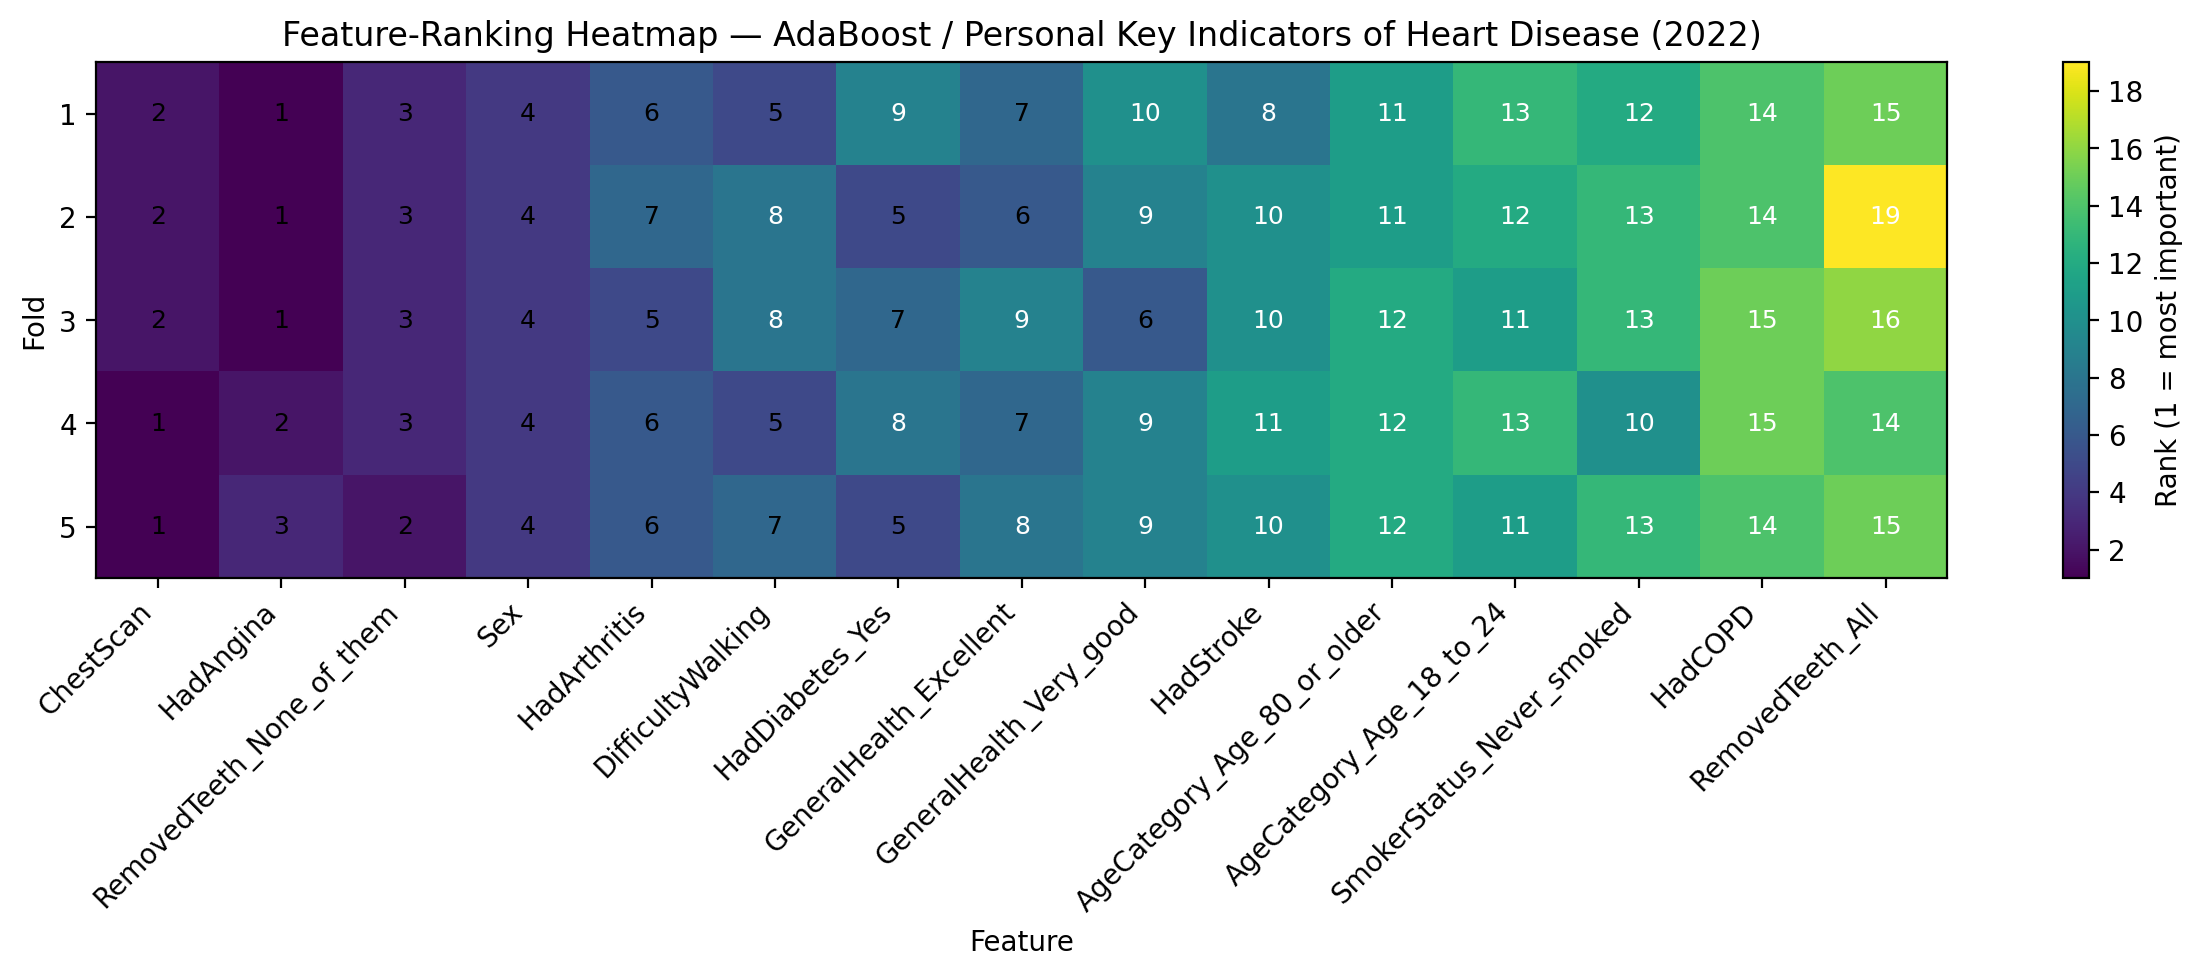

### Dataset1 Lightgbm Fold Correlation Heatmap

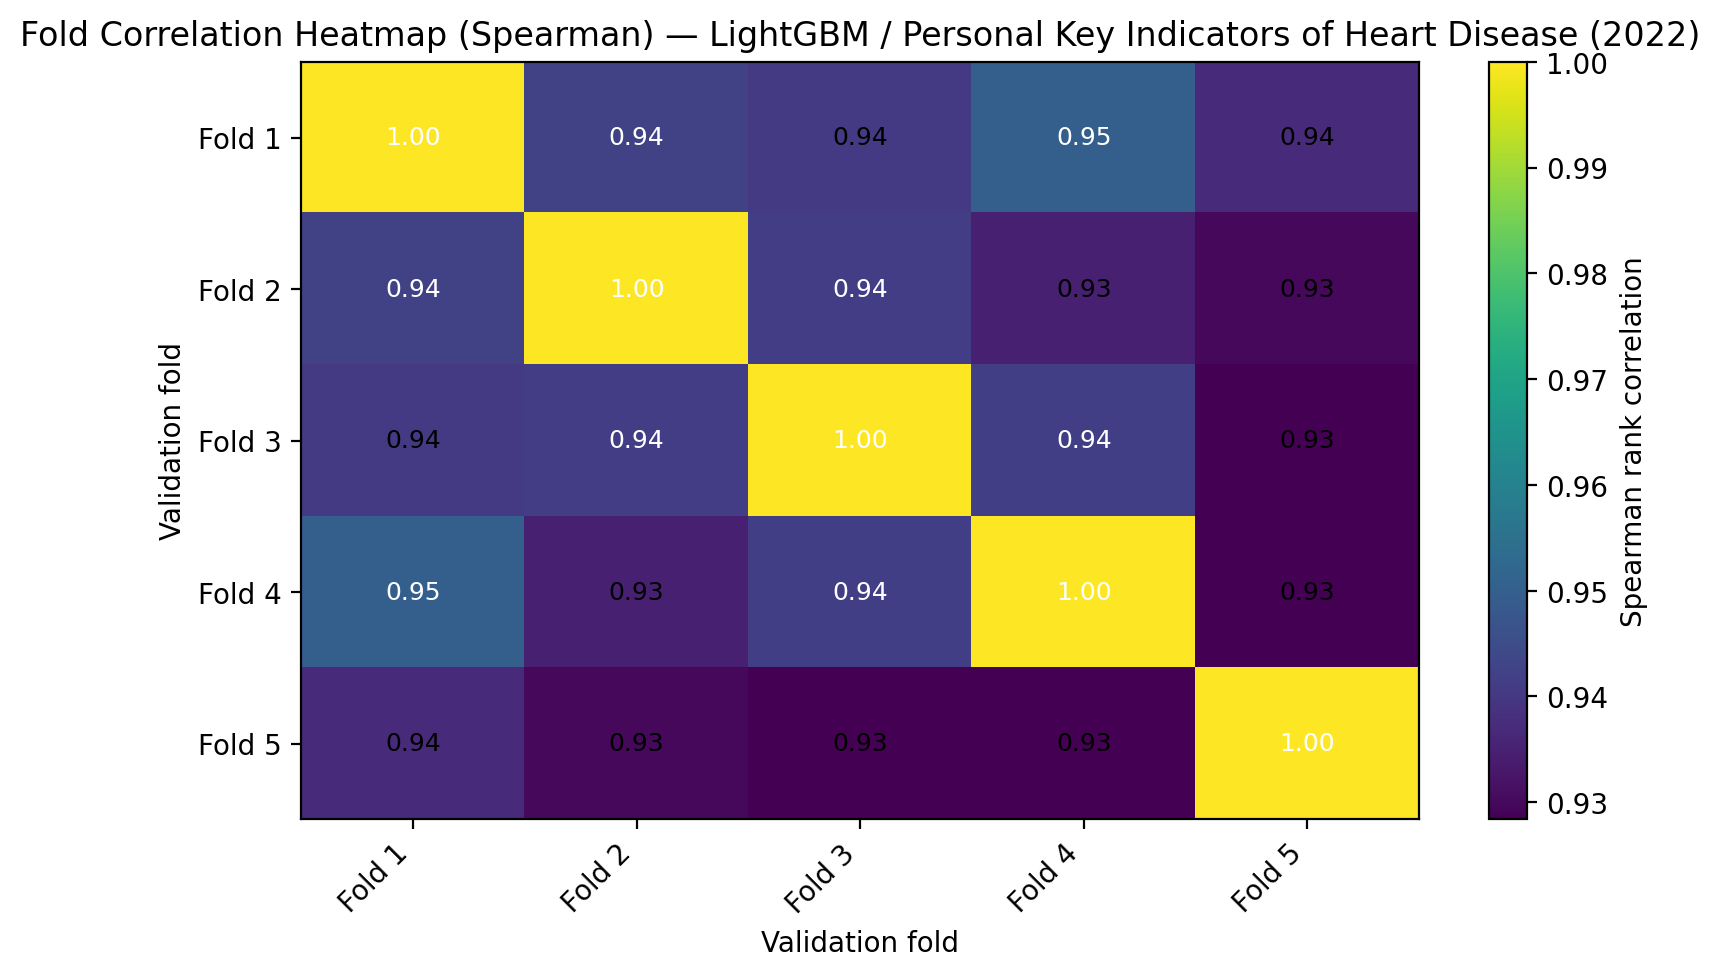

### Dataset1 Lightgbm Ranking Heatmap

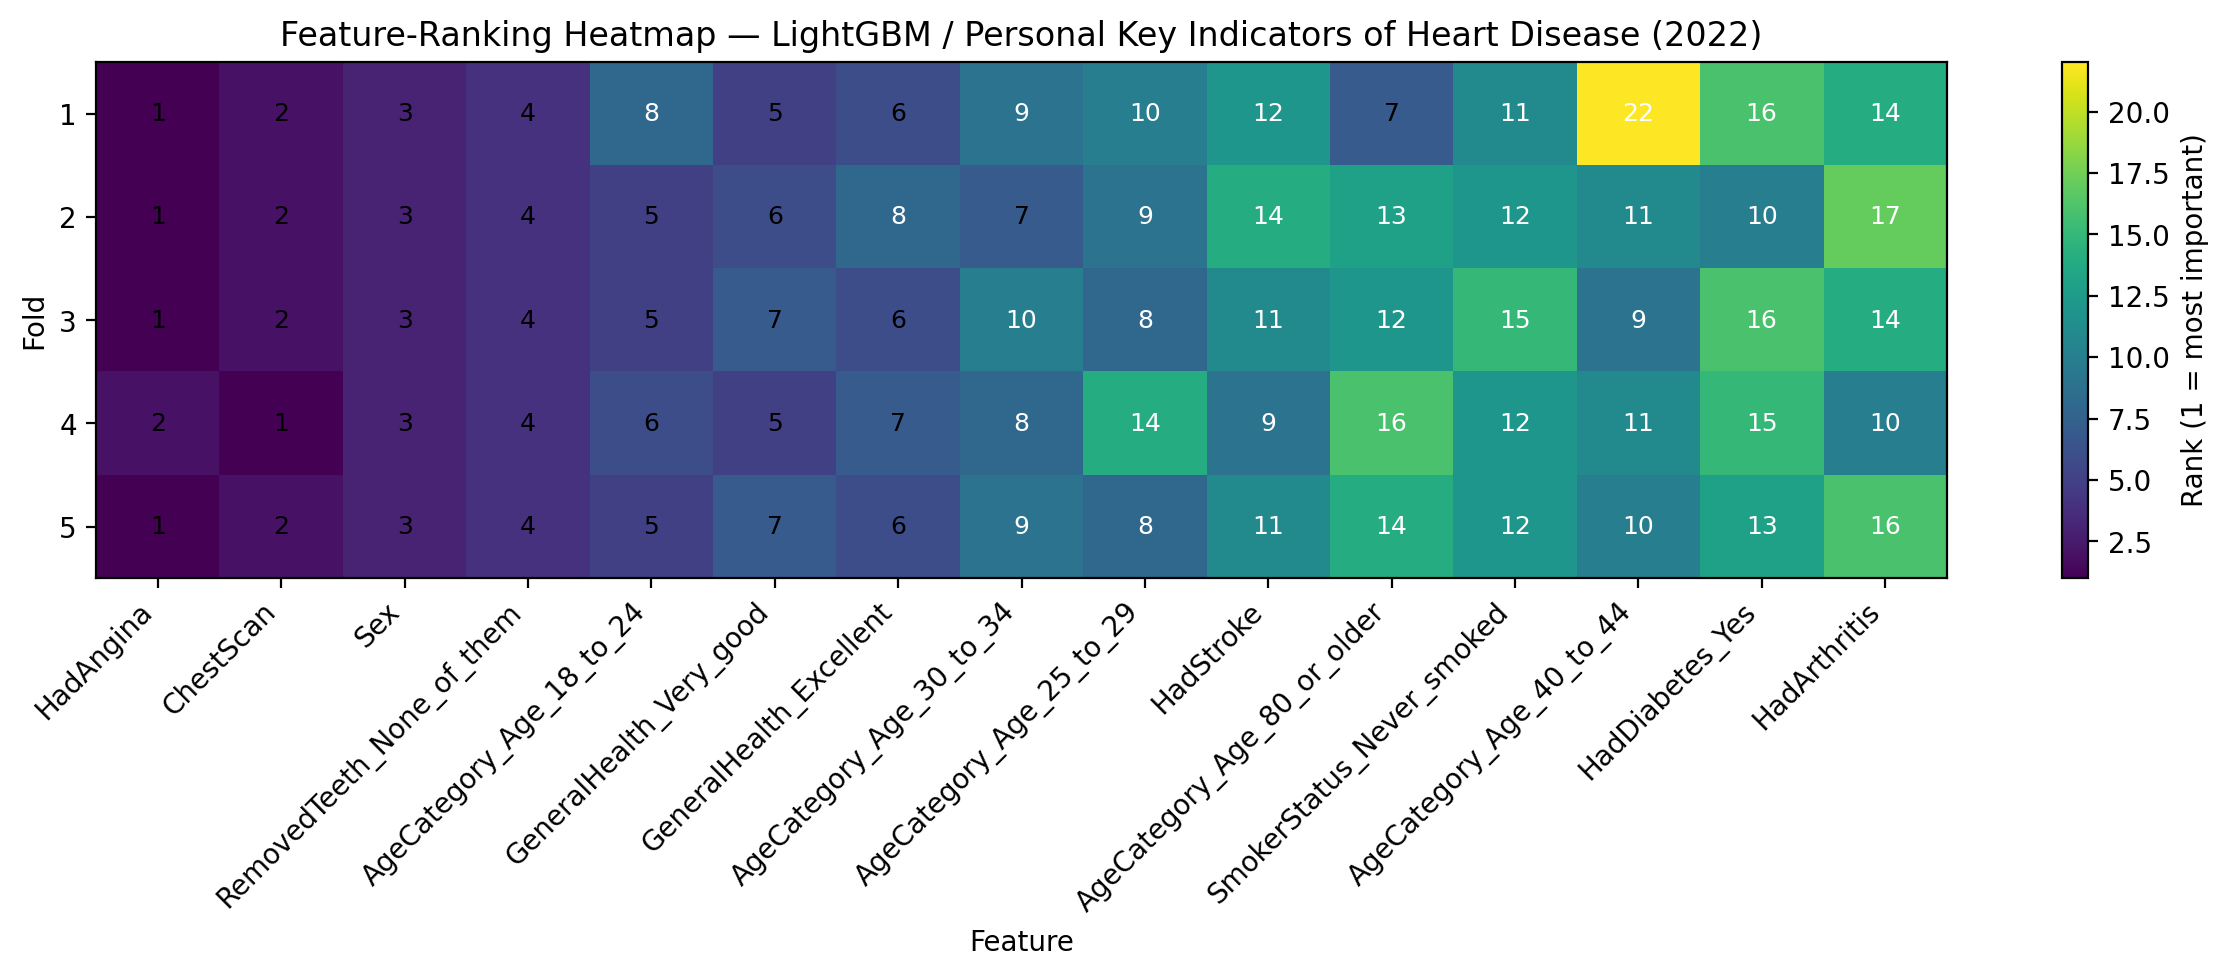

### Dataset1 Xgboost Fold Correlation Heatmap

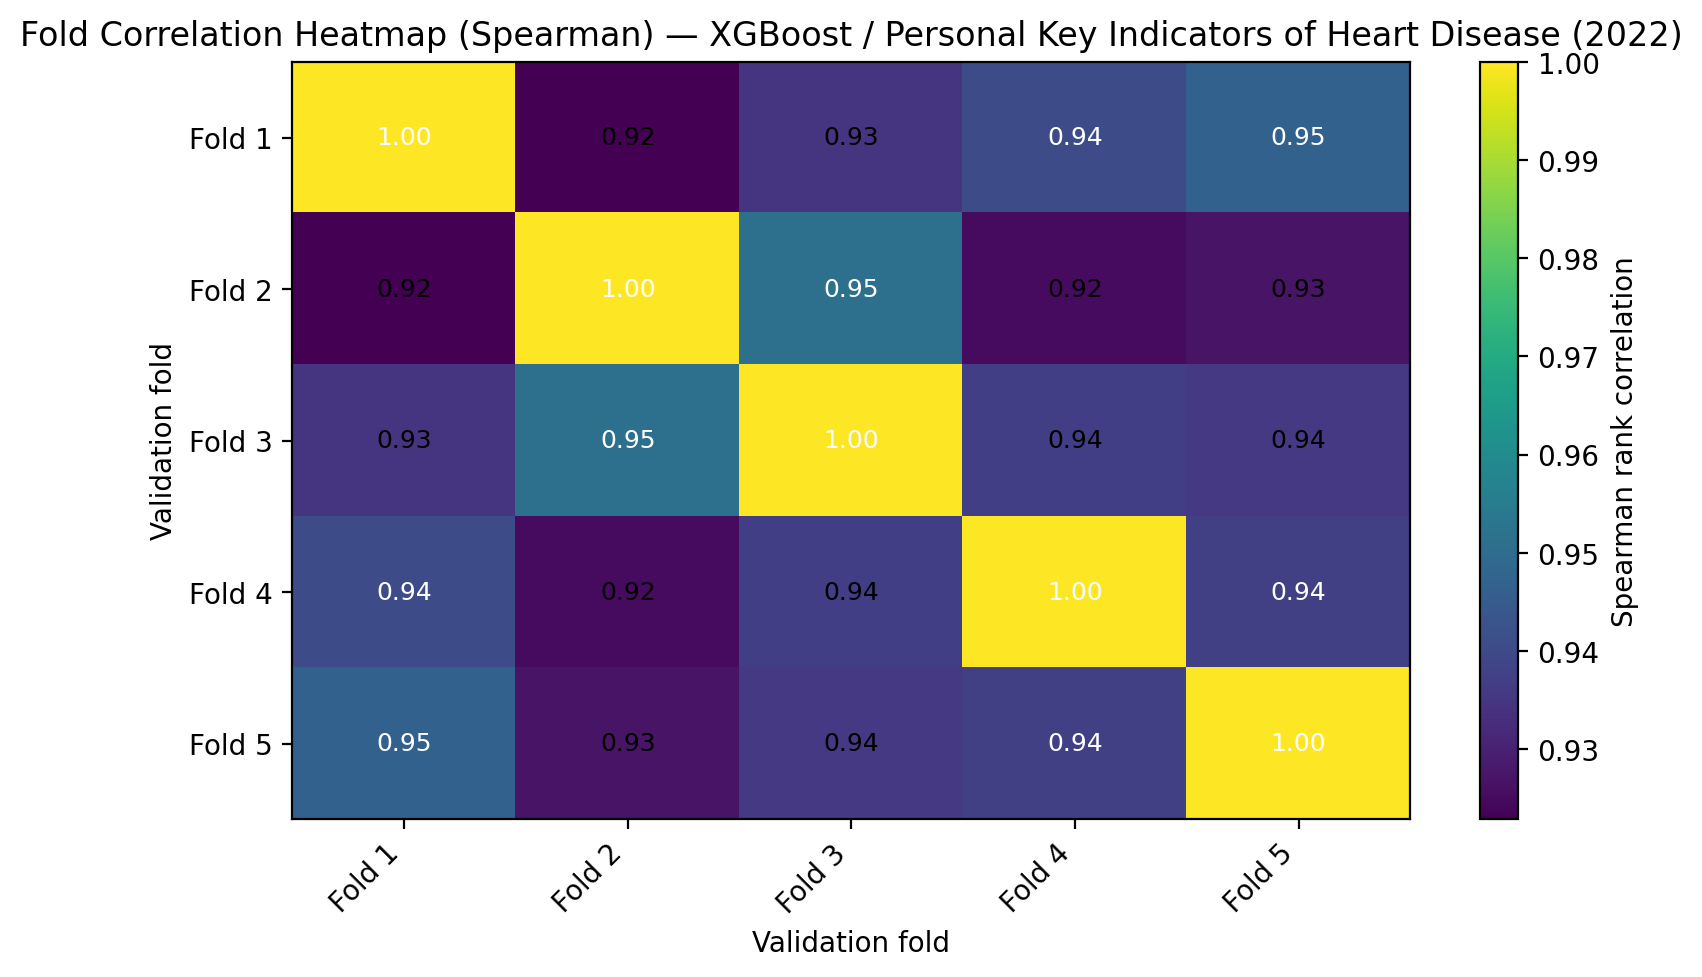

### Dataset1 Xgboost Ranking Heatmap

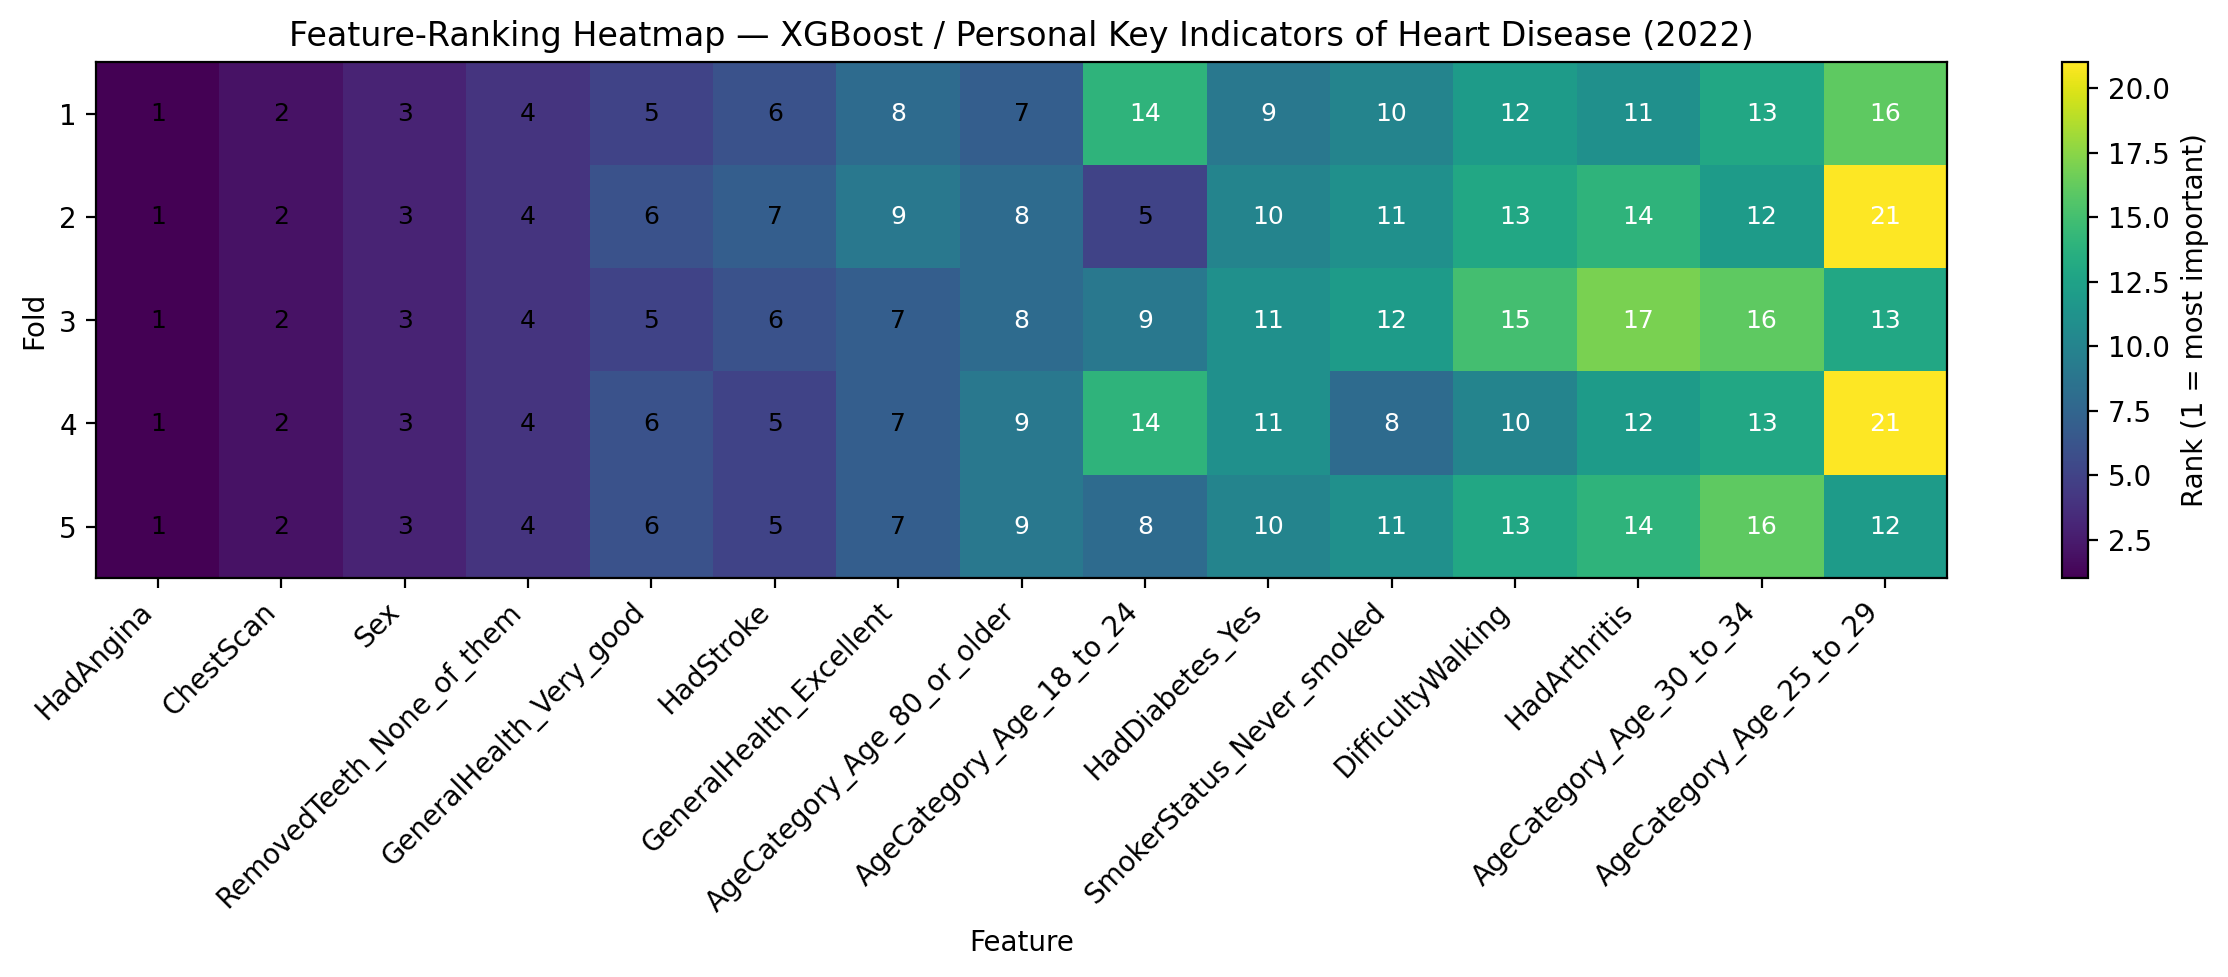

### Dataset2 Adaboost Fold Correlation Heatmap

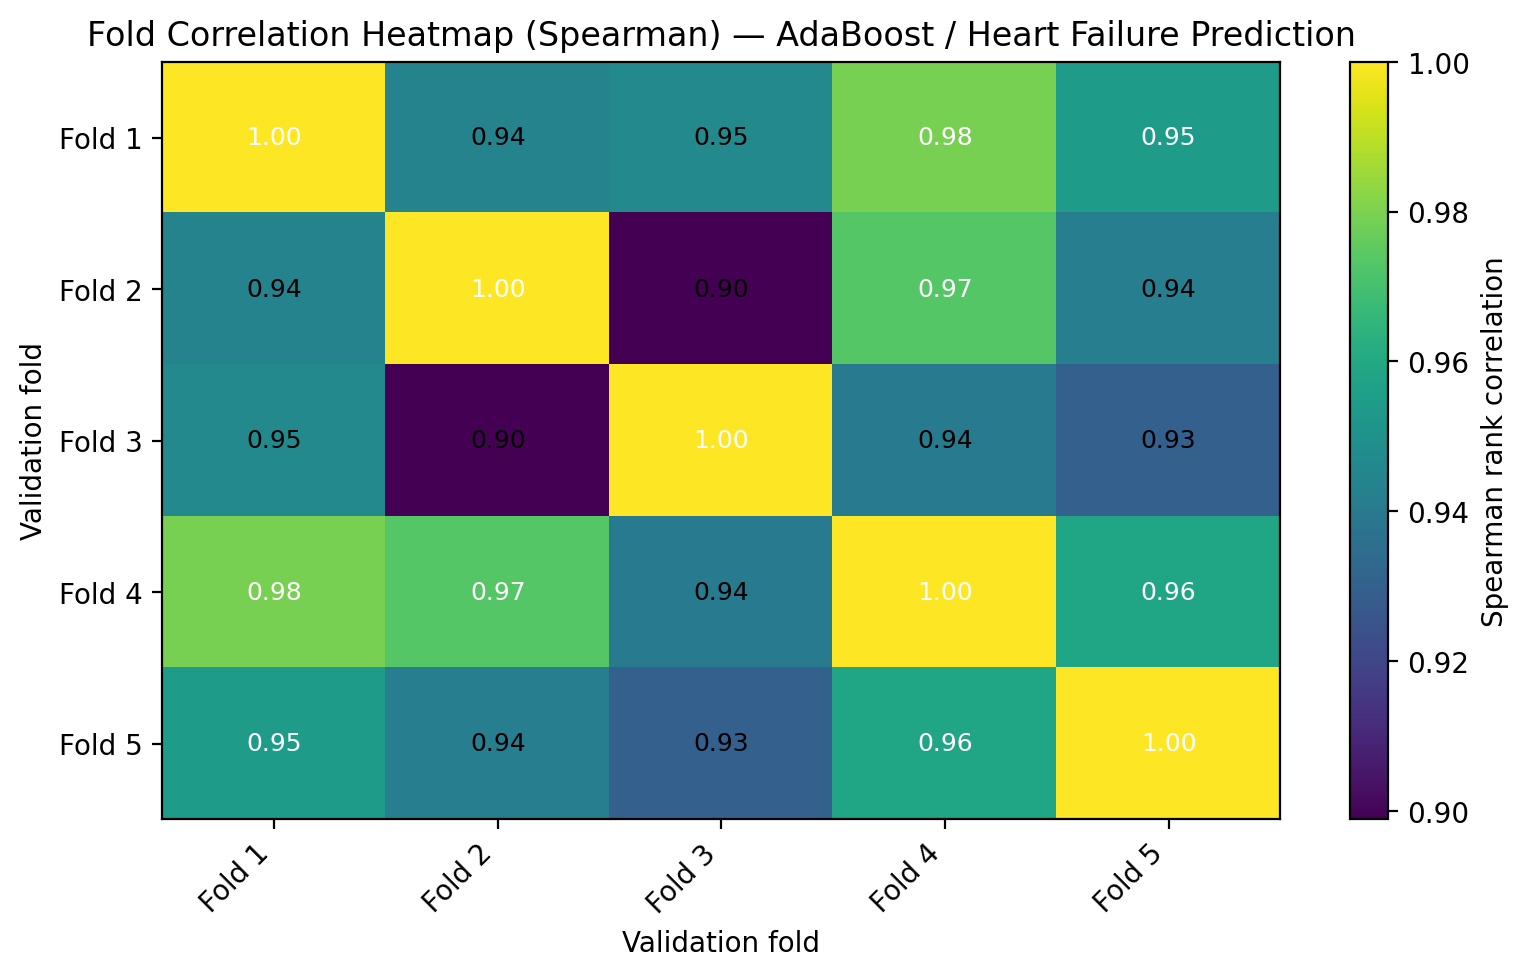

### Dataset2 Adaboost Ranking Heatmap

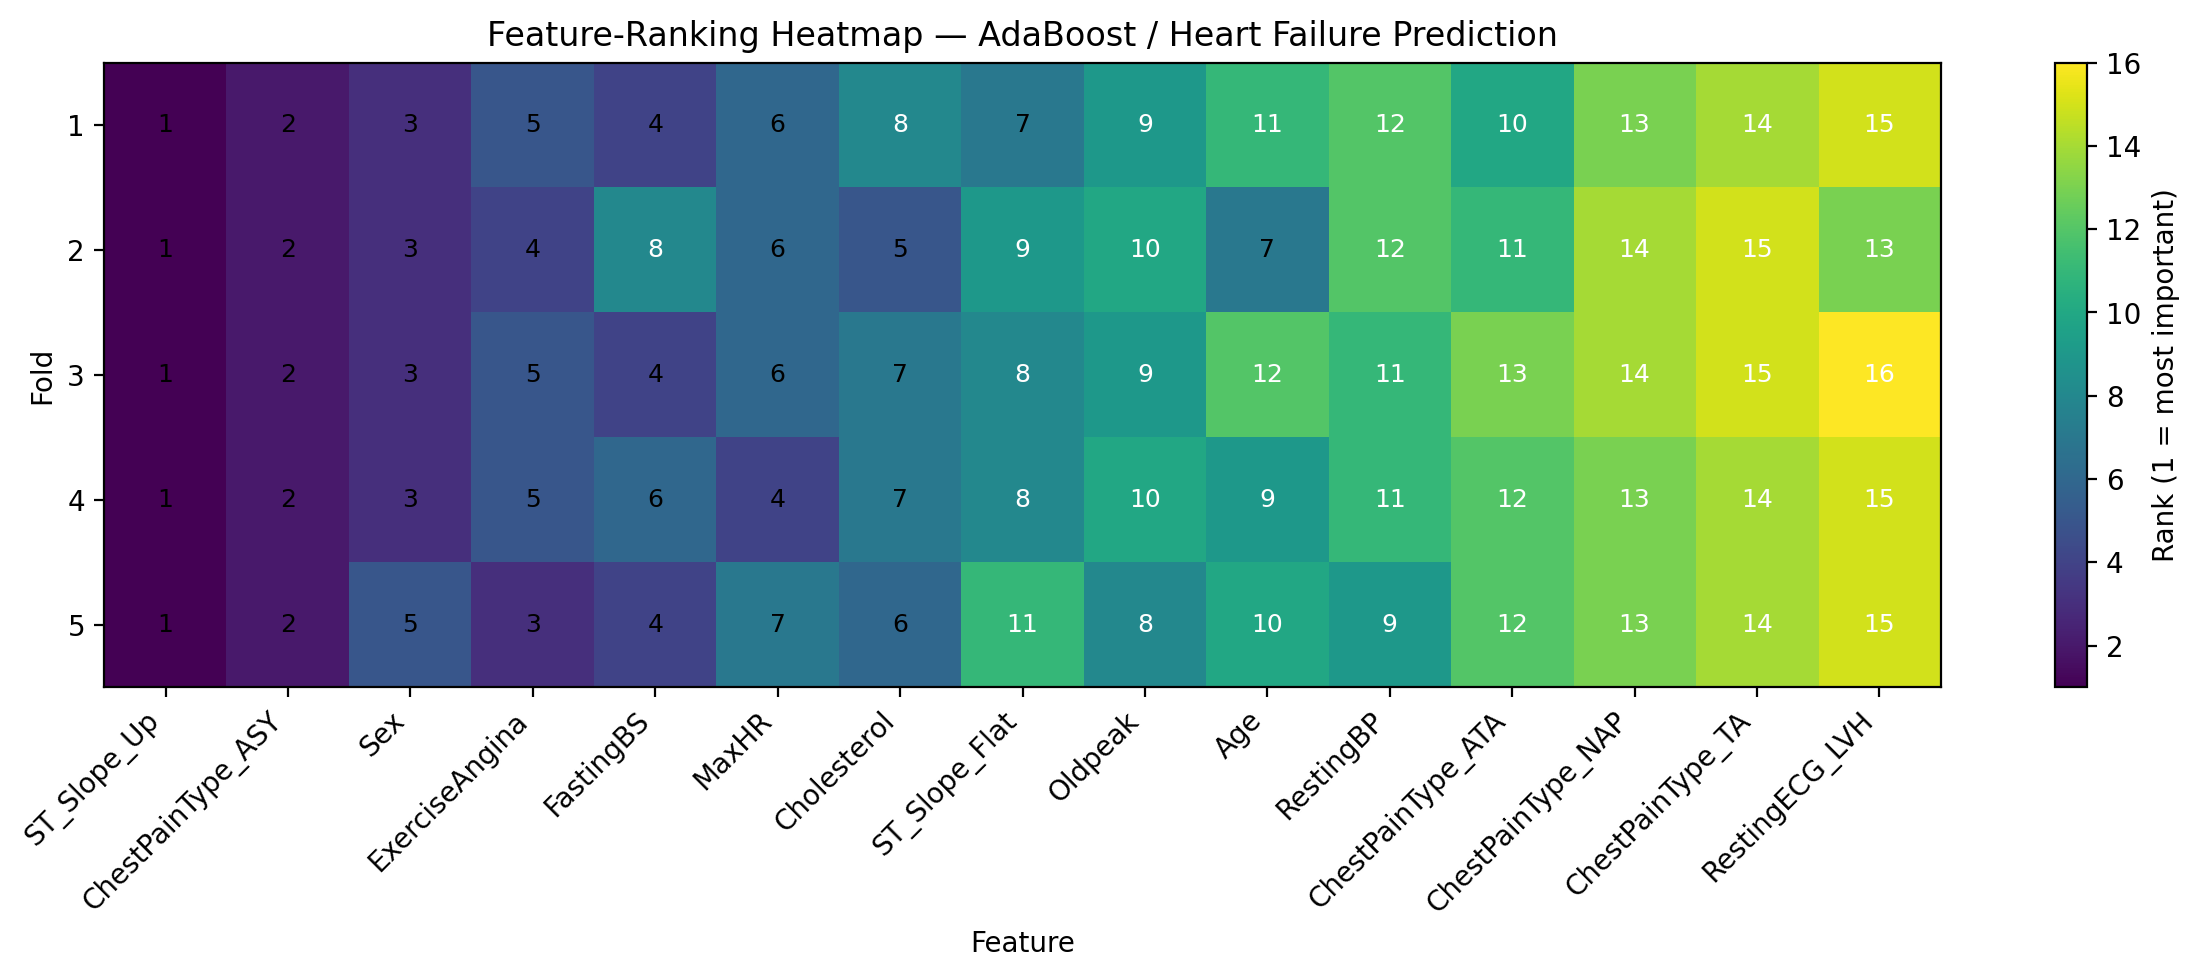

### Dataset2 Lightgbm Fold Correlation Heatmap

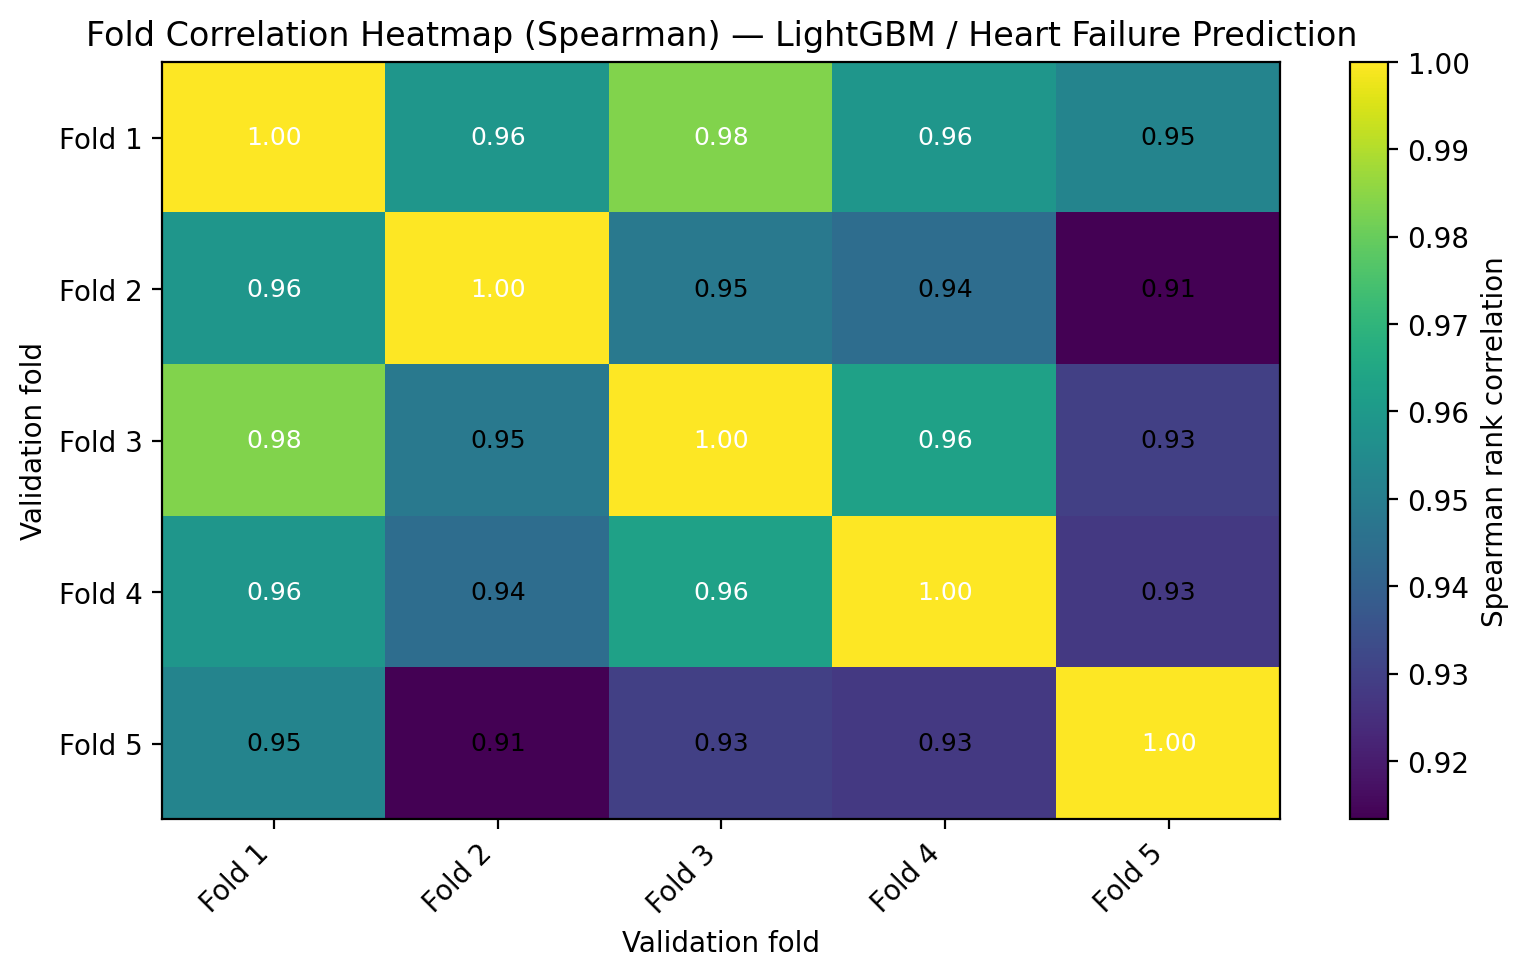

### Dataset2 Lightgbm Ranking Heatmap

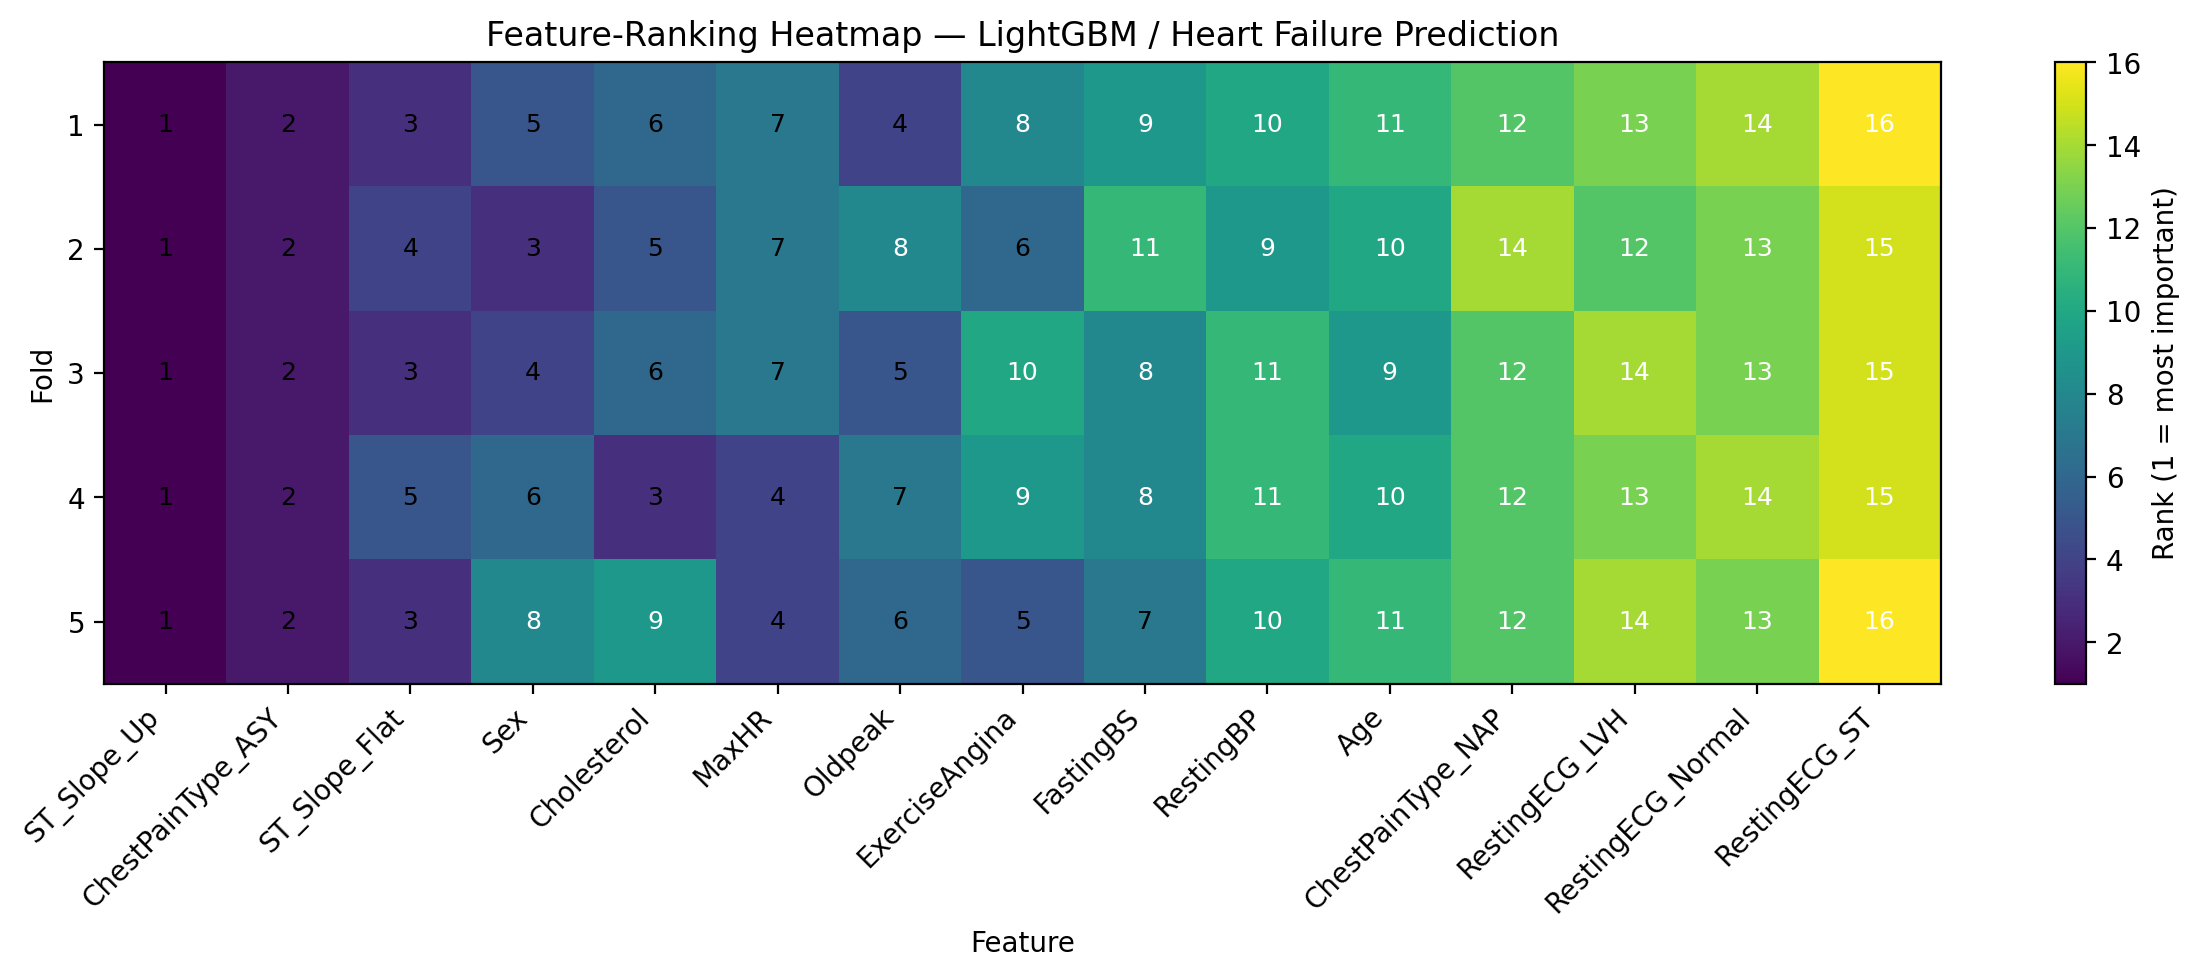

### Dataset2 Xgboost Fold Correlation Heatmap

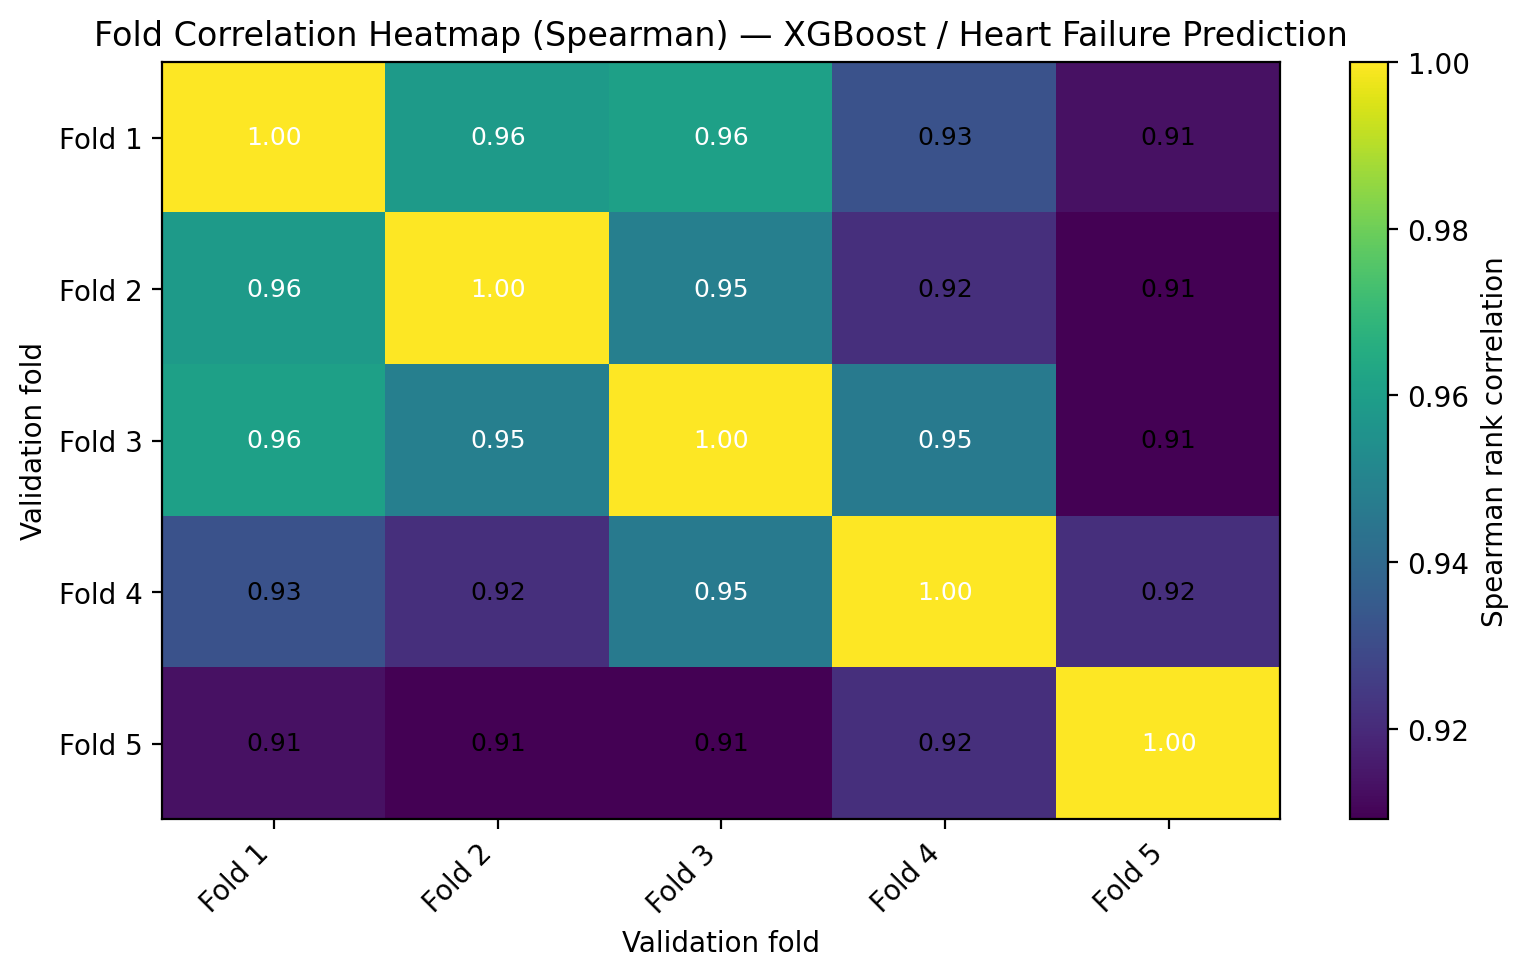

### Dataset2 Xgboost Ranking Heatmap

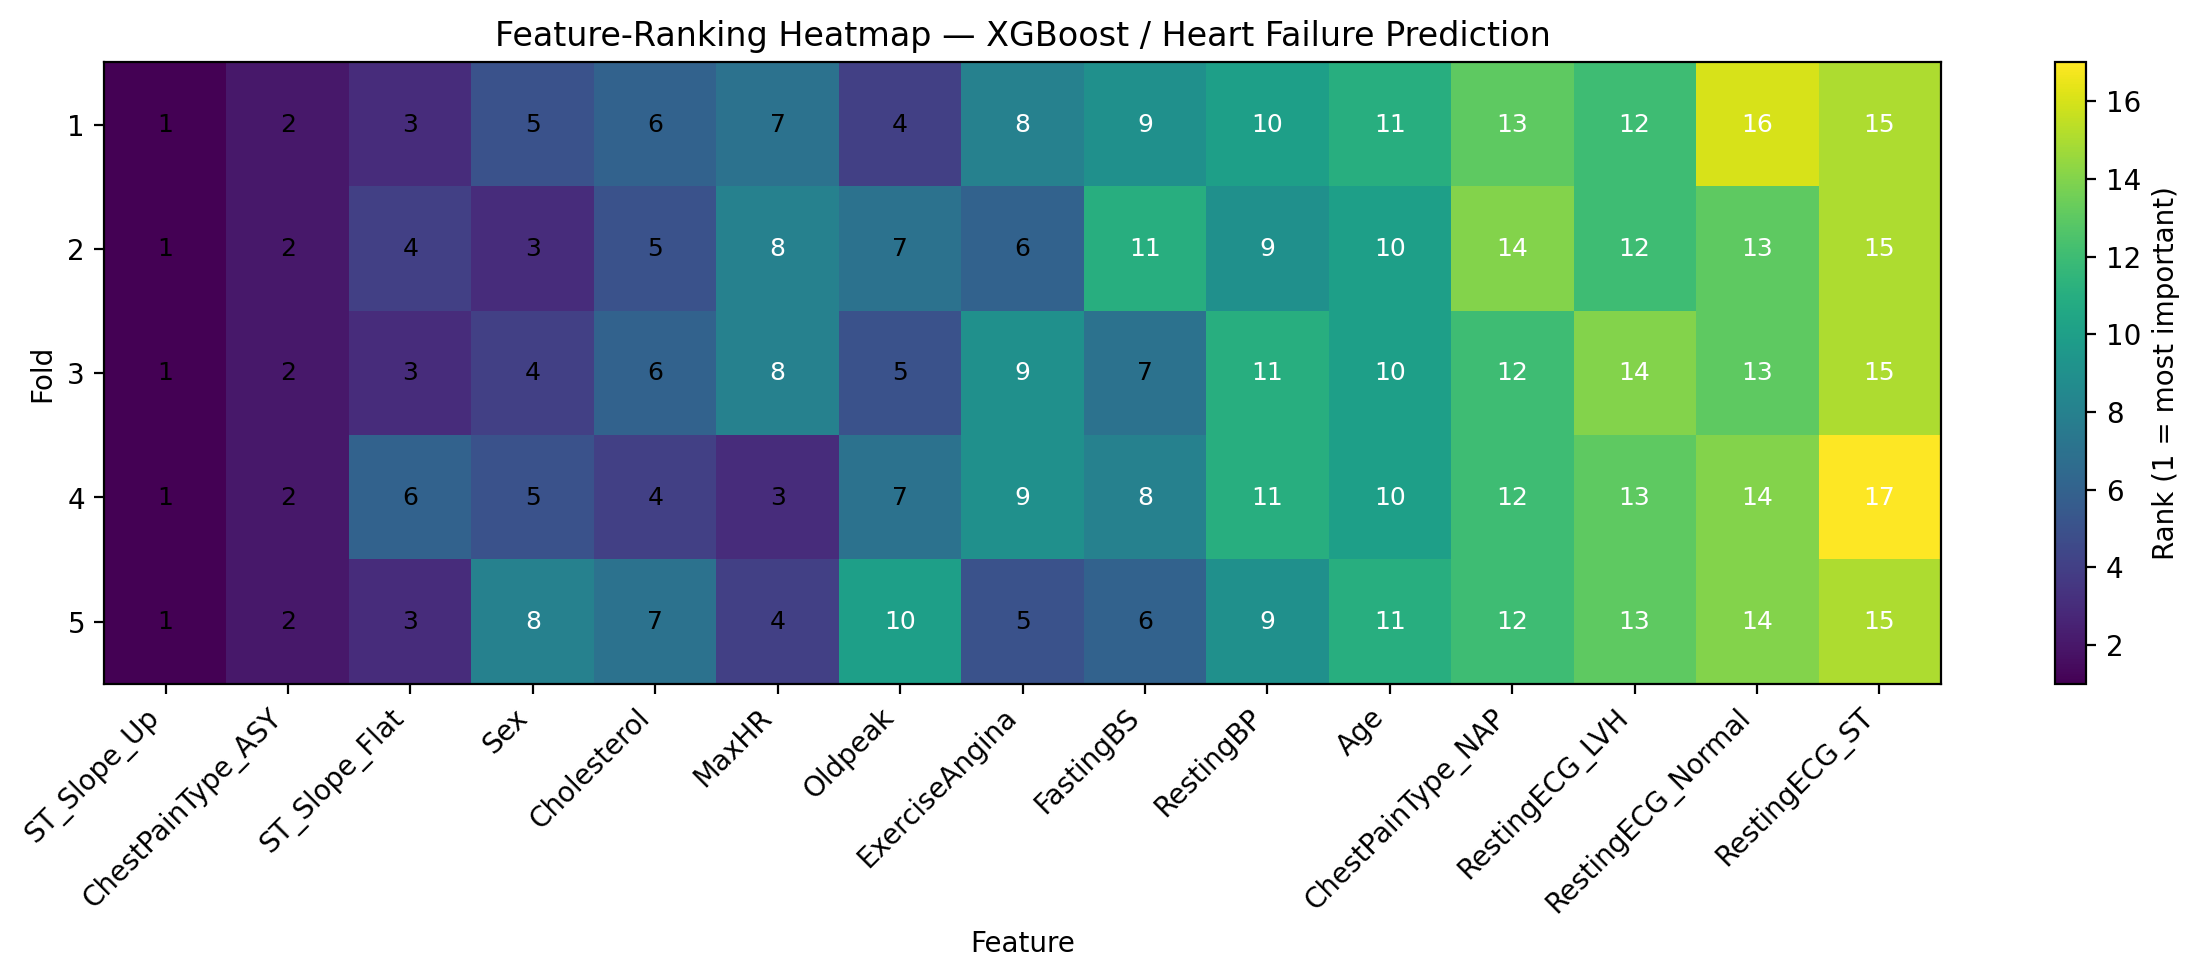

### Dataset3 Adaboost Fold Correlation Heatmap

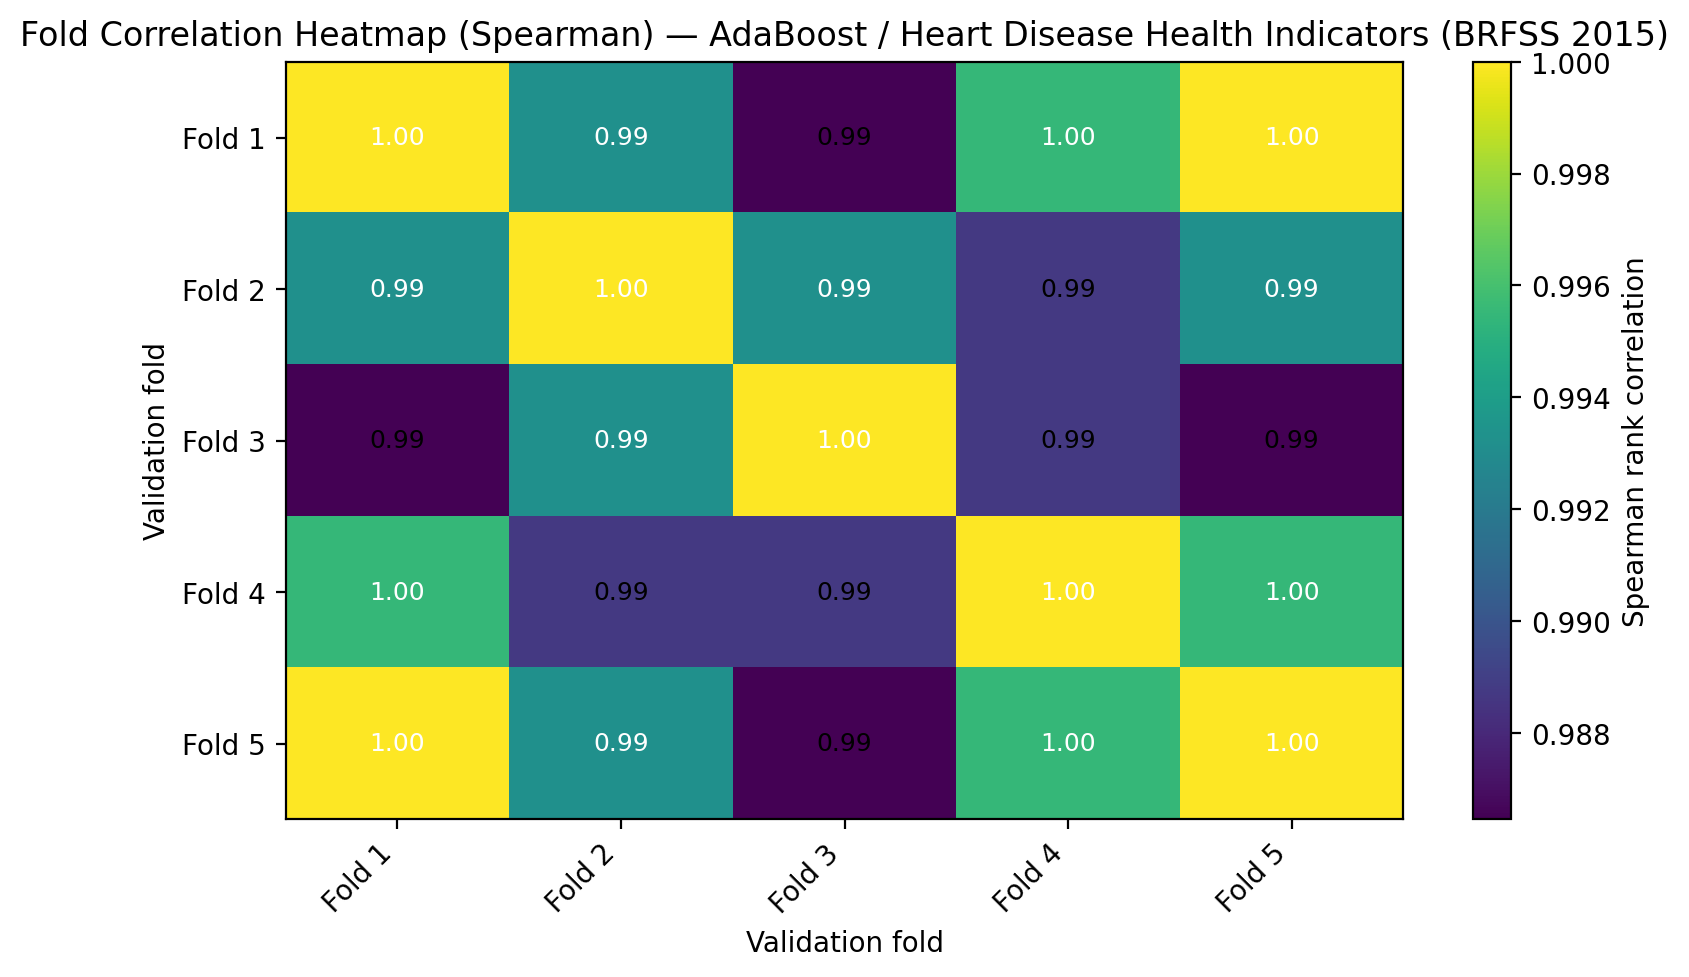

### Dataset3 Adaboost Ranking Heatmap

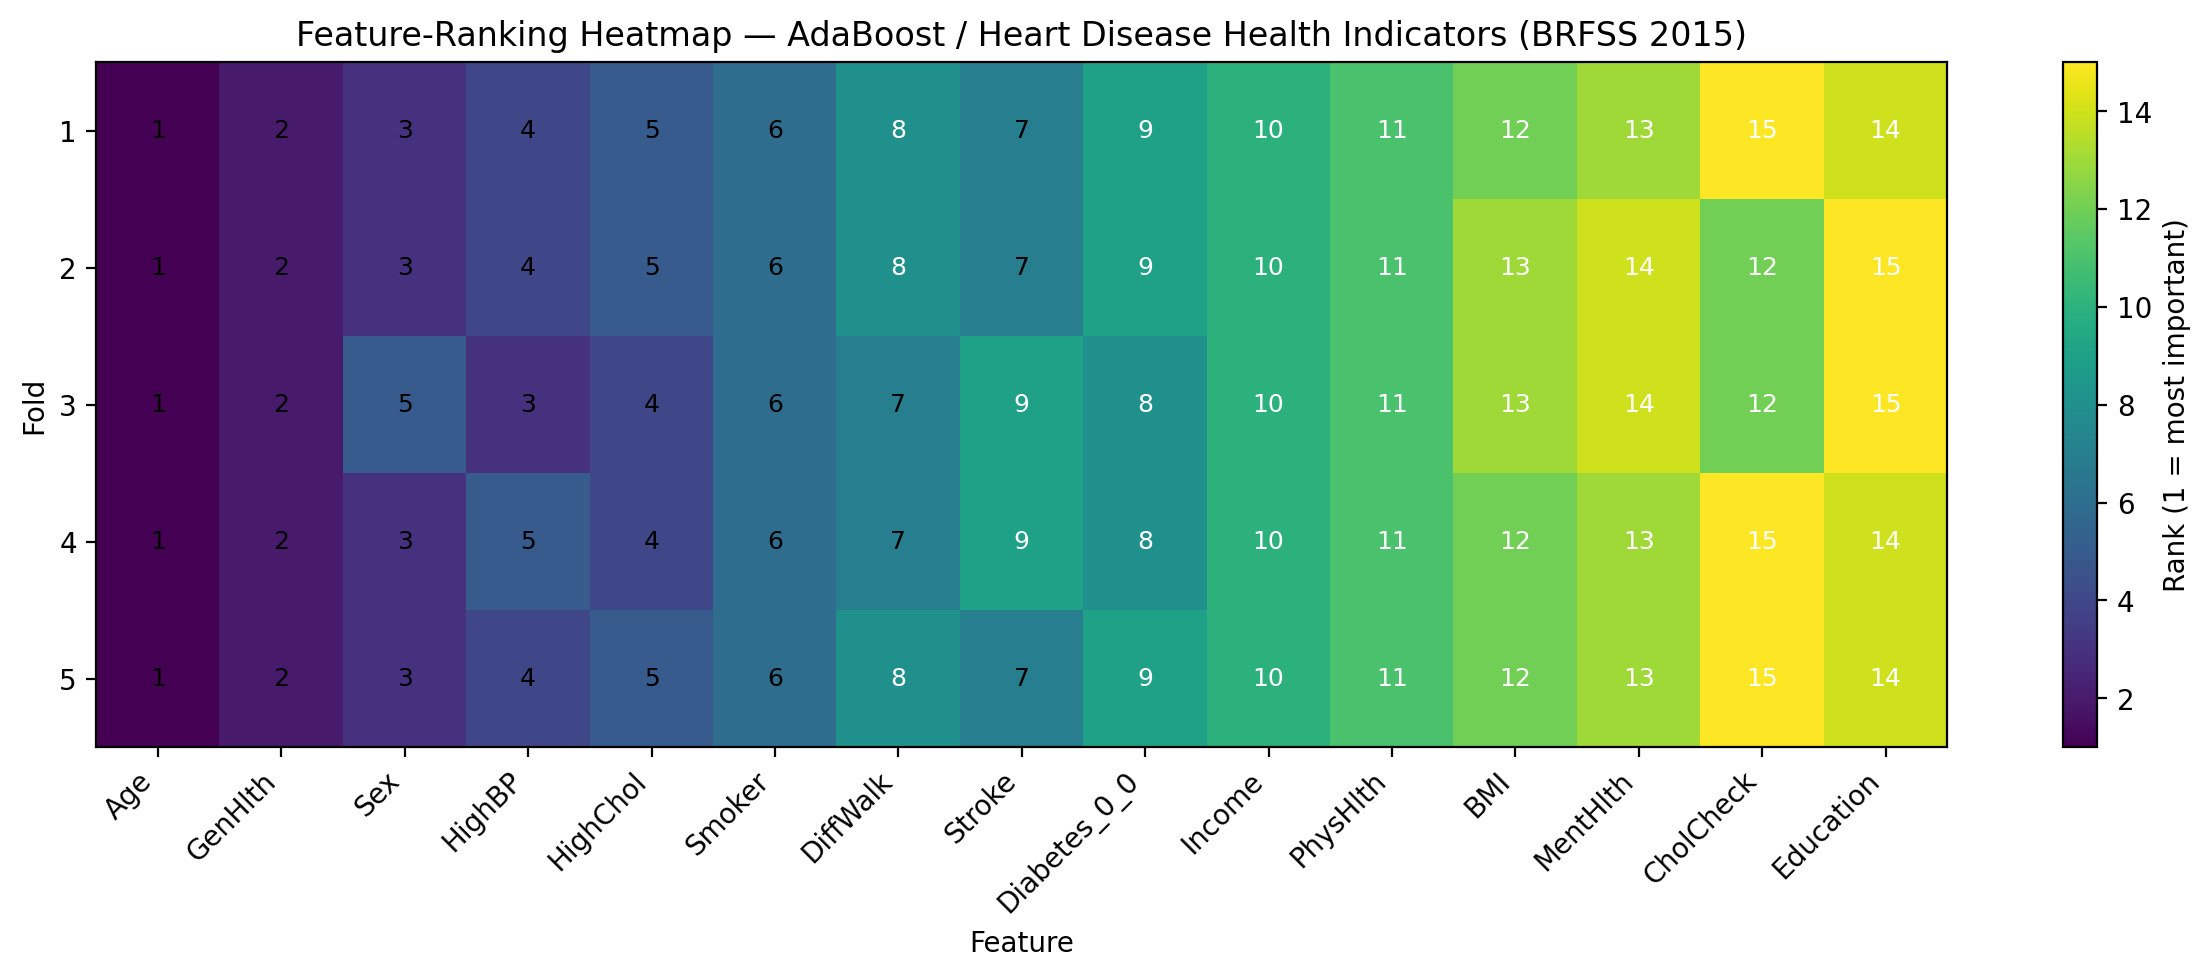

### Dataset3 Lightgbm Fold Correlation Heatmap

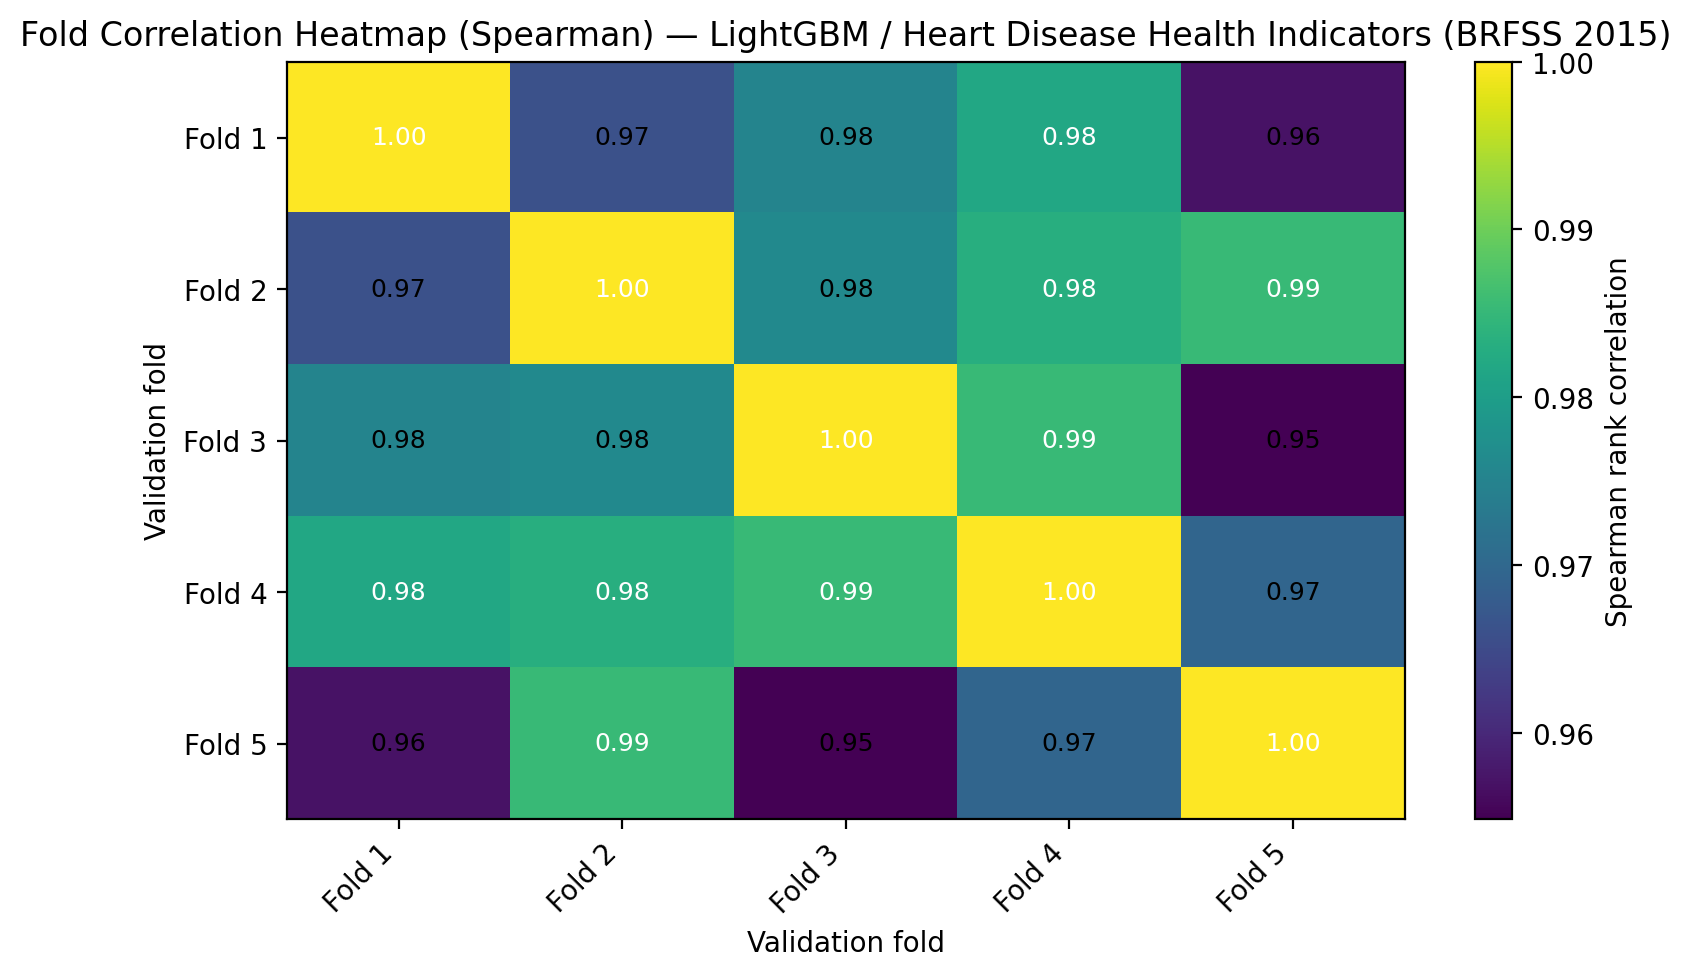

### Dataset3 Lightgbm Ranking Heatmap

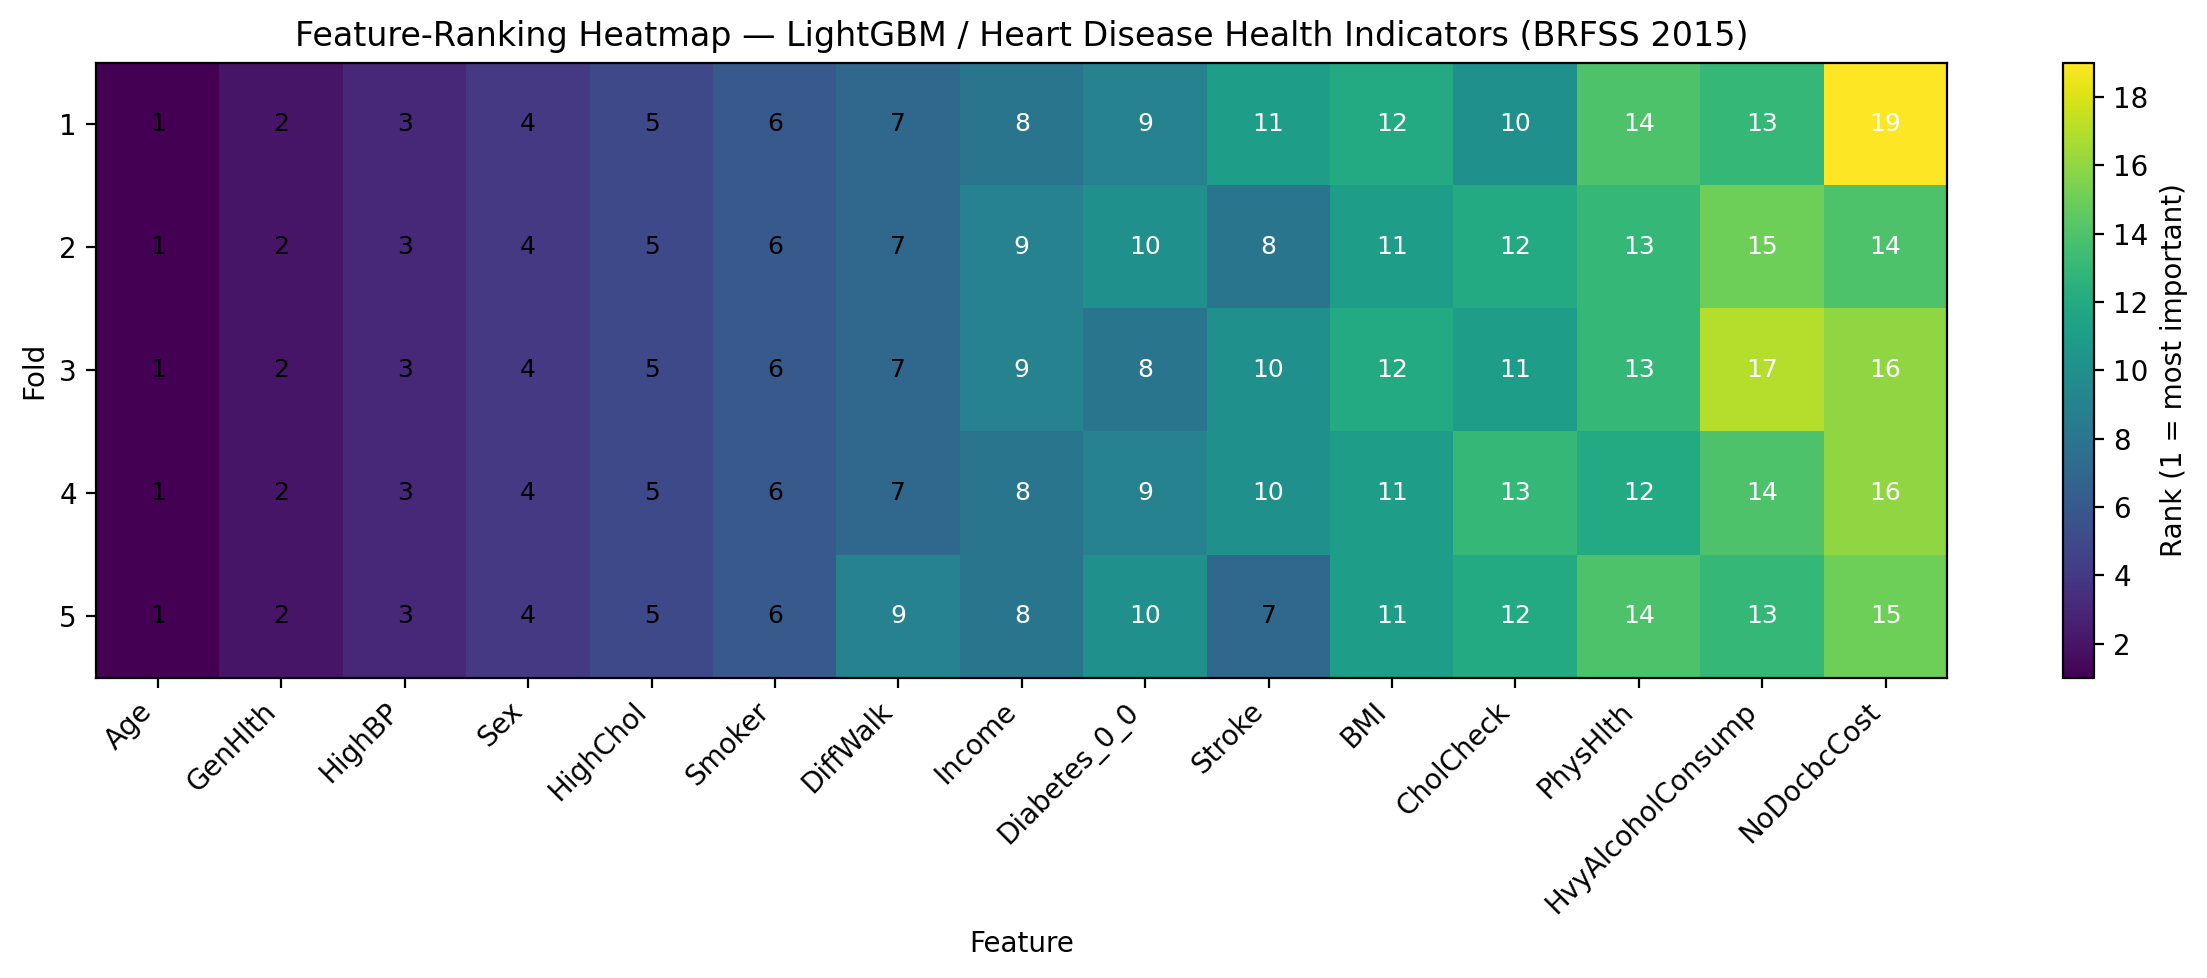

### Dataset3 Xgboost Fold Correlation Heatmap

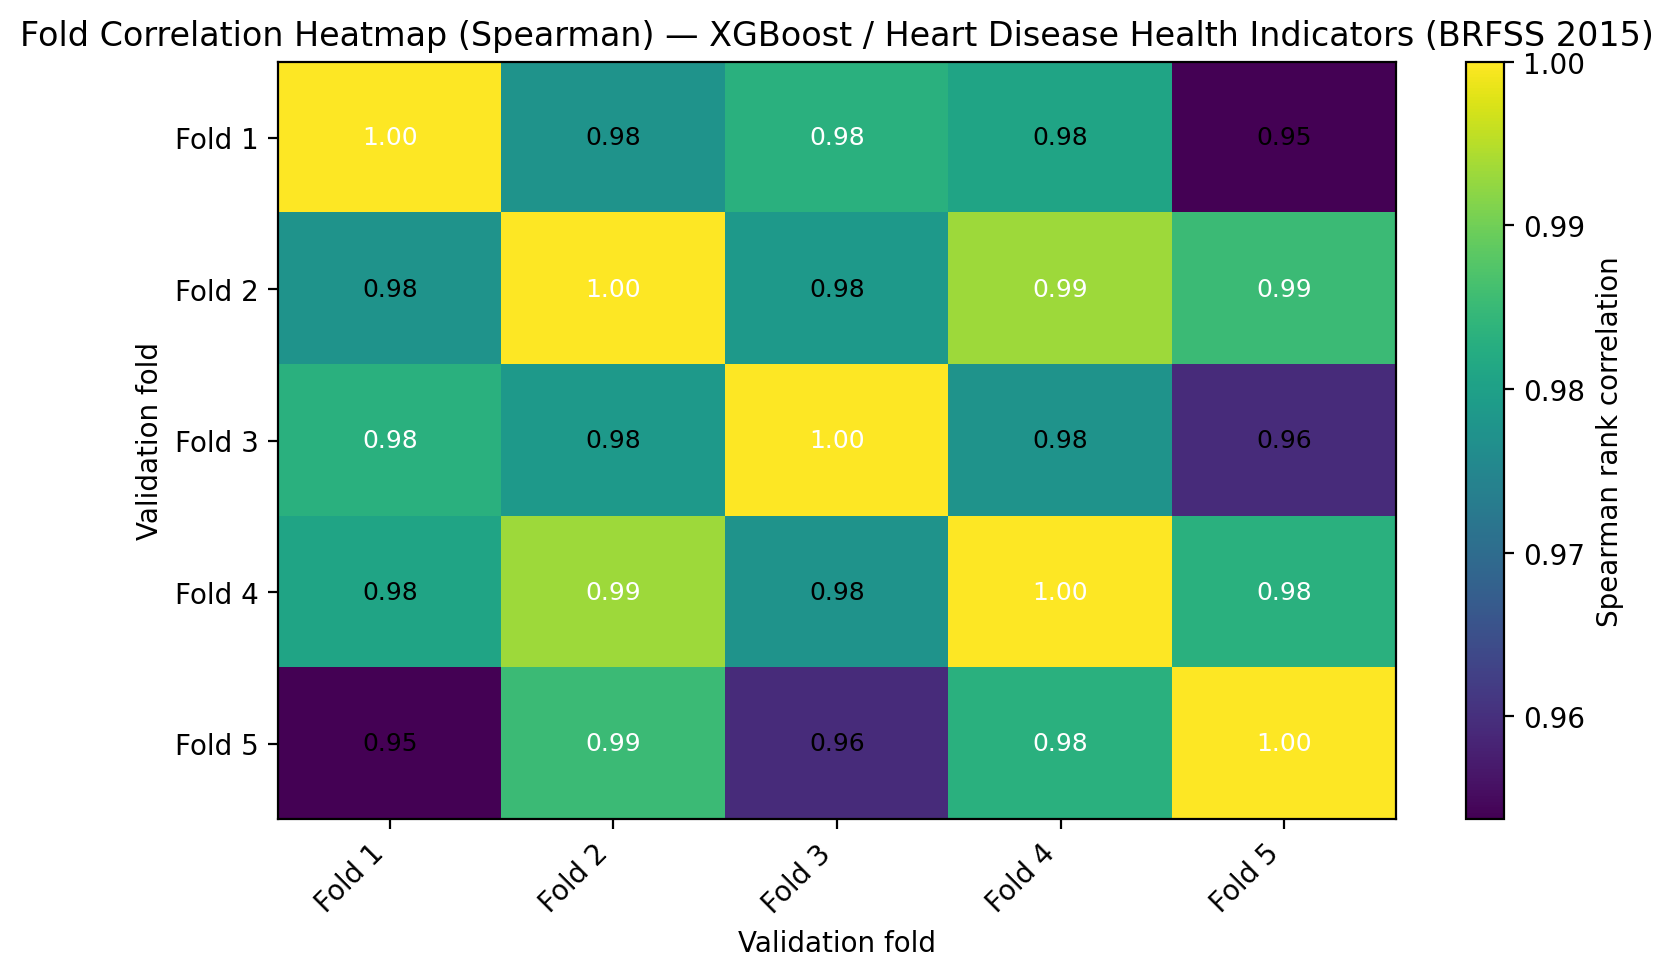

### Dataset3 Xgboost Ranking Heatmap

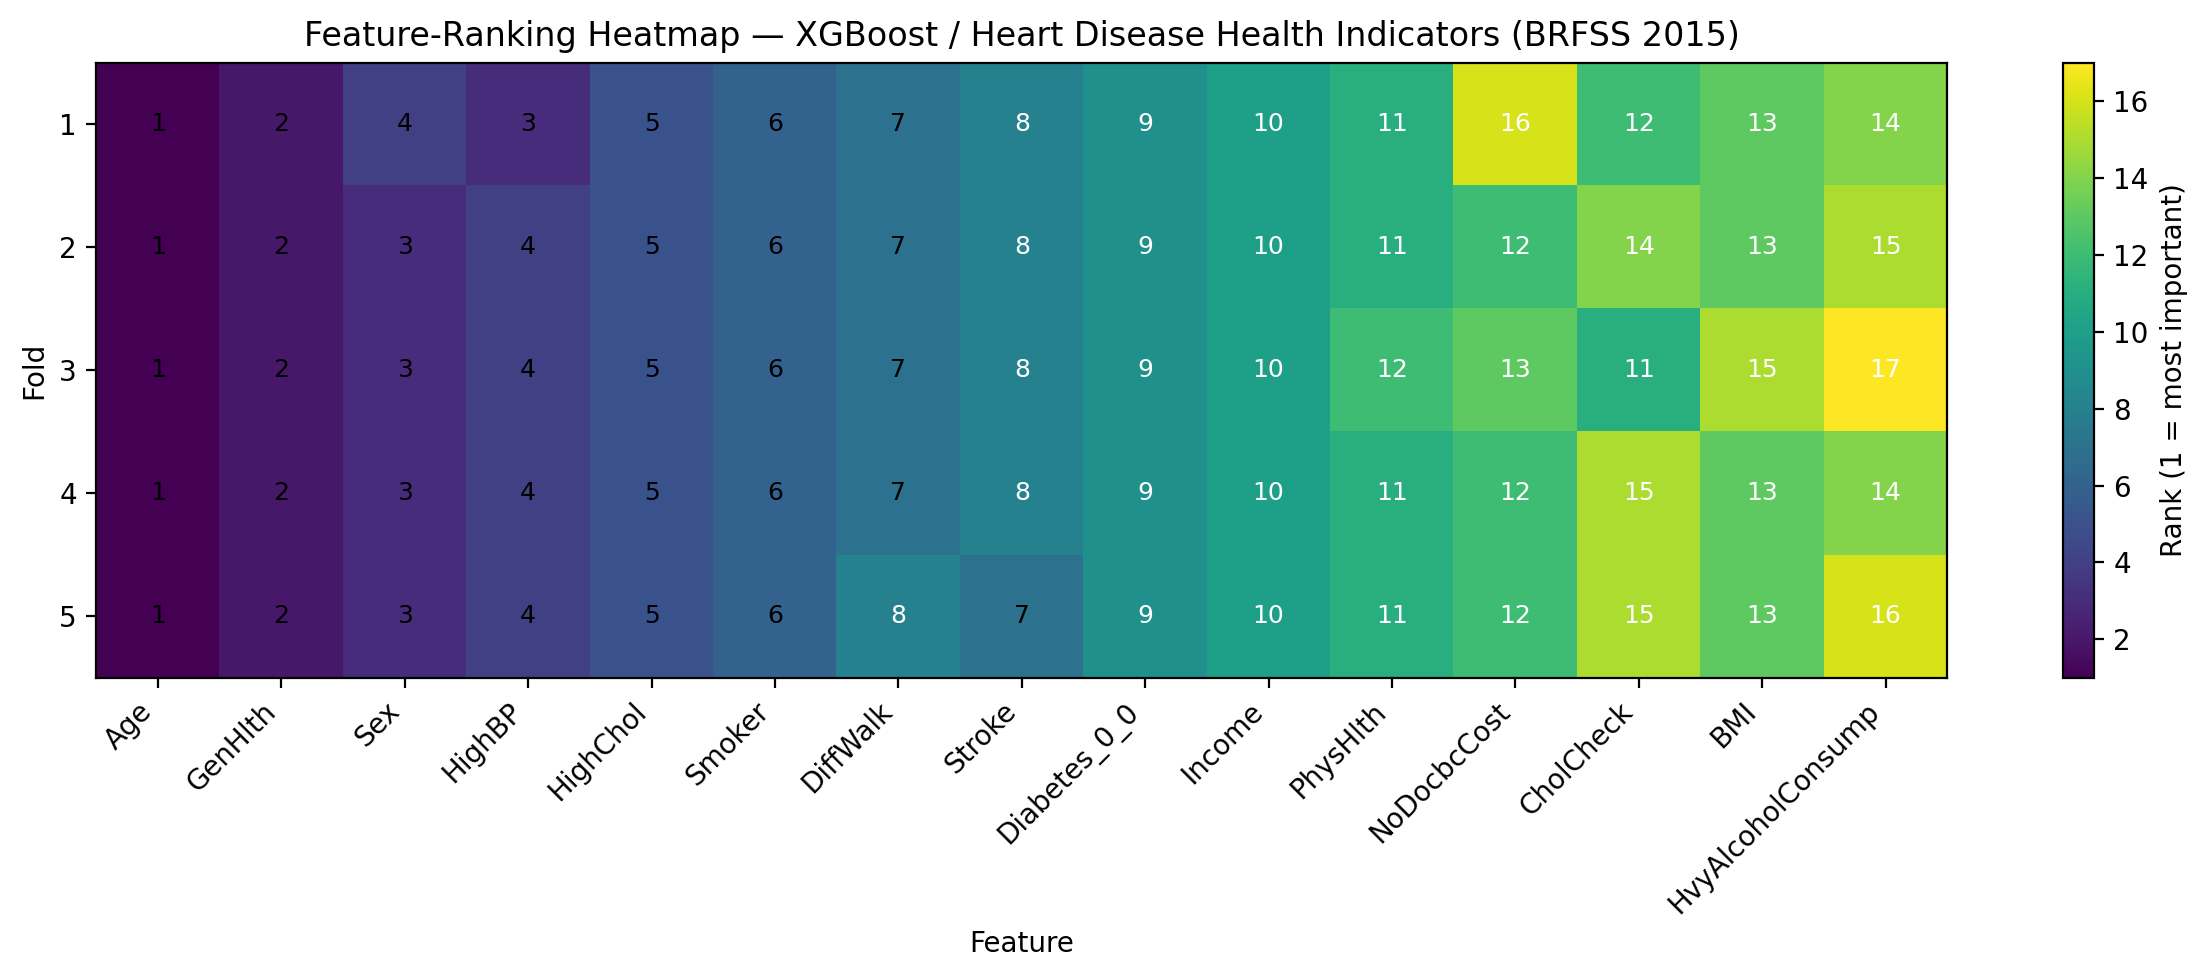

In [10]:
stability_suffixes = ["ranking_heatmap", "fold_correlation_heatmap"]
stability_plots = [
    path for path in sorted(PLOT_DIR.glob("*.png"))
    if any(path.stem.endswith(suffix) for suffix in stability_suffixes)
]
print(f"Found {len(stability_plots)} stability plot files in {PLOT_DIR}")

for plot_path in stability_plots:
    display(Markdown(f"### {plot_path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(plot_path), width=950))


## 9. Automatic RQ3 summary

The code below identifies the most and least stable dataset/model combinations based on the observed mean Spearman correlation. Interpret these numerical values together with the heatmaps and the top-$k$ overlap: high full-ranking correlation can coexist with some movement among the most important features, and vice versa.


In [11]:
best = stability_summary.sort_values("spearman_mean", ascending=False).iloc[0]
worst = stability_summary.sort_values("spearman_mean", ascending=True).iloc[0]

summary_text = f"""
### RQ3 Analysis

- The highest mean fold-to-fold SHAP ranking stability is observed for **{best['model_name']}** on **{best['dataset_name']}**, with mean Kendall $\tau$ = **{best['kendall_tau_mean']:.4f}**, mean Spearman $\rho$ = **{best['spearman_mean']:.4f}**, and mean top-{int(best['top_k'])} Jaccard = **{best['top_k_jaccard_mean']:.4f}**.
- The lowest mean ranking stability is observed for **{worst['model_name']}** on **{worst['dataset_name']}**, with mean Kendall $\tau$ = **{worst['kendall_tau_mean']:.4f}**, mean Spearman $\rho$ = **{worst['spearman_mean']:.4f}**, and mean top-{int(worst['top_k'])} Jaccard = **{worst['top_k_jaccard_mean']:.4f}**.
- A higher value indicates that explanations are less sensitive to the particular CV training partition. These statistics describe **within-model stability across folds**; raw SHAP magnitudes are not compared across different explainer algorithms.
"""
display(Markdown(summary_text))



### RQ3 Analysis

- The highest mean fold-to-fold SHAP ranking stability is observed for **AdaBoost** on **Heart Disease Health Indicators (BRFSS 2015)**, with mean Kendall $	au$ = **0.9636**, mean Spearman $ho$ = **0.9921**, and mean top-10 Jaccard = **1.0000**.
- The lowest mean ranking stability is observed for **XGBoost** on **Heart Failure Prediction**, with mean Kendall $	au$ = **0.8039**, mean Spearman $ho$ = **0.9321**, and mean top-10 Jaccard = **0.8545**.
- A higher value indicates that explanations are less sensitive to the particular CV training partition. These statistics describe **within-model stability across folds**; raw SHAP magnitudes are not compared across different explainer algorithms.


## 10. Interpretation checklist for the report

When the full run is complete, use the saved outputs to discuss:

1. Which model has the most stable SHAP ranking on each dataset?
2. Do the same features repeatedly appear in the top-$k$ across folds?
3. Which folds or features appear to drive instability in the ranking heatmaps?
4. Does strong predictive stability (RQ2) coincide with strong explanation stability (RQ3), or do the two forms of stability differ?
5. Do the fold-correlation heatmaps support the ranking-based summary statistics?

The report methodology is stored in `docs/report/sections/model_shap_methodology.tex`. RQ3 numerical results should only be added to Results & Discussion after this notebook has been run and the generated CSVs/plots have been reviewed.
